# 08 — Experiments

Every experiment that is not the headline result (`01`) or the data preparation (`00`), in one
notebook. Sections 1 to 5 follow chapters 7 and 8 of the thesis section by section, so section 2.3 here
is section 7.2.3 of the experimental design and 8.2.3 of the results. Experiments the thesis does not
use are kept in the appendix at the bottom, followed by the summary of everything.

| section | experiments | origin |
|---|---|---|
| 0 Reference bank | E7 transformer bank with validation predictions | new |
| 1 Headline Transformer model | 1.1 after-season: headline against the baseline, E1 leave one year out, error and R² maps, observed against predicted; 1.2 in-season: 2025 curve, E2 leave one year out, in-season maps | `01` cache, new, `06` |
| 2 Configuration of the headline model | 2.1 10d and 20d windows; 2.2 E3 ensemble size; 2.3 E4 larger and deeper, E21 one model 60 times as large; 2.4 E19 prediction target | new |
| 3 Different ML methodologies | 3.1 E7 Transformer; 3.2 E8 random forest; 3.3 E9 MLP; 3.4 E10, E11 weighted combinations and the 2025 comparison; 3.5 E22–E24 leave one year out | new |
| 4 Inclusion and exclusion of inputs | 4.1 soil; 4.2 E12a/E12b historical yield; 4.3 E13 temporal deltas; 4.4 E20b spectral indices; 4.5 E14 additional statistics; 4.6 comparison | `02`, new |
| 5 Feature selection | 5.1 E17 satellite statistics; 5.2 E18 soil properties | new |
| A Appendix | A.1 plain transformer; A.2 separate key/value; A.3 E15 cell structure, E16 averaged cell standard deviation; A.4 E20 derived indices only; A.5 E25 validation improvements combined; A.6 transfer *(on hold, not run)* | `04`, `02`, new, `05`, `07` |
| Summary | every experiment, 2025 holdout and leave one year out; every single model of every ensemble as box plots; the figure index | |

**Not run:** E5 (data after 24 August, on hold). The ten day against twenty day comparison now runs on
the headline configuration, which was listed as E6.

**Before the first run:** `03_track_10d.ipynb` builds `features_10d_leakfree.parquet`, and
`00_preprocessing.ipynb` builds `counts_10d.parquet` and `counts_20d.parquet`. Both are read here.

**Headline width.** The headline configuration uses width `D = 256`, as in `01`. On the 2023 validation
season (E4) width 256, width 512 and two encoder layers lie within about 0.01 t/ha of each other; width
256 with one layer is the smallest of them. Every experiment that uses the headline
architecture (E1, E2, E4, E7, E12–E16, E19–E21, E25, the soil ladder and the key/value check) runs
at that width; the plain transformer of `03`/`04`, the random forests and the MLPs do not depend on it.

**Ensemble size and noise.** Every ensemble has 30 models, as the headline of `01`. Only the E7 bank has
60, for the ensemble-size curve (E3); everywhere else its models 0–29 are the reference ensemble.
Independent 30-model ensembles of the identical configuration differ by at most about 0.005 t/ha, and
the 5th to 95th percentile of random 30-model ensembles spans 0.005 t/ha (both measured in section 2.2).
A difference in RMSE on the 10-day complete counties is therefore called real only if it is at least
**0.01 t/ha, unrounded**, about twice that spread; smaller differences are reported as "within noise".
Differences are printed with three decimals so that values near the threshold stay visible. The rule
covers the randomness of training only, not the choice of test counties; it is not a significance test.

**Standard deviation.** The window standard deviation is the exact standard deviation of the county's
pixels, pooled from the per-cell statistics in the root `preprocessing.ipynb`. The averaged cell standard
deviation of the earlier preprocessing is kept as an ablation (E16, appendix A.3).

**Rules.** Every fitted quantity (token, coverage and target scaling, the history median fill,
hyperparameters, blend weights, checkpoint selection) comes from training rows only. Anything
selected is selected on the validation season of its split. Test seasons are only predicted. The
one deliberate exception is labelled wherever it appears: the "oracle" blends of section 3 choose
their weight on 2025, as an upper bound of what blending could ever give, not as a model.

**Test sets.** "10-day complete" is the headline cohort: 2025 counties whose ten-day season is
complete, the **10d test set** of the thesis. "All counties" is every 2025 county-year of the twenty-day
table, the **20d test set**. The same two subsets are used inside every leave-one-year-out season. Tables
keep the notebook names and the E-numbers for tracing; figures use the names of the thesis.

**Units.** Computed in dt/ha, the unit of the labels. Tables and figures report RMSE and MAE in
**t/ha**, rounded to two decimals; bar axes start at zero. Figures carry no title; captions come from LaTeX. Every figure is also saved to `figures/` as PNG, named after its notebook section (`A-` appendix, `S_` summary). Observed yield is on the x axis and
predicted yield on the y axis, as in `01`.

**Cache.** Every trained model is cached on its own (`cache/e<nn>_<name>/model_<ii>.npz`, holding
validation predictions, test predictions and the seed), so a re-run reloads instead of training.
Delete a file or folder to retrain it. Model *i* of a bank is trained with seed *i*. Folders of models
that depend on the headline width carry the width in their name. The headline bank and the in-season
models of `01` are only read; every other model is trained here.

**Runtime.** A first run from an empty cache trains about 2,700 networks (most of a day on one GPU), reads about 70 GB of per-cell exports for E15 and E16 and about 36,000 soil rasters for E18.
With the cache in place it takes minutes.

In [1]:
# Setup: paths, device and the attention backend. Mirrors 01_headline_register.ipynb.
import os
import re
import glob
import time
import itertools
import textwrap
import warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import geopandas as gpd
import netCDF4
import torch
import torch.nn as nn
from scipy import stats
from sklearn.ensemble import RandomForestRegressor

project_folder = Path.cwd()
# walk up until the yield label file is found -> that folder is the project root
while not (project_folder / "Ertragsdaten_USA.csv").exists():
    assert project_folder.parent != project_folder, "repo root not found"
    project_folder = project_folder.parent
ROOT = str(project_folder)
DATA = os.path.join(ROOT, "Claude", "data_cache")
CACHE = os.path.join(ROOT, "Claude", "final_results_claude", "cache")

torch.backends.cuda.enable_flash_sdp(False)            # Blackwell math-SDPA workaround
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)
dev = "cuda" if torch.cuda.is_available() else "cpu"

# every pre-norm encoder layer triggers a harmless PyTorch note about nested tensors
warnings.filterwarnings("ignore", message="enable_nested_tensor is True")

print("ROOT =", ROOT, "| device =", dev)

ROOT = <repository> | device = cuda


In [2]:
# Metrics and tables. Metrics are computed in dt/ha, the unit of the NASS labels; tables and
# figures convert RMSE and MAE to t/ha. R2 and nRMSE carry no unit.
DT_HA_PER_T_HA = 10.0


def rmse(prediction, target):
    return float(np.sqrt(np.mean((np.asarray(prediction) - np.asarray(target)) ** 2)))


def mae(prediction, target):
    return float(np.mean(np.abs(np.asarray(prediction) - np.asarray(target))))


def regression_metrics(prediction, target):
    """RMSE and MAE in dt/ha, R2, and normalised RMSE in percent of the mean observed yield."""
    prediction = np.asarray(prediction)
    target = np.asarray(target)
    residual_sum_of_squares = np.sum((target - prediction) ** 2)
    total_sum_of_squares = np.sum((target - target.mean()) ** 2)
    return dict(
        RMSE=rmse(prediction, target),
        MAE=mae(prediction, target),
        R2=float(1 - residual_sum_of_squares / total_sum_of_squares),
        nRMSE=float(rmse(prediction, target) / target.mean() * 100),
    )


def metrics_t_per_ha(prediction, target, label=""):
    """The four metrics as table columns, with RMSE and MAE converted to t/ha."""
    metrics = regression_metrics(prediction, target)
    if label:
        label = label + " "
    return {
        f"{label}RMSE (t/ha)": round(metrics["RMSE"] / DT_HA_PER_T_HA, 2),
        f"{label}MAE (t/ha)": round(metrics["MAE"] / DT_HA_PER_T_HA, 2),
        f"{label}R2": round(metrics["R2"], 2),
        f"{label}nRMSE (%)": round(metrics["nRMSE"], 1),
    }


def cohort_metrics(test_prediction):
    """RMSE and MAE (t/ha) and R2 of one 2025 prediction, as {"headline": {...}, "full": {...}}.
    A cohort for which the prediction has missing values is None."""
    result = {}
    for cohort_name, row_mask in [("headline", is_headline_cohort), ("full", np.ones(len(yield_actual_test), bool))]:
        prediction = np.asarray(test_prediction)[row_mask]
        if np.isnan(prediction).any():
            result[cohort_name] = None
        else:
            metrics = regression_metrics(prediction, yield_actual_test[row_mask])
            result[cohort_name] = {"RMSE": metrics["RMSE"] / DT_HA_PER_T_HA,
                                   "MAE": metrics["MAE"] / DT_HA_PER_T_HA,
                                   "R2": metrics["R2"]}
    return result


def test_table_columns(test_prediction):
    """Table columns of one 2025 prediction on both test sets. A prediction that exists for the
    10-day complete counties only carries NaN elsewhere."""
    columns = {}
    for cohort_label, row_mask in [(HEADLINE_LABEL, is_headline_cohort), (FULL_LABEL, np.ones(len(yield_actual_test), bool))]:
        values = np.asarray(test_prediction)[row_mask]
        if np.isnan(values).any():
            for column in ["RMSE (t/ha)", "MAE (t/ha)", "R2", "nRMSE (%)"]:
                columns[f"{cohort_label} {column}"] = np.nan
        else:
            columns.update(metrics_t_per_ha(values, yield_actual_test[row_mask], label=cohort_label))
    return columns


def rmse_t_per_ha_on_cohorts(test_prediction):
    """(10-day complete RMSE, all counties RMSE) of one 2025 prediction, in t/ha."""
    ten_day_complete_rmse = rmse(test_prediction[is_headline_cohort], yield_actual_test[is_headline_cohort])
    full_rmse = rmse(test_prediction, yield_actual_test)
    return ten_day_complete_rmse / DT_HA_PER_T_HA, full_rmse / DT_HA_PER_T_HA


def headline_rmse(test_prediction):
    """RMSE (dt/ha) of one 2025 prediction on the 10-day complete counties."""
    return rmse(np.asarray(test_prediction)[is_headline_cohort], yield_actual_test[is_headline_cohort])


def validation_rmse_t_per_ha(validation_prediction):
    """RMSE on the 2023 validation season in t/ha, two decimals."""
    return round(rmse(validation_prediction, yield_actual_validation) / DT_HA_PER_T_HA, 2)


# Independent 30-model ensembles of one configuration differ by at most about 0.005 t/ha (section 2.2).
# A difference in RMSE is only called real when it reaches about twice that, 0.01 t/ha, unrounded.
NOISE_FLOOR_T_PER_HA = 0.01


def noise_verdict(variant_rmse, reference_rmse):
    """Compare two RMSE values (dt/ha) with the noise rule on the unrounded difference; the verdict carries
    the difference in t/ha with three decimals."""
    difference = (variant_rmse - reference_rmse) / DT_HA_PER_T_HA
    shown = round(difference, 3) + 0.0      # + 0.0 avoids printing -0.000
    if difference <= -NOISE_FLOOR_T_PER_HA:
        return f"lower RMSE ({shown:+.3f})"
    elif difference >= NOISE_FLOOR_T_PER_HA:
        return f"higher RMSE ({shown:+.3f})"
    else:
        return f"within noise ({shown:+.3f})"


# Every experiment registers its result here; the summary turns it into one table.
experiment_summary = {}
SUMMARY_SUBSETS = ["10-day complete", "all counties"]


def summary_metric_columns(prediction, actual):
    """RMSE, MAE (t/ha) and R2 as summary columns; NaN when the prediction has missing values."""
    if np.isnan(prediction).any():
        return {"RMSE (t/ha)": np.nan, "MAE (t/ha)": np.nan, "R2": np.nan}
    metrics = regression_metrics(prediction, actual)
    return {"RMSE (t/ha)": metrics["RMSE"] / DT_HA_PER_T_HA, "MAE (t/ha)": metrics["MAE"] / DT_HA_PER_T_HA, "R2": metrics["R2"]}


def record_in_summary(section, experiment, test_prediction, models="", note=""):
    """Register a 2025 holdout result."""
    row = {"section": section, "experiment": experiment, "evaluation": "2025 holdout", "models": models}
    for subset_name, row_mask in [("10-day complete", is_headline_cohort), ("all counties", np.ones(len(yield_actual_test), bool))]:
        for column, value in summary_metric_columns(np.asarray(test_prediction)[row_mask], yield_actual_test[row_mask]).items():
            row[f"{subset_name} {column}"] = value
    row["note"] = note
    experiment_summary[experiment + " | 2025"] = row


def loyo_season_metrics(held_out_year, season_prediction):
    """RMSE, MAE (t/ha), R2 and nRMSE of one held-out season on its 10-day complete counties and on all
    counties (unrounded)."""
    is_season_row = year == held_out_year
    season_actual = yield_actual[is_season_row]
    columns = {}
    for subset_name, row_mask in [("10-day complete", is_ten_day_complete[is_season_row]),
                                  ("all counties", np.ones(len(season_actual), bool))]:
        metrics = regression_metrics(np.asarray(season_prediction)[row_mask], season_actual[row_mask])
        columns[f"{subset_name} RMSE (t/ha)"] = metrics["RMSE"] / DT_HA_PER_T_HA
        columns[f"{subset_name} MAE (t/ha)"] = metrics["MAE"] / DT_HA_PER_T_HA
        columns[f"{subset_name} R2"] = metrics["R2"]
        columns[f"{subset_name} nRMSE (%)"] = metrics["nRMSE"]
    return columns


def loyo_mean_rmse(prediction_by_year):
    """Mean over the held-out seasons of the 10-day complete RMSE (dt/ha)."""
    season_rmses = []
    for held_out_year, season_prediction in prediction_by_year.items():
        is_season_row = year == held_out_year
        season_is_ten_day_complete = is_ten_day_complete[is_season_row]
        season_rmses.append(rmse(season_prediction[season_is_ten_day_complete],
                                 yield_actual[is_season_row][season_is_ten_day_complete]))
    return float(np.mean(season_rmses))


def record_loyo_in_summary(section, experiment, prediction_by_year, models="", note=""):
    """Register a leave-one-year-out result as the mean over the held-out seasons of the per-season metrics.
    prediction_by_year maps each held-out year to the prediction of that year's rows."""
    per_season_columns = []
    for held_out_year, season_prediction in prediction_by_year.items():
        season_columns = loyo_season_metrics(held_out_year, season_prediction)
        per_season_columns.append({name: value for name, value in season_columns.items() if "nRMSE" not in name})
    row = {"section": section, "experiment": experiment,
           "evaluation": f"leave one year out, mean over {len(prediction_by_year)} seasons", "models": models}
    row.update(pd.DataFrame(per_season_columns).mean().to_dict())
    row["note"] = note
    experiment_summary[experiment + " | LOYO"] = row


# Every experiment trained as an ensemble also registers its individual models; the summary scores each
# model on its own to show the variance that comes from the randomness of training.
single_model_registry = {}


def section_sort_key(section):
    """Sort "1.1" < "2.3" < "4.6" < "A.1" < "A.5": numbered sections first, then the appendix."""
    parts = section.split(".")
    if parts[0].isdigit():
        return (0, [int(part) for part in parts])
    return (1, [parts[0]] + [int(part) for part in parts[1:]])


def record_single_models(section, experiment, test_bank=None, loyo_test_bank_by_year=None, colour=None):
    """Register the individual models of an experiment: test_bank is (models, 2025 rows), and
    loyo_test_bank_by_year maps each held-out year to (models, rows of that season). Calls with the same
    experiment name are merged, so a 2025 bank and a leave-one-year-out bank can share one row."""
    entry = single_model_registry.setdefault(experiment, {"section": section, "test": None, "loyo": None,
                                                          "colour": MODEL_COLOURS["variant"]})
    if test_bank is not None:
        entry["test"] = np.asarray(test_bank)
    if loyo_test_bank_by_year is not None:
        entry["loyo"] = loyo_test_bank_by_year
    if colour is not None:
        entry["colour"] = colour

In [3]:
# Figures. One colour per model family, identical in every figure; the all-counties test set is
# drawn in the same colour, lighter.
MODEL_COLOURS = {
    "headline transformer": "#1f7a4d",
    "plain transformer": "#2c6fbb",
    "random forest": "#b5651d",
    "MLP": "#6a4c93",
    "blend": "#c0392b",
    "oracle blend": "#e6a8a0",
    "variant": "#7f8c8d",
    "second variant": "#4f6d7a",
    "headline of 01": "#6bbf96",
    "large single model": "#34495e",
    "history only": "#aaaaaa",
}
FULL_COHORT_ALPHA = 0.45
# Text sizes. LaTeX scales every figure to (a fraction of) the text width of about 6.3 inches, which
# shrinks the fonts by the same factor, so they are set well above the 9 to 10 pt they should print at.
plt.rcParams.update({"font.size": 14, "axes.labelsize": 15, "xtick.labelsize": 14, "ytick.labelsize": 14,
                     "legend.fontsize": 13})
VALUE_FONT_SIZE = 13        # the numbers above the bars
CATEGORY_FONT_SIZE = 13     # the model names under the bars
METRIC_AXIS_LABELS = {"RMSE": "RMSE (t/ha)", "MAE": "MAE (t/ha)", "R2": "R²"}
# the names of the thesis, used in every figure
TEST_SET_10D = "10d test set"
TEST_SET_20D = "20d test set"
BASELINE_NAME = "baseline"


def experiment_folder(folder_name):
    """Create (if needed) and return the cache folder of one experiment."""
    folder = os.path.join(CACHE, folder_name)
    os.makedirs(folder, exist_ok=True)
    return folder


# Every figure is also written to one folder next to the cache, as PNG,
# named after the notebook section it belongs to, so the files sort in the order of the thesis.
FIGURES = os.path.join(os.path.dirname(CACHE), "figures")
FIGURE_SECTIONS = {
    "headline_after_season": "1-1", "e01_loyo_after_season": "1-1", "maps_after_season": "1-1",
    "parity_after_season": "1-1", "inseason_2025_curve": "1-2", "e02_loyo_in_season": "1-2",
    "maps_in_season": "1-2", "section2_ten_day_track": "2-1", "e03_ensemble_size": "2-2",
    "e04_larger_deeper": "2-3", "e19_raw_yield_target": "2-4", "e08_random_forest": "3-2",
    "section3_comparison": "3-4", "e24_loyo_methodologies": "3-5", "section4_soil_ladder": "4-1",
    "section4_input_variants": "4-6", "e17_rf_ranking_satellite": "5-1", "e18_rf_ranking_soil": "5-2",
    "section2_plain_baseline": "A-1", "section2_key_value": "A-2", "appendix_cell_statistics": "A-3",
    "appendix_derived_indices": "A-4", "e25_combined_improvements": "A-5", "e99_summary": "S",
}
figure_index = []


def save_png(figure, path, dpi):
    """Write one PNG, retrying while the file is locked (an open image viewer does that on Windows)."""
    for attempt in range(5):
        try:
            figure.savefig(path, dpi=dpi, bbox_inches="tight")
            return
        except OSError:
            if attempt == 4:
                raise
            print(f"  {os.path.basename(path)} is locked, retrying", flush=True)
            time.sleep(1.0)


def save_figure(figure, folder_name, file_name):
    """Save a thesis figure into its experiment folder and into the figures folder, then show it."""
    if figure.get_layout_engine() is None:
        figure.tight_layout()
    save_png(figure, os.path.join(experiment_folder(folder_name), file_name), dpi=200)
    section = next((label for prefix, label in FIGURE_SECTIONS.items() if folder_name.startswith(prefix)), "other")
    stem = f"{section}_{os.path.splitext(file_name)[0]}"
    os.makedirs(FIGURES, exist_ok=True)
    save_png(figure, os.path.join(FIGURES, stem + ".png"), dpi=300)
    figure_index.append({"figure": stem, "notebook section": section, "experiment folder": folder_name})
    plt.show()
    plt.close(figure)


def wrap_label(name, width=11):
    """Wrap a category label for the x axis, keeping line breaks that are already in it."""
    return "\n".join(textwrap.fill(line, width) for line in name.split("\n"))


def plot_three_metric_bars(metrics_by_name, colour_by_name, folder_name, file_name,
                           cohorts=("headline",), ranges_by_name=None, reference_name=None,
                           colour_legend=None, reference_legend_label=None):
    """Three rows (RMSE, MAE, R2) of vertical bars sharing one x axis: one group per model, one bar per
    test set inside the group, the model names written once below the last row.

    metrics_by_name  {model name: cohort_metrics(...) result}
    cohorts          "headline" (10d test set, dark bar) and/or "full" (20d test set, light bar)
    ranges_by_name   optional {model name: {cohort: {metric: (low, high)}}}, drawn as whiskers
    reference_name   optional model whose values are marked with a dashed line
    colour_legend    optional [(label, colour)] explaining what the bar colours mean
    reference_legend_label  optional text for the dashed line in the legend (default: the reference name)
    The value axis starts at zero; every bar is labelled with its value.
    """
    names = list(metrics_by_name)
    positions = np.arange(len(names))
    group_width = 0.8
    bar_width = group_width / len(cohorts)
    figure_width = max(6.5, (0.9 + 0.45 * len(cohorts)) * len(names) + 1.8)
    figure, axes = plt.subplots(3, 1, figsize=(figure_width, 8.0), sharex=True, layout="constrained")
    for axis, metric in zip(axes, ["RMSE", "MAE", "R2"]):
        drawn_values = []
        for cohort_position, cohort in enumerate(cohorts):
            for name, position in zip(names, positions):
                values = metrics_by_name[name].get(cohort)
                if values is None:
                    continue
                offset = position - group_width / 2 + bar_width * (cohort_position + 0.5)
                alpha = 1.0 if cohort == "headline" else FULL_COHORT_ALPHA
                axis.bar(offset, values[metric], bar_width, color=colour_by_name[name], alpha=alpha)
                drawn_values.append(values[metric])
                label_position = values[metric]
                if ranges_by_name is not None and name in ranges_by_name and ranges_by_name[name][cohort] is not None:
                    low, high = ranges_by_name[name][cohort][metric]
                    axis.errorbar(offset, values[metric], yerr=[[values[metric] - low], [high - values[metric]]],
                                  color="#333333", capsize=3, linewidth=1)
                    drawn_values.extend([low, high])
                    label_position = high
                axis.text(offset, label_position, f"{values[metric]:.2f}", ha="center", va="bottom", fontsize=VALUE_FONT_SIZE)
            if reference_name is not None and metrics_by_name[reference_name].get(cohort) is not None:
                axis.axhline(metrics_by_name[reference_name][cohort][metric], color="#333333",
                             alpha=1.0 if cohort == "headline" else FULL_COHORT_ALPHA, linestyle="--", linewidth=1)
        # the value axis starts at zero, so differences inside the noise floor stay visually small
        if metric == "R2":
            axis.set_ylim(min(0.0, min(drawn_values)), 1.0)
        else:
            axis.set_ylim(0.0, 1.2 * max(drawn_values))
        axis.set_ylabel(METRIC_AXIS_LABELS[metric])
        axis.grid(axis="y", alpha=0.25)
    axes[-1].set_xticks(positions)
    axes[-1].set_xticklabels([wrap_label(name) for name in names], fontsize=CATEGORY_FONT_SIZE)
    legend_handles = []
    if len(cohorts) > 1:
        legend_handles += [Patch(color="#555555", label=f"{TEST_SET_10D} ({HEADLINE_LABEL})"),
                           Patch(color="#555555", alpha=FULL_COHORT_ALPHA, label=f"{TEST_SET_20D} ({FULL_LABEL})")]
    if colour_legend is not None:
        legend_handles += [Patch(color=colour, label=label) for label, colour in colour_legend]
    if reference_name is not None:
        legend_handles.append(plt.Line2D([], [], linestyle="--", color="#333333",
                                         label=f"dashed line: {reference_legend_label or reference_name}"))
    if legend_handles:
        figure.legend(handles=legend_handles, ncol=min(3, len(legend_handles)), loc="outside lower center")
    save_figure(figure, folder_name, file_name)


def plot_bars_by_test_set(predictions_by_name, colour_by_name, folder_name, file_name, reference_name=None,
                          reference_legend_label=None):
    """Three rows (RMSE, MAE, R2) with the two test sets on the x axis and one bar per model, the models
    explained by the colour legend. For figures that show both test sets."""
    metrics_by_name = {name: cohort_metrics(prediction) for name, prediction in predictions_by_name.items()}
    names = list(metrics_by_name)
    test_sets = [("headline", f"{TEST_SET_10D} ({HEADLINE_LABEL})"), ("full", f"{TEST_SET_20D} ({FULL_LABEL})")]
    positions = np.arange(len(test_sets))
    group_width = 0.8
    bar_width = group_width / len(names)
    figure, axes = plt.subplots(3, 1, figsize=(max(7.0, 1.6 * len(names) + 3.5), 8.0), sharex=True, layout="constrained")
    for axis, metric in zip(axes, ["RMSE", "MAE", "R2"]):
        drawn_values = []
        for name_position, name in enumerate(names):
            for position, (cohort, _) in enumerate(test_sets):
                values = metrics_by_name[name].get(cohort)
                if values is None:
                    continue
                offset = position - group_width / 2 + bar_width * (name_position + 0.5)
                axis.bar(offset, values[metric], bar_width, color=colour_by_name[name])
                axis.text(offset, values[metric], f"{values[metric]:.2f}", ha="center", va="bottom", fontsize=VALUE_FONT_SIZE)
                drawn_values.append(values[metric])
            if reference_name is not None and name == reference_name:
                for position, (cohort, _) in enumerate(test_sets):
                    reference_values = metrics_by_name[reference_name].get(cohort)
                    if reference_values is not None:
                        axis.plot([position - group_width / 2, position + group_width / 2],
                                  [reference_values[metric]] * 2, linestyle="--", color="#333333", linewidth=1)
        if metric == "R2":
            axis.set_ylim(min(0.0, min(drawn_values)), 1.0)
        else:
            axis.set_ylim(0.0, 1.2 * max(drawn_values))
        axis.set_ylabel(METRIC_AXIS_LABELS[metric])
        axis.grid(axis="y", alpha=0.25)
    axes[-1].set_xticks(positions)
    axes[-1].set_xticklabels([label for _, label in test_sets])
    legend_handles = [Patch(color=colour_by_name[name], label=name) for name in names]
    if reference_name is not None:
        legend_handles.append(plt.Line2D([], [], linestyle="--", color="#333333",
                                         label=f"dashed line: {reference_legend_label or reference_name}"))
    figure.legend(handles=legend_handles, ncol=min(3, len(legend_handles)), loc="outside lower center")
    save_figure(figure, folder_name, file_name)


def plot_prediction_bars(predictions_by_name, colour_by_name, folder_name, file_name, cohorts=("headline",),
                         reference_name=None, extra_metrics=None, extra_ranges=None, colour_legend=None,
                         reference_legend_label=None):
    """Three-metric bars of 2025 predictions. extra_metrics / extra_ranges add entries that are not a
    single prediction (the single-model summaries of E21, drawn with their range as a whisker)."""
    metrics_by_name = {name: cohort_metrics(prediction) for name, prediction in predictions_by_name.items()}
    if extra_metrics is not None:
        metrics_by_name.update(extra_metrics)
    plot_three_metric_bars(metrics_by_name, colour_by_name, folder_name, file_name, cohorts=cohorts,
                           ranges_by_name=extra_ranges, reference_name=reference_name, colour_legend=colour_legend,
                           reference_legend_label=reference_legend_label)


def plot_parity(actual, prediction, colour, folder_name, file_name, point_size=18):
    """Observed (x) against predicted (y) yield in t/ha, with the 1:1 line and the metrics."""
    actual_t_per_ha = np.asarray(actual) / DT_HA_PER_T_HA
    prediction_t_per_ha = np.asarray(prediction) / DT_HA_PER_T_HA
    metrics = regression_metrics(prediction_t_per_ha, actual_t_per_ha)
    lower_limit = min(actual_t_per_ha.min(), prediction_t_per_ha.min()) - 0.2
    upper_limit = max(actual_t_per_ha.max(), prediction_t_per_ha.max()) + 0.2
    figure, axis = plt.subplots(figsize=(6, 6))
    axis.scatter(actual_t_per_ha, prediction_t_per_ha, s=point_size, alpha=0.45, color=colour, edgecolor="none")
    axis.plot([lower_limit, upper_limit], [lower_limit, upper_limit], "k--", linewidth=1, label="1:1 line")
    axis.set_xlim(lower_limit, upper_limit)
    axis.set_ylim(lower_limit, upper_limit)
    axis.set_aspect("equal")
    axis.set_xlabel("Observed yield (t/ha)")
    axis.set_ylabel("Predicted yield (t/ha)")
    metrics_text = (f"RMSE {metrics['RMSE']:.2f} t/ha\nMAE  {metrics['MAE']:.2f} t/ha\n"
                    f"R²   {metrics['R2']:.2f}\nn = {len(actual_t_per_ha)}")
    axis.text(0.04, 0.96, metrics_text, transform=axis.transAxes, va="top", ha="left",
              bbox={"facecolor": "white", "edgecolor": "#999999", "alpha": 0.85})
    axis.legend(loc="lower right")
    axis.grid(alpha=0.25)
    save_figure(figure, folder_name, file_name)

## Inputs
Tables from `00_preprocessing.ipynb` (20-day features, pixel counts, soil, headline cohort) and
`03_track_10d.ipynb` (10-day features). All are read only.

In [4]:
# The input tables, one row per county-year.
N_WINDOWS = 7
WINDOW_END_DATES = ["Apr 26", "May 16", "Jun 5", "Jun 25", "Jul 15", "Aug 4", "Aug 24"]

county_year_features = pd.read_parquet(os.path.join(DATA, "features_20d_leakfree.parquet"))
county_year_features["county_id"] = county_year_features.county_id.astype(str)
n_county_years = len(county_year_features)

# per-window satellite coverage (pixels observed / wheat pixels), used as the pooling bias
pixel_counts = pd.read_parquet(os.path.join(DATA, "counts_20d.parquet"))
pixel_counts["county_id"] = pixel_counts.county_id.astype(str)
coverage_columns = ["county_id", "year", "wheat_pix"] + [f"satc_w{w:02d}" for w in range(N_WINDOWS)]
county_year_features = county_year_features.merge(pixel_counts[coverage_columns],
                                                  on=["county_id", "year"], how="left")

# County-mean soil, used only by the soil ladder (section 4.1) and the soil ranking (E18). The table holds
# the properties that are the first of their correlation group in the ranking of section 5.2, 18 of them at
# the threshold 0.85; built by build_soil_selection.py from the same wheat cells as soil_means_20d.parquet.
county_mean_soil = pd.read_parquet(os.path.join(DATA, "soil_means_20d_selected.parquet"))
county_mean_soil["county_id"] = county_mean_soil.county_id.astype(str)
soil_property_columns = [c for c in county_mean_soil.columns if c.startswith("soil_")]
county_year_features = county_year_features.merge(county_mean_soil, on=["county_id", "year"], how="left")
assert len(county_year_features) == n_county_years, "a merge duplicated county-years"

# the 10-day table, used by the ten day track (2.1) and to define ten day complete counties
features_10d_file = os.path.join(DATA, "features_10d_leakfree.parquet")
assert os.path.exists(features_10d_file), "run 03_track_10d.ipynb first (it builds the 10-day table)"
features_10d = pd.read_parquet(features_10d_file)
features_10d["county_id"] = features_10d.county_id.astype(str)
pixel_counts_10d = pd.read_parquet(os.path.join(DATA, "counts_10d.parquet"))
pixel_counts_10d["county_id"] = pixel_counts_10d.county_id.astype(str)
coverage_columns_10d = ["county_id", "year", "wheat_pix"] + [f"satc_w{w:02d}" for w in range(2 * N_WINDOWS)]
features_10d = features_10d.merge(pixel_counts_10d[coverage_columns_10d], on=["county_id", "year"], how="left")

headline_cohort_ids = set(open(os.path.join(CACHE, "cohort_10d_2025.txt")).read().split())

yield_actual = county_year_features["yield"].to_numpy(np.float32)
yield_history_raw = county_year_features["yield_5yr_avg"].to_numpy(np.float32)   # NaN without prior years
year = county_year_features.year.to_numpy()
county_id = county_year_features.county_id.to_numpy()

is_test_row_2025 = year == 2025
yield_actual_test = yield_actual[is_test_row_2025]
county_id_test = county_id[is_test_row_2025]
is_headline_cohort = np.array([c in headline_cohort_ids for c in county_id_test])
HEADLINE_LABEL = f"{is_headline_cohort.sum()} counties"
FULL_LABEL = f"{len(yield_actual_test)} counties"

# county-years whose ten day season is complete; in 2025 these must be exactly the headline cohort
ten_day_complete_county_years = set(zip(features_10d.county_id, features_10d.year))
is_ten_day_complete = np.array([(c, y) in ten_day_complete_county_years for c, y in zip(county_id, year)])
ten_day_complete_2025 = set(county_id[is_test_row_2025 & is_ten_day_complete])
assert ten_day_complete_2025 == headline_cohort_ids, "10-day complete 2025 counties differ from cohort_10d_2025.txt"

print(f"20-day table: {n_county_years} county-years | 10-day table: {len(features_10d)} county-years")
print(f"2025 test cohorts: headline {HEADLINE_LABEL} (10-day complete), full {FULL_LABEL}")
print("10-day complete county-years per year:")
print(pd.Series(year[is_ten_day_complete]).value_counts().sort_index().to_string())

20-day table: 4120 county-years | 10-day table: 2331 county-years
2025 test cohorts: headline 282 counties (10-day complete), full 426 counties
10-day complete county-years per year:
2016    252
2017    342
2018    317
2019    406
2020    149
2021     76
2022    221
2023    286
2025    282


In [5]:
# Lean per-window tokens, identical construction to 01_headline_register.ipynb:
# 8 bands x (mean, stdDev) + 6 spectral indices from the window band means + 5 temporal deltas.
BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "NDVI", "GCVI"]
DELTA_BANDS = ["NDVI", "GCVI", "B5", "B4", "B6"]

# positions of the three feature groups inside the 27 lean values of one window
BAND_STATISTIC_POSITIONS = list(range(0, 16))
SPECTRAL_INDEX_POSITIONS = list(range(16, 22))
DELTA_POSITIONS = list(range(22, 27))
# the six reflectance bands only, without NDVI and GCVI: their statistics and their three deltas
REFLECTANCE_STATISTIC_POSITIONS = list(range(0, 12))
REFLECTANCE_DELTA_POSITIONS = [22 + DELTA_BANDS.index(band) for band in ["B5", "B4", "B6"]]


def safe_division(numerator, denominator):
    """Divide element-wise and return NaN where the denominator is nearly zero."""
    denominator_is_valid = np.abs(denominator) > 1e-9
    division_result = np.full(shape=numerator.shape, fill_value=np.nan, dtype=np.float32)
    division_result[denominator_is_valid] = (numerator[denominator_is_valid]
                                             / denominator[denominator_is_valid])
    return division_result


def build_lean_tokens(data, n_windows=N_WINDOWS):
    """Return the (county-years, windows, 27) token array the transformer consumes."""
    n_rows = len(data)

    def get_window_column(window_number, feature_name):
        column_name = f"w{window_number:02d}_{feature_name}"
        if column_name in data.columns:
            return data[column_name].to_numpy(dtype=np.float32)
        return np.full(shape=n_rows, fill_value=np.nan, dtype=np.float32)

    tokens_per_window = []
    for window in range(n_windows):
        window_features = []
        for band in BANDS:
            window_features.append(get_window_column(window, f"{band}_mean"))
            window_features.append(get_window_column(window, f"{band}_stdDev"))

        # vegetation indices derived from the county-mean reflectances of this window
        blue, green, red, nir, swir1, swir2 = (
            get_window_column(window, f"{band}_mean")
            for band in ["B2", "B3", "B4", "B5", "B6", "B7"])
        window_features.append(safe_division(nir - red, nir + red))        # NDVI from means
        window_features.append(safe_division(swir2 - red, swir2 + red))    # VI1 (no standard name)
        window_features.append(safe_division(nir - swir1, nir + swir1))    # NDMI
        window_features.append(safe_division(nir - swir2, nir + swir2))    # NBR
        window_features.append(safe_division(nir, green))                  # NIR/Green (= GCVI + 1)
        evi_denominator = nir + 6 * red - 7.5 * blue + 1
        window_features.append(np.where(np.abs(evi_denominator) > 1e-6,
                                        2.5 * (nir - red) / evi_denominator,
                                        np.nan).astype(np.float32))        # EVI

        # change since the previous window; zero for the first window, which has no predecessor
        for band in DELTA_BANDS:
            if window == 0:
                window_features.append(np.zeros(n_rows, np.float32))
            else:
                change_since_previous_window = (get_window_column(window, f"{band}_mean")
                                                - get_window_column(window - 1, f"{band}_mean"))
                window_features.append(change_since_previous_window.astype(np.float32))

        tokens_per_window.append(np.stack(window_features, axis=1))
    return np.stack(tokens_per_window, axis=1)


def build_statistic_tokens(data, statistic_names, n_windows=N_WINDOWS):
    """(county-years, windows, statistics) array of raw band statistics such as "B5_p50"."""
    tokens_per_window = []
    for window in range(n_windows):
        columns = [f"w{window:02d}_{name}" for name in statistic_names]
        tokens_per_window.append(data[columns].to_numpy(np.float32))
    return np.stack(tokens_per_window, axis=1)


lean_tokens_raw = build_lean_tokens(county_year_features)

# the 104 statistics of one window, and the 88 of them the lean set does not use
ALL_STATISTIC_NAMES = [c[len("w00_"):] for c in county_year_features.columns if c.startswith("w00_")]
LEAN_STATISTIC_NAMES = [f"{band}_{kind}" for band in BANDS for kind in ["mean", "stdDev"]]
DROPPED_STATISTIC_NAMES = [name for name in ALL_STATISTIC_NAMES if name not in LEAN_STATISTIC_NAMES]
assert len(ALL_STATISTIC_NAMES) == len(BANDS) * 13, "expected 13 statistics per band"

# raw coverage ratio per window, clipped at 1.5; missing counts stay NaN until a split fills them
wheat_pixels_total = np.maximum(county_year_features.wheat_pix.to_numpy(np.float32), 1.0)
coverage_ratio_raw = np.stack(
    [np.clip(county_year_features[f"satc_w{w:02d}"].to_numpy(np.float32) / wheat_pixels_total, 0, 1.5)
     for w in range(N_WINDOWS)], axis=1)

# the same ratio for the 10-day windows, used by the ten day track (2.1)
wheat_pixels_total_10d = np.maximum(features_10d.wheat_pix.to_numpy(np.float32), 1.0)
coverage_ratio_10d_raw = np.stack(
    [np.clip(features_10d[f"satc_w{w:02d}"].to_numpy(np.float32) / wheat_pixels_total_10d, 0, 1.5)
     for w in range(2 * N_WINDOWS)], axis=1)

print(f"lean tokens {lean_tokens_raw.shape} | statistics per window: all {len(ALL_STATISTIC_NAMES)},"
      f" lean {len(LEAN_STATISTIC_NAMES)}, dropped {len(DROPPED_STATISTIC_NAMES)}")
print(f"county-years without coverage counts: 20-day {int(np.isnan(coverage_ratio_raw).any(axis=1).sum())}"
      f" | 10-day {int(np.isnan(coverage_ratio_10d_raw).any(axis=1).sum())}")

lean tokens (4120, 7, 27) | statistics per window: all 104, lean 16, dropped 88
county-years without coverage counts: 20-day 0 | 10-day 0


In [6]:
# Splits and scaling. Every scaler is fitted on the training rows of the split it serves, so the
# leave-one-year-out folds refit everything per fold.
def make_split(row_years, actual_yield, history_raw, held_out_year, validation_year):
    """Masks and the history for one split: test = held-out year, validation = validation year,
    training = every other year. Missing history is filled with the training-row median."""
    is_test_row = row_years == held_out_year
    is_val_row = row_years == validation_year
    is_train_row = ~is_test_row & ~is_val_row
    history_median_train = np.nanmedian(history_raw[is_train_row])
    yield_history = np.where(np.isnan(history_raw), history_median_train, history_raw).astype(np.float32)
    return dict(is_train_row=is_train_row, is_val_row=is_val_row, is_test_row=is_test_row,
                yield_actual=actual_yield, yield_history=yield_history)


def standardize_tokens(raw_tokens, is_train_row):
    """z-score every token feature with one mean and std pooled over training rows and windows.
    Missing values become 0, the training mean."""
    token_mean_train = np.nanmean(raw_tokens[is_train_row], axis=(0, 1))
    token_std_train = np.nanstd(raw_tokens[is_train_row], axis=(0, 1)) + 1e-6
    return np.nan_to_num((raw_tokens - token_mean_train) / token_std_train)


def standardize_columns(values, is_train_row):
    """Per column: fill missing values with the training median, then z-score with training statistics.
    Used for the coverage (one column per window) and the soil properties."""
    standardized_columns = []
    for column in range(values.shape[1]):
        column_values = values[:, column]
        column_values = np.where(np.isnan(column_values), np.nanmedian(column_values[is_train_row]), column_values)
        column_values = (column_values - column_values[is_train_row].mean()) / (column_values[is_train_row].std() + 1e-6)
        standardized_columns.append(column_values.astype(np.float32))
    return np.stack(standardized_columns, axis=1)


# the headline split: train = every year except 2023 and 2025, validation = 2023, test = 2025
headline_split = make_split(year, yield_actual, yield_history_raw, held_out_year=2025, validation_year=2023)
lean_tokens_headline = standardize_tokens(lean_tokens_raw, headline_split["is_train_row"])
coverage_headline = standardize_columns(coverage_ratio_raw, headline_split["is_train_row"])
history_headline = headline_split["yield_history"][:, None]
yield_actual_validation = yield_actual[headline_split["is_val_row"]]
yield_history_test = headline_split["yield_history"][is_test_row_2025]

# soil for the soil ladder: standardized per property, plus one soil vector per county
soil_values_raw = county_year_features[soil_property_columns].to_numpy(np.float32)
soil_values_standardized = standardize_columns(soil_values_raw, headline_split["is_train_row"])
unique_counties, county_index = np.unique(county_id, return_inverse=True)
soil_by_county = np.zeros((len(unique_counties), len(soil_property_columns)), np.float32)
for position in range(len(unique_counties)):
    soil_by_county[position] = soil_values_standardized[county_index == position].mean(axis=0)

print(f"headline split: train {headline_split['is_train_row'].sum()} | validation (2023) "
      f"{headline_split['is_val_row'].sum()} | test (2025) {is_test_row_2025.sum()}")

headline split: train 3181 | validation (2023) 513 | test (2025) 426


## Models and training protocol
`YIELD_PREDICTOR` is copied verbatim from `01`, with the width `D = 256` selected on validation. Every other network is a documented variant of it,
or the model of the notebook it was carried over from.

In [7]:
# THE HEADLINE MODEL, copied verbatim from 01_headline_register.ipynb
D, K = 256, 18
WIN = N_WINDOWS

class YIELD_PREDICTOR(nn.Module):
    def __init__(self, input_size_window, k=K, d=D, nwin=WIN):
        super().__init__()
        self.proj = nn.Linear(input_size_window, d)
        self.pos = nn.Parameter(torch.zeros(nwin, d))
        self.enc = nn.TransformerEncoder(nn.TransformerEncoderLayer(d, 4, 2*d, 0.1, activation="gelu", batch_first=True, norm_first=True), 1)
        self.reg = nn.Parameter(torch.randn(k, d) * 0.02)
        self.xattn = nn.MultiheadAttention(d, 4, dropout=0.1, batch_first=True)
        self.xnorm = nn.LayerNorm(d)
        self.attn = nn.Linear(d, 1)
        self.pct_scale = nn.Parameter(torch.tensor(0.5))
        self.stat = nn.Sequential(nn.Linear(1, d), nn.GELU())
        self.head = nn.Sequential(nn.Linear(2*d, d), nn.GELU(), nn.Dropout(0.1), nn.Linear(d, 1))
    def forward(self, x, h, pc):
        z = self.enc(self.proj(x) + self.pos)
        st = self.reg.unsqueeze(0).expand(x.size(0), -1, -1)
        c, _ = self.xattn(z, st, st)
        z = self.xnorm(z + c)
        a = (self.attn(z).squeeze(-1) + self.pct_scale * pc).softmax(1).unsqueeze(-1)
        return self.head(torch.cat([(z*a).sum(1), self.stat(h)], 1))


class ConfigurableYieldPredictor(YIELD_PREDICTOR):
    """The headline architecture with a chosen width and number of encoder layers (E4).

    Feed forward width stays 2 x width, heads stay 4 and register tokens stay 18.
    """

    def __init__(self, input_size_window, width, n_encoder_layers, nwin=WIN):
        super().__init__(input_size_window, k=K, d=width, nwin=nwin)
        encoder_layer = nn.TransformerEncoderLayer(width, 4, 2 * width, 0.1, activation="gelu",
                                                   batch_first=True, norm_first=True)
        self.enc = nn.TransformerEncoder(encoder_layer, n_encoder_layers)


class NoHistoryYieldPredictor(YIELD_PREDICTOR):
    """The headline architecture without the history branch (E12a, E12b).

    The head sees only the pooled window representation, so its input shrinks from 2 x D to D.
    """

    def __init__(self, input_size_window, nwin=WIN):
        super().__init__(input_size_window, nwin=nwin)
        del self.stat
        self.head = nn.Sequential(nn.Linear(D, D), nn.GELU(), nn.Dropout(0.1), nn.Linear(D, 1))

    def forward(self, window_tokens, coverage):
        encoded = self.enc(self.proj(window_tokens) + self.pos)
        register_tokens = self.reg.unsqueeze(0).expand(window_tokens.size(0), -1, -1)
        attended, _ = self.xattn(encoded, register_tokens, register_tokens)
        encoded = self.xnorm(encoded + attended)
        pooling_weights = (self.attn(encoded).squeeze(-1) + self.pct_scale * coverage).softmax(1).unsqueeze(-1)
        return self.head((encoded * pooling_weights).sum(1))

In [8]:
# Models carried over from notebooks 02 (soil ladder, key/value check) and 03/04 (plain
# transformer), and the multilayer perceptron of E9.
N_SOIL_PROPERTIES = len(soil_property_columns)
# cache folders of models that depend on the headline width carry it in their name, so a model
# trained at another width can never be reloaded by mistake
HEADLINE_WIDTH_TAG = f"width{D}"


class SoilCrossAttentionPredictor(nn.Module):
    """Notebook 02: the cross-attention block attends to the county's soil properties."""

    def __init__(self, input_size_window, n_soil=N_SOIL_PROPERTIES, d=D, n_windows=N_WINDOWS):
        super().__init__()
        self.proj = nn.Linear(input_size_window, d)
        self.pos = nn.Parameter(torch.zeros(n_windows, d))
        self.enc = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d, 4, 2 * d, 0.1, activation="gelu",
                                       batch_first=True, norm_first=True), 1)
        self.soil_emb = nn.Parameter(torch.zeros(n_soil, d))
        self.soil_val = nn.Linear(1, d)
        self.xattn = nn.MultiheadAttention(d, 4, dropout=0.1, batch_first=True)
        self.xnorm = nn.LayerNorm(d)
        self.attn = nn.Linear(d, 1)
        self.pct_scale = nn.Parameter(torch.tensor(0.5))
        self.stat = nn.Sequential(nn.Linear(1, d), nn.GELU())
        self.head = nn.Sequential(nn.Linear(2 * d, d), nn.GELU(), nn.Dropout(0.1), nn.Linear(d, 1))

    def forward(self, window_tokens, history, coverage, soil):
        encoded = self.enc(self.proj(window_tokens) + self.pos)
        soil_tokens = self.soil_val(soil.unsqueeze(-1)) + self.soil_emb
        attended_soil, _ = self.xattn(encoded, soil_tokens, soil_tokens)
        encoded = self.xnorm(encoded + attended_soil)
        pooling_weights = (self.attn(encoded).squeeze(-1)
                           + self.pct_scale * coverage).softmax(1).unsqueeze(-1)
        pooled = (encoded * pooling_weights).sum(1)
        return self.head(torch.cat([pooled, self.stat(history)], 1))


class NoCrossAttentionPredictor(SoilCrossAttentionPredictor):
    """Notebook 02: the same network with the cross-attention block skipped."""

    def forward(self, window_tokens, history, coverage, soil):
        encoded = self.enc(self.proj(window_tokens) + self.pos)
        pooling_weights = (self.attn(encoded).squeeze(-1)
                           + self.pct_scale * coverage).softmax(1).unsqueeze(-1)
        pooled = (encoded * pooling_weights).sum(1)
        return self.head(torch.cat([pooled, self.stat(history)], 1))


class SeparateKeyValueRegisterPredictor(SoilCrossAttentionPredictor):
    """Notebook 02: learned registers with key and value as two independent parameter sets.
    The soil argument is ignored."""

    def __init__(self, input_size_window, n_soil=N_SOIL_PROPERTIES, d=D, n_windows=N_WINDOWS):
        super().__init__(input_size_window, n_soil, d, n_windows)
        self.register_keys = nn.Parameter(torch.randn(K, d) * 0.02)
        self.register_values = nn.Parameter(torch.randn(K, d) * 0.02)

    def forward(self, window_tokens, history, coverage, soil):
        encoded = self.enc(self.proj(window_tokens) + self.pos)
        batch_size = window_tokens.size(0)
        keys = self.register_keys.unsqueeze(0).expand(batch_size, -1, -1)
        values = self.register_values.unsqueeze(0).expand(batch_size, -1, -1)
        attended, _ = self.xattn(encoded, keys, values)
        encoded = self.xnorm(encoded + attended)
        pooling_weights = (self.attn(encoded).squeeze(-1)
                           + self.pct_scale * coverage).softmax(1).unsqueeze(-1)
        pooled = (encoded * pooling_weights).sum(1)
        return self.head(torch.cat([pooled, self.stat(history)], 1))


PLAIN_MODEL_DIM = 64


class PlainWindowTransformer(nn.Module):
    """Notebooks 03 and 04: encoder, attention pooling and history. No cross-attention block,
    no soil, no coverage bias."""

    def __init__(self, features_per_window, n_windows, d=PLAIN_MODEL_DIM):
        super().__init__()
        self.proj = nn.Linear(features_per_window, d)
        self.pos = nn.Parameter(torch.zeros(n_windows, d))
        self.enc = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d, 4, 2 * d, 0.1, activation="gelu",
                                       batch_first=True, norm_first=True), 1)
        self.attn = nn.Linear(d, 1)
        self.stat = nn.Sequential(nn.Linear(1, d), nn.GELU())
        self.head = nn.Sequential(nn.Linear(2 * d, d), nn.GELU(), nn.Dropout(0.1), nn.Linear(d, 1))

    def forward(self, window_tokens, history):
        encoded = self.enc(self.proj(window_tokens) + self.pos)
        pooling_weights = self.attn(encoded).softmax(1)
        pooled = (encoded * pooling_weights).sum(1)
        return self.head(torch.cat([pooled, self.stat(history)], 1))


class WindowMLP(nn.Module):
    """E9: a multilayer perceptron on the flattened window tokens, the coverage and the history.
    Same inputs as the transformer, but no notion of window order or attention."""

    def __init__(self, n_windows, features_per_window, hidden_width, n_hidden_layers):
        super().__init__()
        input_size = n_windows * features_per_window + n_windows + 1
        layers = []
        layer_input_size = input_size
        for _ in range(n_hidden_layers):
            layers.append(nn.Linear(layer_input_size, hidden_width))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(0.1))
            layer_input_size = hidden_width
        layers.append(nn.Linear(layer_input_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, window_tokens, history, coverage):
        flattened_inputs = torch.cat([window_tokens.flatten(1), coverage, history], dim=1)
        return self.network(flattened_inputs)

In [9]:
# The training protocol of 01, shared by every network in this notebook.
N_MODELS_PER_ENSEMBLE = 30         # ensemble size of every model in this notebook, as the headline of 01
EPOCHS = 300
BATCH_SIZE = 64
TOKEN_NOISE_STD = 0.03
PATIENCE = 25
MINIMUM_IMPROVEMENT = 1e-4


def train_neural_model(build_model, input_arrays, split, seed, target_kind="anomaly"):
    """Train one network with the headline protocol; return validation and test predictions (dt/ha).

    build_model   function returning a fresh, untrained network
    input_arrays  arrays with one row per county-year, passed to the network in this order; the
                  first must be the window tokens, the only input that receives training noise
    split         dict from make_split
    seed          seeds the weights, dropout, noise and batch order
    target_kind   "anomaly"                  predict yield minus history, then add the history back
                  "raw_yield"                predict the standardized yield itself
                  "raw_yield_unstandardized" predict the yield in dt/ha, without standardizing it
    The target is standardized with training statistics. Early stopping keeps the checkpoint with
    the best validation RMSE.
    """
    torch.manual_seed(seed)
    random_generator = np.random.default_rng(seed)

    is_train_row = split["is_train_row"]
    is_val_row = split["is_val_row"]
    is_test_row = split["is_test_row"]

    if target_kind == "anomaly":
        target_offset = split["yield_history"]
    elif target_kind in ("raw_yield", "raw_yield_unstandardized"):
        target_offset = np.zeros_like(split["yield_history"])
    else:
        raise ValueError(f"unknown target_kind: {target_kind}")

    train_target = split["yield_actual"][is_train_row] - target_offset[is_train_row]
    if target_kind == "raw_yield_unstandardized":
        target_mean_train, target_std_train = 0.0, 1.0
    else:
        target_mean_train = float(train_target.mean())
        target_std_train = float(train_target.std())
    standardized_train_target = torch.tensor(
        ((train_target - target_mean_train) / target_std_train)[:, None], device=dev)

    inputs_train = [torch.tensor(array[is_train_row], device=dev) for array in input_arrays]
    inputs_val = [torch.tensor(array[is_val_row], device=dev) for array in input_arrays]
    inputs_test = [torch.tensor(array[is_test_row], device=dev) for array in input_arrays]
    actual_val = split["yield_actual"][is_val_row]

    model = build_model().to(dev)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, EPOCHS)
    loss_function = nn.SmoothL1Loss()

    def predict_dt_per_ha(model_inputs, row_mask):
        """Undo the target standardization and add the offset (history, or zero) back."""
        model.eval()
        with torch.no_grad():
            standardized_prediction = model(*model_inputs).squeeze(1).cpu().numpy()
        return standardized_prediction * target_std_train + target_mean_train + target_offset[row_mask]

    best_validation_rmse = 1e9
    best_state_dict = None
    epochs_without_improvement = 0

    for epoch in range(EPOCHS):
        model.train()
        shuffled_rows = random_generator.permutation(len(standardized_train_target))
        for start in range(0, len(shuffled_rows), BATCH_SIZE):
            batch_rows = shuffled_rows[start:start + BATCH_SIZE]
            batch_inputs = [tensor[batch_rows] for tensor in inputs_train]
            # noise on the window tokens only, never on history, coverage or soil
            batch_inputs[0] = batch_inputs[0] + torch.randn_like(batch_inputs[0]) * TOKEN_NOISE_STD
            optimizer.zero_grad()
            batch_loss = loss_function(model(*batch_inputs), standardized_train_target[batch_rows])
            batch_loss.backward()
            optimizer.step()
        scheduler.step()

        validation_rmse = rmse(predict_dt_per_ha(inputs_val, is_val_row), actual_val)
        if validation_rmse < best_validation_rmse - MINIMUM_IMPROVEMENT:
            best_validation_rmse = validation_rmse
            best_state_dict = {name: value.detach().cpu().clone()
                               for name, value in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            break

    model.load_state_dict(best_state_dict)
    return dict(validation=predict_dt_per_ha(inputs_val, is_val_row),
                test=predict_dt_per_ha(inputs_test, is_test_row))


def train_headline_model(tokens, coverage, split, seed, target_kind="anomaly"):
    """One YIELD_PREDICTOR with the headline protocol; tokens may have fewer windows or features."""
    return train_neural_model(
        build_model=lambda: YIELD_PREDICTOR(tokens.shape[2], nwin=tokens.shape[1]),
        input_arrays=[tokens, split["yield_history"][:, None], coverage],
        split=split, seed=seed, target_kind=target_kind)


def load_or_train_bank(folder_name, n_models, train_one_model):
    """Validation and test predictions of n_models models, training whatever is not cached.

    Model i is trained with seed i and cached as model_ii.npz (validation, test, seed). Returns
    (validation bank, test bank), each shaped (models, rows).
    """
    folder = experiment_folder(folder_name)
    validation_predictions = []
    test_predictions = []
    start_time = time.time()
    for model_number in range(n_models):
        cache_file = os.path.join(folder, f"model_{model_number:02d}.npz")
        if os.path.exists(cache_file):
            with np.load(cache_file) as cached_predictions:
                validation_prediction = cached_predictions["validation"]
                test_prediction = cached_predictions["test"]
        else:
            predictions = train_one_model(model_number)
            validation_prediction = predictions["validation"]
            test_prediction = predictions["test"]
            # write under a temporary name first, so an interrupted run never leaves a broken file
            temporary_file = os.path.join(folder, f"model_{model_number:02d}.partial.npz")
            np.savez(temporary_file, validation=validation_prediction, test=test_prediction, seed=model_number)
            os.replace(temporary_file, cache_file)
            if (model_number + 1) % 10 == 0 or model_number + 1 == n_models:
                print(f"  {folder_name}: {model_number + 1}/{n_models} trained"
                      f" ({time.time() - start_time:.0f}s)", flush=True)
        validation_predictions.append(validation_prediction)
        test_predictions.append(test_prediction)
    return np.array(validation_predictions), np.array(test_predictions)


# the reported headline: notebook 01's bank (unseeded, test predictions only). Read, never written.
headline_bank_files = sorted(glob.glob(os.path.join(CACHE, "headline_seeds", "seed_*.npz")))
assert len(headline_bank_files) > 0, "cache/headline_seeds is empty: run 01_headline_register.ipynb first"
headline_bank = np.array([np.load(os.path.join(CACHE, "headline_seeds", f"seed_{i}.npz"))["test"]
                          for i in range(len(headline_bank_files))])
headline_ensemble = headline_bank.mean(axis=0)
print(f"headline bank: {len(headline_bank)} models | 2025 RMSE (t/ha) headline / full:",
      tuple(round(value, 2) for value in rmse_t_per_ha_on_cohorts(headline_ensemble)))

headline bank: 30 models | 2025 RMSE (t/ha) headline / full: (0.51, 0.56)


## 0. Reference bank (E7)
The headline transformer retrained with exactly the headline protocol, seeded, saving **validation and
test** predictions. The headline bank of `01` stores test predictions only, so the blends of section 3
cannot be fitted on it. E7 is trained first because sections 2 to 4 compare against it; its own result
is reported in section 3.1.

The bank has 60 models only because the ensemble-size curve (E3) needs more than 30. The reference
ensemble for every comparison is models 0–29, the same size as every other ensemble; models 30–59 also
give a second independent ensemble for measuring the noise (section 2.2).

In [10]:
# E7: the headline configuration with validation and test predictions
N_MODELS_E07 = 60                  # only for the ensemble-size curve (E3); every comparison uses models 0-29

e07_validation_bank, e07_test_bank = load_or_train_bank(
    f"e07_transformer_bank_{HEADLINE_WIDTH_TAG}", N_MODELS_E07,
    lambda seed: train_headline_model(lean_tokens_headline, coverage_headline, headline_split, seed))
# the reference ensemble for every comparison, the same size as every other ensemble
e07_validation_ensemble = e07_validation_bank[:N_MODELS_PER_ENSEMBLE].mean(axis=0)
e07_test_ensemble = e07_test_bank[:N_MODELS_PER_ENSEMBLE].mean(axis=0)
print(f"E7: {len(e07_test_bank)} models ready; reference ensemble = models 0-{N_MODELS_PER_ENSEMBLE - 1}")

E7: 60 models ready; reference ensemble = models 0-29


## 1. Headline Transformer model
### 1.1 After-season prediction

#### The headline model on 2025
The headline ensemble of `01` on both test sets, against the history-only baseline. Everything else in
this section examines the same prediction: its errors in space, its variation between seasons and how
early in the season it can be made.

,model,282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%)
0,baseline,0.77,0.62,0.70,18.0,0.76,0.61,0.68,16.9
1,Transformer,0.51,0.39,0.87,11.9,0.56,0.44,0.83,12.5


skill over the baseline: 0.26 t/ha on the 282 counties


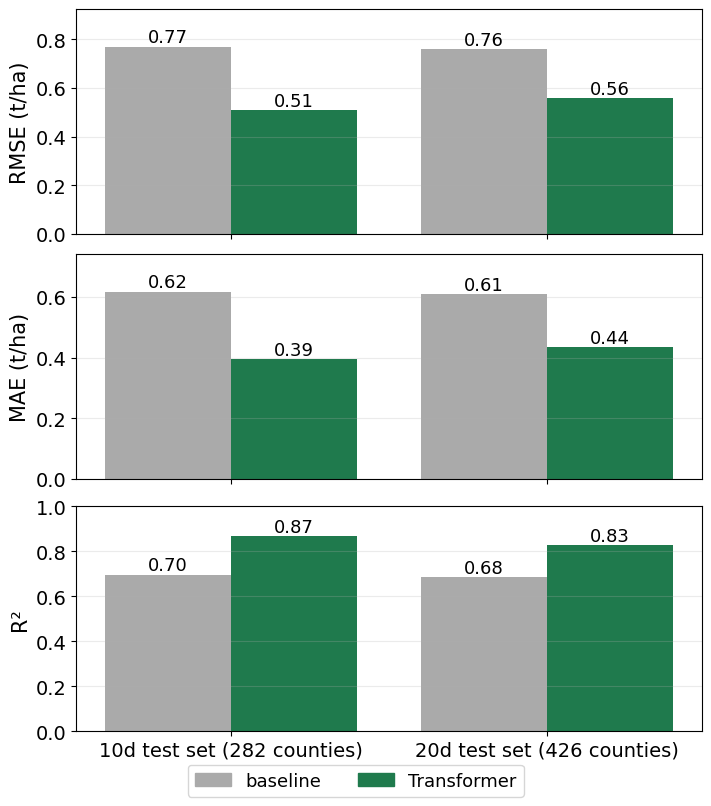

In [11]:
# The headline model of 01 against the baseline
headline_2025 = {BASELINE_NAME: (yield_history_test, MODEL_COLOURS["history only"]),
                 "Transformer": (headline_ensemble, MODEL_COLOURS["headline transformer"])}
headline_2025_table = pd.DataFrame([{"model": name, **test_table_columns(prediction)}
                                    for name, (prediction, _) in headline_2025.items()])
headline_2025_table.to_csv(os.path.join(experiment_folder("headline_after_season"), "results.csv"), index=False)
display(headline_2025_table)
print(f"skill over the baseline: "
      f"{(headline_rmse(yield_history_test) - headline_rmse(headline_ensemble)) / DT_HA_PER_T_HA:.2f} t/ha "
      f"on the {HEADLINE_LABEL}")

record_in_summary("1.1", "headline register transformer (01)", headline_ensemble, models=len(headline_bank),
                  note="the reported headline, unseeded")
record_in_summary("1.1", "history only (5-year average)", yield_history_test, models=0)
record_single_models("1.1", "headline register transformer (01)", test_bank=headline_bank,
                     colour=MODEL_COLOURS["headline transformer"])

plot_bars_by_test_set({name: prediction for name, (prediction, _) in headline_2025.items()},
                      {name: colour for name, (_, colour) in headline_2025.items()},
                      "headline_after_season", "headline_against_baseline.png")

#### E1 — Leave one year out, register model
Each of the nine seasons is held out in turn. The validation season for held-out year *t* is the
smallest later season in the list, otherwise the largest earlier one (2022 validates on 2023, 2023 on
2025, 2025 on 2023). Every other season trains. Token scaling, coverage scaling, target scaling and
the history median fill are refitted per fold. 30 models per fold.

The 2025 fold is exactly the headline split, so under the noise rule it must not differ from E7.
Results are given on the 10-day complete counties and on all counties of each held-out season, next to
the history-only baseline of that season, and aggregated two ways: the mean of the per-season values,
and pooled over all county-years.

*Caveat for the text:* the 5-year history of a training row from a later season contains the
held-out season's label. That label never enters the held-out prediction itself, but the training
set is not blind to it in the way the strict 2025 holdout is.

In [12]:
# Leave-one-year-out helpers, shared by E1, E2 and E22-E24
LOYO_YEARS = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2025]
N_MODELS_E01 = N_MODELS_PER_ENSEMBLE
E01_FOLDER = f"e01_loyo_after_season_{HEADLINE_WIDTH_TAG}"
E02_FOLDER = f"e02_loyo_in_season_{HEADLINE_WIDTH_TAG}"


def validation_year_for(held_out_year):
    """The smallest later year in LOYO_YEARS, otherwise the largest earlier one."""
    later_years = [candidate for candidate in LOYO_YEARS if candidate > held_out_year]
    if later_years:
        return min(later_years)
    else:
        return max(candidate for candidate in LOYO_YEARS if candidate < held_out_year)


def loyo_split(held_out_year):
    """The split of one leave-one-year-out fold, history median fill refitted on its training rows."""
    return make_split(year, yield_actual, yield_history_raw, held_out_year, validation_year_for(held_out_year))


def prepare_loyo_fold(held_out_year, n_windows=N_WINDOWS):
    """Split, standardized tokens and coverage of one fold, every scaler refitted on its training rows.
    n_windows < 7 gives the prefix of an in-season horizon."""
    split = loyo_split(held_out_year)
    tokens = standardize_tokens(lean_tokens_raw[:, :n_windows, :], split["is_train_row"])
    coverage = standardize_columns(coverage_ratio_raw[:, :n_windows], split["is_train_row"])
    return split, tokens, coverage


for held_out_year in LOYO_YEARS:
    print(f"held out {held_out_year} -> validation {validation_year_for(held_out_year)}")

held out 2016 -> validation 2017
held out 2017 -> validation 2018
held out 2018 -> validation 2019
held out 2019 -> validation 2020
held out 2020 -> validation 2021
held out 2021 -> validation 2022
held out 2022 -> validation 2023
held out 2023 -> validation 2025
held out 2025 -> validation 2023


In [13]:
# E1: 30 models per fold
e01_validation_by_year = {}
e01_test_by_year = {}
e01_test_bank_by_year = {}
for held_out_year in LOYO_YEARS:
    fold_split, fold_tokens, fold_coverage = prepare_loyo_fold(held_out_year)
    fold_validation_bank, fold_test_bank = load_or_train_bank(
        os.path.join(E01_FOLDER, f"fold_{held_out_year}"), N_MODELS_E01,
        lambda seed: train_headline_model(fold_tokens, fold_coverage, fold_split, seed))
    e01_validation_by_year[held_out_year] = fold_validation_bank.mean(axis=0)
    e01_test_by_year[held_out_year] = fold_test_bank.mean(axis=0)
    e01_test_bank_by_year[held_out_year] = fold_test_bank
    print(f"fold {held_out_year}: {len(fold_test_bank)} models", flush=True)

fold 2016: 30 models


fold 2017: 30 models


fold 2018: 30 models


fold 2019: 30 models


fold 2020: 30 models


fold 2021: 30 models


fold 2022: 30 models


fold 2023: 30 models


fold 2025: 30 models


,held-out season,validation season,10-day complete n,10-day complete RMSE (t/ha),10-day complete MAE (t/ha),10-day complete R2,10-day complete history-only RMSE (t/ha),10-day complete history-only MAE (t/ha),10-day complete history-only R2,all counties n,all counties RMSE (t/ha),all counties MAE (t/ha),all counties R2,all counties history-only RMSE (t/ha),all counties history-only MAE (t/ha),all counties history-only R2
0,2016,2017,252,0.62,0.50,0.77,0.95,0.81,0.45,499,0.66,0.50,0.71,0.96,0.81,0.37
1,2017,2018,342,0.50,0.38,0.80,0.68,0.52,0.62,508,0.51,0.39,0.78,0.66,0.50,0.65
2,2018,2019,317,0.47,0.37,0.82,0.55,0.43,0.76,422,0.51,0.38,0.78,0.59,0.45,0.71
3,2019,2020,406,0.60,0.47,0.53,0.78,0.60,0.21,503,0.61,0.47,0.50,0.78,0.59,0.19
4,2020,2021,149,0.52,0.41,0.74,0.72,0.53,0.52,504,0.55,0.41,0.69,0.63,0.47,0.59
5,2021,2022,76,0.65,0.51,0.75,0.94,0.69,0.46,307,0.60,0.47,0.78,0.77,0.59,0.63
6,2022,2023,221,0.55,0.45,0.84,0.74,0.61,0.71,438,0.57,0.45,0.81,0.72,0.59,0.69
7,2023,2025,286,0.62,0.48,0.81,0.84,0.68,0.64,513,0.69,0.55,0.79,0.93,0.76,0.63
8,2025,2023,282,0.51,0.40,0.87,0.77,0.62,0.70,426,0.56,0.44,0.83,0.76,0.61,0.68
9,mean over seasons,NaN,<NA>,0.56,0.44,0.77,0.77,0.61,0.56,<NA>,0.58,0.45,0.74,0.76,0.60,0.57



sanity check on 282 counties, RMSE (t/ha): 2025 fold 0.51 | E7 0.51 | headline of 01 0.51
-> 2025 fold against E7: within noise (+0.000) (expected: within noise)


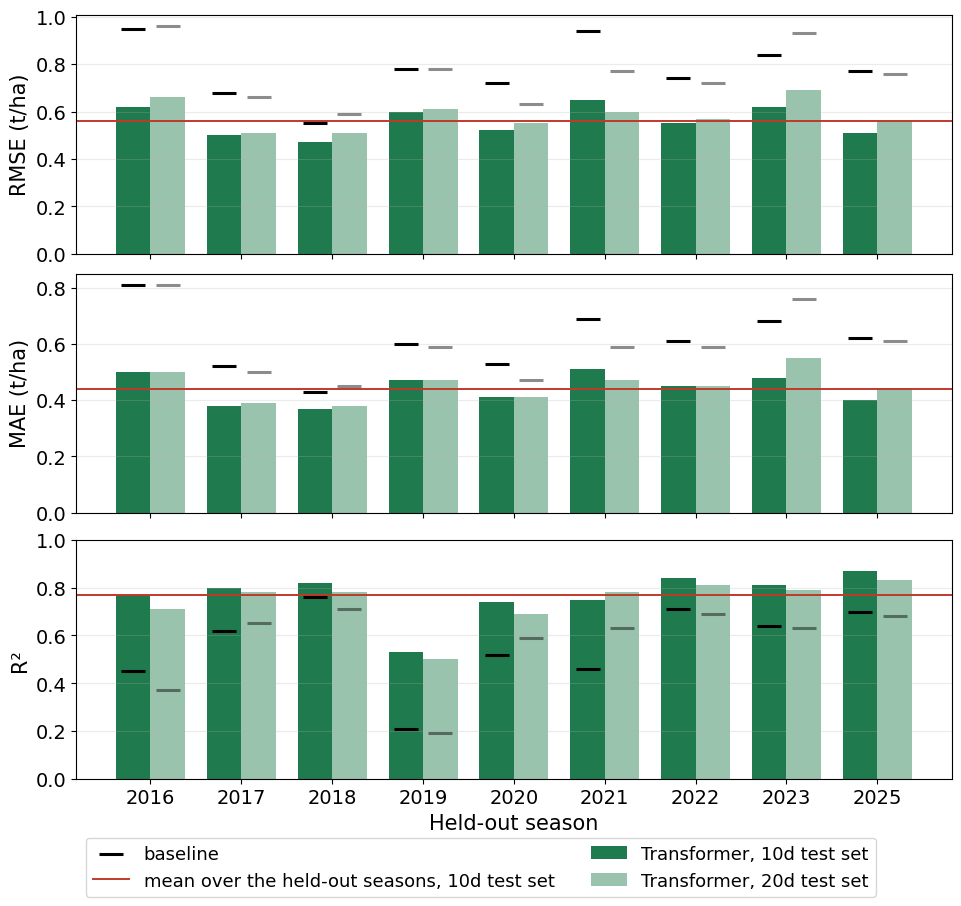

In [14]:
# E1 results per season, the history-only baseline, both aggregates and the sanity check
e01_rows = []
for held_out_year in LOYO_YEARS:
    is_season_row = year == held_out_year
    season_actual = yield_actual[is_season_row]
    season_history = loyo_split(held_out_year)["yield_history"][is_season_row]
    season_metrics = loyo_season_metrics(held_out_year, e01_test_by_year[held_out_year])
    row = {"held-out season": str(held_out_year), "validation season": str(validation_year_for(held_out_year))}
    for subset_name, row_mask in [("10-day complete", is_ten_day_complete[is_season_row]),
                                  ("all counties", np.ones(len(season_actual), bool))]:
        row[f"{subset_name} n"] = int(row_mask.sum())
        for metric_name in ["RMSE (t/ha)", "MAE (t/ha)", "R2"]:
            row[f"{subset_name} {metric_name}"] = season_metrics[f"{subset_name} {metric_name}"]
        baseline_metrics = regression_metrics(season_history[row_mask], season_actual[row_mask])
        row[f"{subset_name} history-only RMSE (t/ha)"] = baseline_metrics["RMSE"] / DT_HA_PER_T_HA
        row[f"{subset_name} history-only MAE (t/ha)"] = baseline_metrics["MAE"] / DT_HA_PER_T_HA
        row[f"{subset_name} history-only R2"] = baseline_metrics["R2"]
    e01_rows.append(row)

e01_table = pd.DataFrame(e01_rows)
value_columns = [c for c in e01_table.columns if c not in ("held-out season", "validation season") and not c.endswith(" n")]
mean_over_seasons = {"held-out season": "mean over seasons", **e01_table[value_columns].mean().to_dict()}
pooled_over_county_years = {"held-out season": "pooled over county-years"}
for subset_name in SUMMARY_SUBSETS:
    pooled_actual = []
    pooled_history = []
    pooled_prediction = []
    for held_out_year in LOYO_YEARS:
        is_season_row = year == held_out_year
        if subset_name == "10-day complete":
            row_mask = is_ten_day_complete[is_season_row]
        else:
            row_mask = np.ones(is_season_row.sum(), bool)
        pooled_actual.append(yield_actual[is_season_row][row_mask])
        pooled_history.append(loyo_split(held_out_year)["yield_history"][is_season_row][row_mask])
        pooled_prediction.append(e01_test_by_year[held_out_year][row_mask])
    pooled_actual = np.concatenate(pooled_actual)
    pooled_metrics = regression_metrics(np.concatenate(pooled_prediction), pooled_actual)
    pooled_over_county_years[f"{subset_name} RMSE (t/ha)"] = pooled_metrics["RMSE"] / DT_HA_PER_T_HA
    pooled_over_county_years[f"{subset_name} MAE (t/ha)"] = pooled_metrics["MAE"] / DT_HA_PER_T_HA
    pooled_over_county_years[f"{subset_name} R2"] = pooled_metrics["R2"]
    pooled_baseline_metrics = regression_metrics(np.concatenate(pooled_history), pooled_actual)
    pooled_over_county_years[f"{subset_name} history-only RMSE (t/ha)"] = pooled_baseline_metrics["RMSE"] / DT_HA_PER_T_HA
    pooled_over_county_years[f"{subset_name} history-only MAE (t/ha)"] = pooled_baseline_metrics["MAE"] / DT_HA_PER_T_HA
    pooled_over_county_years[f"{subset_name} history-only R2"] = pooled_baseline_metrics["R2"]
e01_table = pd.concat([e01_table, pd.DataFrame([mean_over_seasons, pooled_over_county_years])], ignore_index=True)
for subset_name in SUMMARY_SUBSETS:
    e01_table[f"{subset_name} n"] = e01_table[f"{subset_name} n"].astype("Int64")
e01_table = e01_table.round(2)
e01_table.to_csv(os.path.join(experiment_folder(E01_FOLDER), "results.csv"), index=False)
display(e01_table)
record_loyo_in_summary("1.1", "headline transformer (E1)", e01_test_by_year, models=f"{N_MODELS_E01} per fold")
record_single_models("1.1", "headline configuration (2025: E7, LOYO: E1)", loyo_test_bank_by_year=e01_test_bank_by_year,
                     colour=MODEL_COLOURS["headline transformer"])

# sanity check: the 2025 fold is the headline split, so it must not differ from E7
print(f"\nsanity check on {HEADLINE_LABEL}, RMSE (t/ha): 2025 fold {headline_rmse(e01_test_by_year[2025]) / DT_HA_PER_T_HA:.2f}"
      f" | E7 {headline_rmse(e07_test_ensemble) / DT_HA_PER_T_HA:.2f}"
      f" | headline of 01 {headline_rmse(headline_ensemble) / DT_HA_PER_T_HA:.2f}")
print(f"-> 2025 fold against E7: {noise_verdict(headline_rmse(e01_test_by_year[2025]), headline_rmse(e07_test_ensemble))}"
      f" (expected: within noise)")

# figure: the three metrics per held-out season on both test sets, with the baseline as black ticks
# and the mean over the seasons as a horizontal line (the pooled row stays in the table only)
season_table = e01_table.iloc[:len(LOYO_YEARS)]
mean_row = e01_table.iloc[len(LOYO_YEARS)]
positions = np.arange(len(LOYO_YEARS))
bar_width = 0.38
figure, axes = plt.subplots(3, 1, figsize=(9.5, 9.0), sharex=True, layout="constrained")
for axis, metric in zip(axes, ["RMSE (t/ha)", "MAE (t/ha)", "R2"]):
    for subset_name, test_set_name, offset, alpha in [("10-day complete", TEST_SET_10D, -bar_width / 2, 1.0),
                                                      ("all counties", TEST_SET_20D, bar_width / 2, FULL_COHORT_ALPHA)]:
        axis.bar(positions + offset, season_table[f"{subset_name} {metric}"], bar_width,
                 color=MODEL_COLOURS["headline transformer"], alpha=alpha, label=f"Transformer, {test_set_name}")
        axis.scatter(positions + offset, season_table[f"{subset_name} history-only {metric}"], marker="_", s=320,
                     linewidths=2.2, color="black", alpha=alpha, zorder=3,
                     label=BASELINE_NAME if subset_name == "10-day complete" else None)
    axis.axhline(mean_row[f"10-day complete {metric}"], color="#c0392b", linewidth=1.4,
                 label=f"mean over the held-out seasons, {TEST_SET_10D}")
    axis.set_xticks(positions)
    axis.set_xticklabels([str(held_out_year) for held_out_year in LOYO_YEARS])
    axis.set_ylabel(METRIC_AXIS_LABELS["R2" if metric == "R2" else metric.split(" ")[0]])
    if metric == "R2":
        axis.set_ylim(min(0.0, season_table[[f"{s} history-only R2" for s in SUMMARY_SUBSETS]].min().min()), 1.0)
    axis.grid(axis="y", alpha=0.25)
axes[-1].set_xlabel("Held-out season")
legend_handles, legend_labels = axes[0].get_legend_handles_labels()
figure.legend(legend_handles, legend_labels, ncol=2, loc="outside lower center")
save_figure(figure, E01_FOLDER, "loyo_after_season.png")

#### Error and R² maps
Maps of the headline model after the season, for the 2025 holdout (predictions of `01`) and for
leave one year out (E1: every county-year predicted by the models that did not see its season).
The 2025 and leave-one-year-out maps of a quantity share one colour scale.

- **Bias:** predicted minus observed yield. Red counties are over-predicted, blue under-predicted.
  For leave one year out, the mean over the county's seasons.
- **Absolute error:** the size of the miss. For leave one year out, the mean over the county's seasons.
- **R² per state:** R² needs several observations, so it is computed per state (over its counties in
  2025, over its county-years for leave one year out).

All maps show the contiguous United States with state borders (US Census Bureau cartographic boundary
file, 1:20,000,000). **Grey states have no data.** Inside states with data, white counties have no
value, and on the R² maps a white state has fewer than five counties. Counties outside the 10-day
complete set are hatched on the 2025 maps.

In [15]:
# PUBLISHED VERSION: the US Census state boundaries (Data_Ashape/cb_2023_us_state_20m.zip) are not part of
# the repository, so every line that needs them is commented out with the prefix "#CENSUS ", here and in
# the two map cells below. The numbers behind the maps are still computed. The maps themselves are in
# figures/ (the files with "map" in their name), and the outputs shown below are those of the original run.
# To redraw them, download STATE_BOUNDARY_SOURCE into Data_Ashape/, remove every "#CENSUS " prefix and delete
# the line marked "WITHOUT CENSUS" in the in-season map cell.
# Map geometry: contiguous US state borders (US Census Bureau, cartographic boundary file 1:20M) and the
# county shapes of the modelled counties (GADM 3.6), both from Data_Ashape (read only), in an equal-area projection
MAP_PROJECTION = "EPSG:5070"          # Albers equal-area, contiguous United States
#CENSUS STATE_BOUNDARY_FILE = os.path.join(ROOT, "Data_Ashape", "cb_2023_us_state_20m.zip")
STATE_BOUNDARY_SOURCE = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_20m.zip"
NOT_CONTIGUOUS = ["Alaska", "Hawaii", "Puerto Rico"]
NO_DATA_GREY = "#bdbdbd"
MINIMUM_COUNTIES_FOR_STATE_R2 = 5
BIAS_COLORMAP = "RdBu_r"              # red = over-prediction, blue = under-prediction
ABSOLUTE_ERROR_COLORMAP = "YlOrRd"
R2_COLORMAP = "viridis"
R2_LIMITS = (0.0, 1.0)

#CENSUS assert os.path.exists(STATE_BOUNDARY_FILE), f"state borders missing: download {STATE_BOUNDARY_SOURCE} into {os.path.dirname(STATE_BOUNDARY_FILE)}"
#CENSUS conus_states = gpd.read_file("zip://" + STATE_BOUNDARY_FILE)
#CENSUS conus_states = conus_states[~conus_states.NAME.isin(NOT_CONTIGUOUS)][["NAME", "geometry"]].rename(columns={"NAME": "state"})
#CENSUS conus_states = conus_states.to_crs(MAP_PROJECTION)

county_shapes = gpd.read_file(os.path.join(ROOT, "Data_Ashape", "gadm36_USA_2.shp"))
county_shapes = county_shapes[["NAME_1", "NAME_2", "id_comb", "geometry"]].rename(
    columns={"NAME_1": "state", "NAME_2": "county", "id_comb": "county_id"})
county_shapes["county_id"] = county_shapes.county_id.astype(str)
counties_without_shape = set(county_id) - set(county_shapes.county_id)
assert len(counties_without_shape) == 0, f"{len(counties_without_shape)} counties have no shape"
county_shapes = county_shapes[county_shapes.county_id.isin(set(county_id))].to_crs(MAP_PROJECTION)

states_with_data = set(county_shapes.state)
#CENSUS assert states_with_data <= set(conus_states.state), "a state with data is missing from the state borders"
state_by_county = dict(zip(county_shapes.county_id, county_shapes.state))
county_name_by_county = dict(zip(county_shapes.county_id, county_shapes.county))
state_of_row = np.array([state_by_county[c] for c in county_id])
state_of_test_row = state_of_row[is_test_row_2025]


#CENSUS def draw_state_background(axis):
    #CENSUS """Contiguous US: states without data grey, states with data white."""
    #CENSUS conus_states.plot(ax=axis, color=NO_DATA_GREY, edgecolor="none")
    #CENSUS conus_states[conus_states.state.isin(states_with_data)].plot(ax=axis, color="white", edgecolor="none")


#CENSUS def draw_state_borders(axis):
    #CENSUS conus_states.boundary.plot(ax=axis, color="#333333", linewidth=0.5)
    #CENSUS axis.set_axis_off()


#CENSUS def draw_county_values(axis, value_by_county, colormap, value_limits, hatched_counties=()):
    #CENSUS """Colour the counties that have a value; everything else follows draw_state_background."""
    #CENSUS draw_state_background(axis)
    #CENSUS counties_with_value = county_shapes[county_shapes.county_id.isin(list(value_by_county))].copy()
    #CENSUS counties_with_value["value"] = counties_with_value.county_id.map(value_by_county)
    #CENSUS counties_with_value.plot(ax=axis, column="value", cmap=colormap, vmin=value_limits[0], vmax=value_limits[1],
                             #CENSUS edgecolor="none")
    #CENSUS if len(hatched_counties) > 0:
        #CENSUS county_shapes[county_shapes.county_id.isin(list(hatched_counties))].plot(
            #CENSUS ax=axis, facecolor="none", edgecolor="#555555", hatch="//////", linewidth=0)
    #CENSUS draw_state_borders(axis)


#CENSUS def draw_state_values(axis, value_by_state, colormap, value_limits):
    #CENSUS """Colour the states that have a value; everything else follows draw_state_background."""
    #CENSUS draw_state_background(axis)
    #CENSUS states_with_value = conus_states[conus_states.state.isin(list(value_by_state))].copy()
    #CENSUS states_with_value["value"] = states_with_value.state.map(value_by_state)
    #CENSUS states_with_value.plot(ax=axis, column="value", cmap=colormap, vmin=value_limits[0], vmax=value_limits[1],
                           #CENSUS edgecolor="none")
    #CENSUS draw_state_borders(axis)


def add_horizontal_colourbar(figure, axes, colormap, value_limits, label, extend="neither"):
    colour_scale = plt.cm.ScalarMappable(cmap=colormap, norm=plt.Normalize(vmin=value_limits[0], vmax=value_limits[1]))
    figure.colorbar(colour_scale, ax=axes, orientation="horizontal", fraction=0.04, pad=0.02,
                    label=label, extend=extend)


def r2_by_state(actual, prediction, states):
    """R2 per state over its rows; states with fewer than MINIMUM_COUNTIES_FOR_STATE_R2 rows are left out."""
    r2_values = {}
    for state in np.unique(states):
        is_state_row = states == state
        if is_state_row.sum() < MINIMUM_COUNTIES_FOR_STATE_R2:
            continue
        r2_values[state] = regression_metrics(prediction[is_state_row], actual[is_state_row])["R2"]
    return r2_values


#CENSUS def draw_map_figure(map_specification, folder_name):
    #CENSUS """One map figure from a specification dict (level, values, colormap, limits, label, extend, hatched)."""
    #CENSUS figure, axis = plt.subplots(figsize=(11, 7.2), layout="constrained")
    #CENSUS if map_specification["level"] == "county":
        #CENSUS draw_county_values(axis, map_specification["values"], map_specification["colormap"],
                           #CENSUS map_specification["limits"], map_specification.get("hatched", ()))
    #CENSUS else:
        #CENSUS draw_state_values(axis, map_specification["values"], map_specification["colormap"], map_specification["limits"])
    #CENSUS add_horizontal_colourbar(figure, axis, map_specification["colormap"], map_specification["limits"],
                             #CENSUS map_specification["label"], map_specification["extend"])
    #CENSUS save_figure(figure, folder_name, map_specification["file_name"])


#CENSUS print(f"map geometry: {len(conus_states)} contiguous states (with data: {len(states_with_data)}), "
      #CENSUS f"{len(county_shapes)} modelled counties")

map geometry: 49 contiguous states (with data: 21), 759 modelled counties


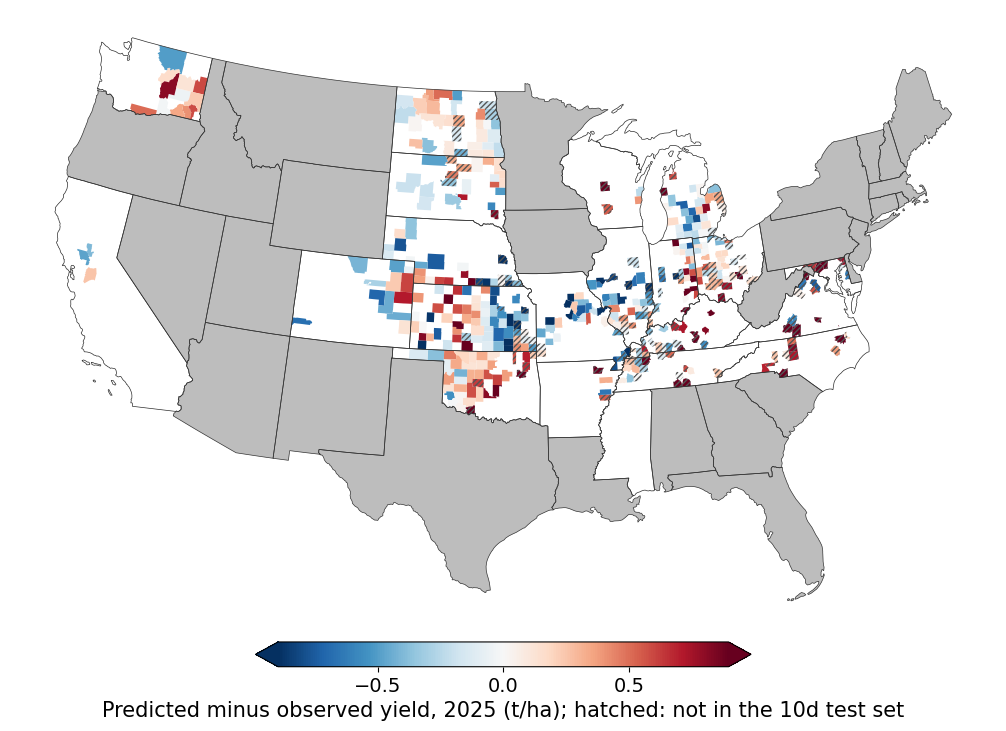

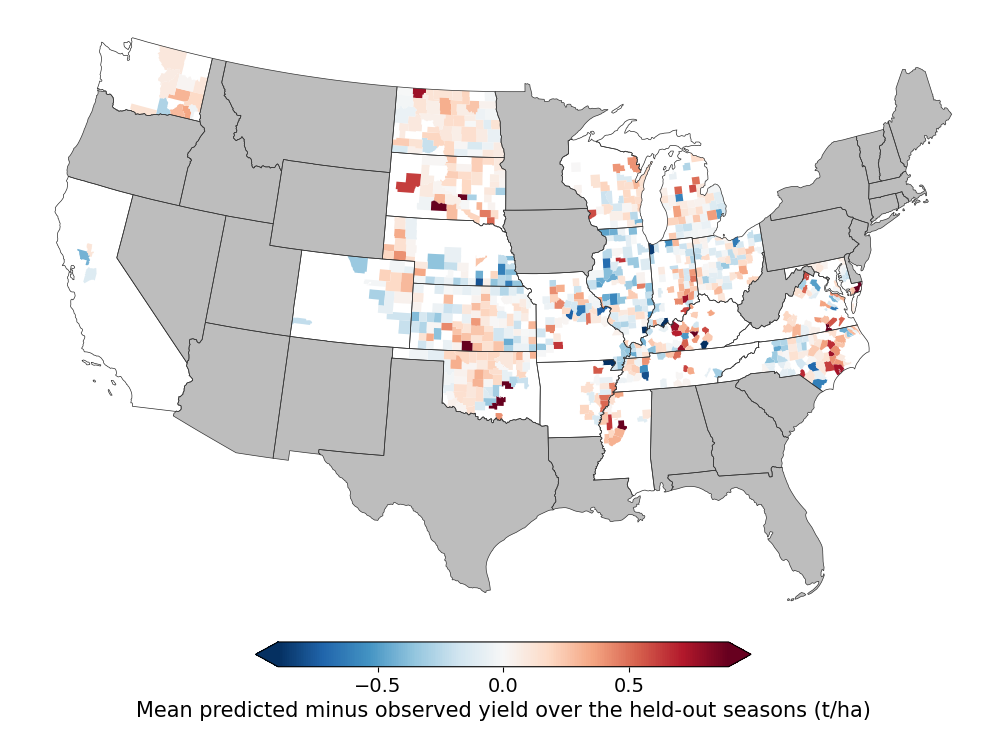

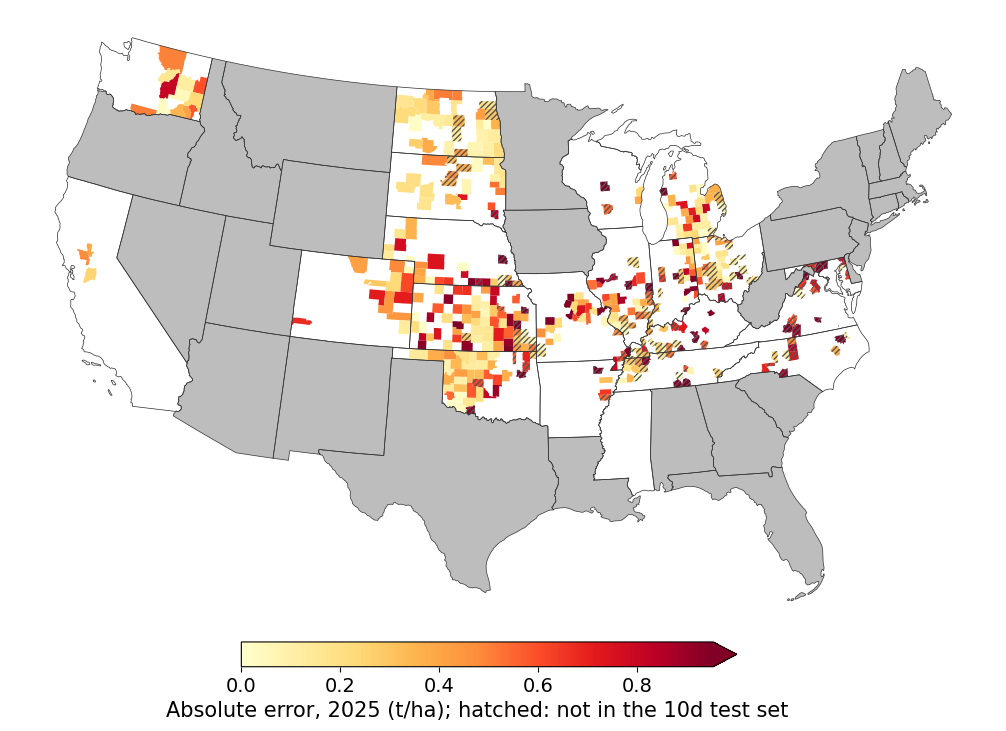

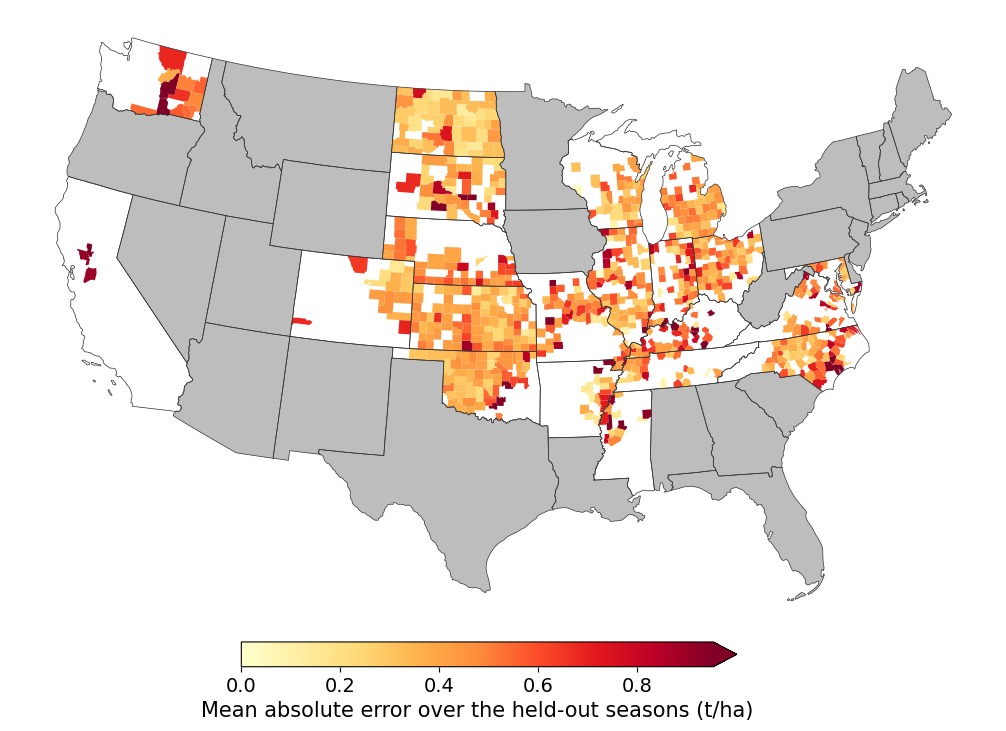

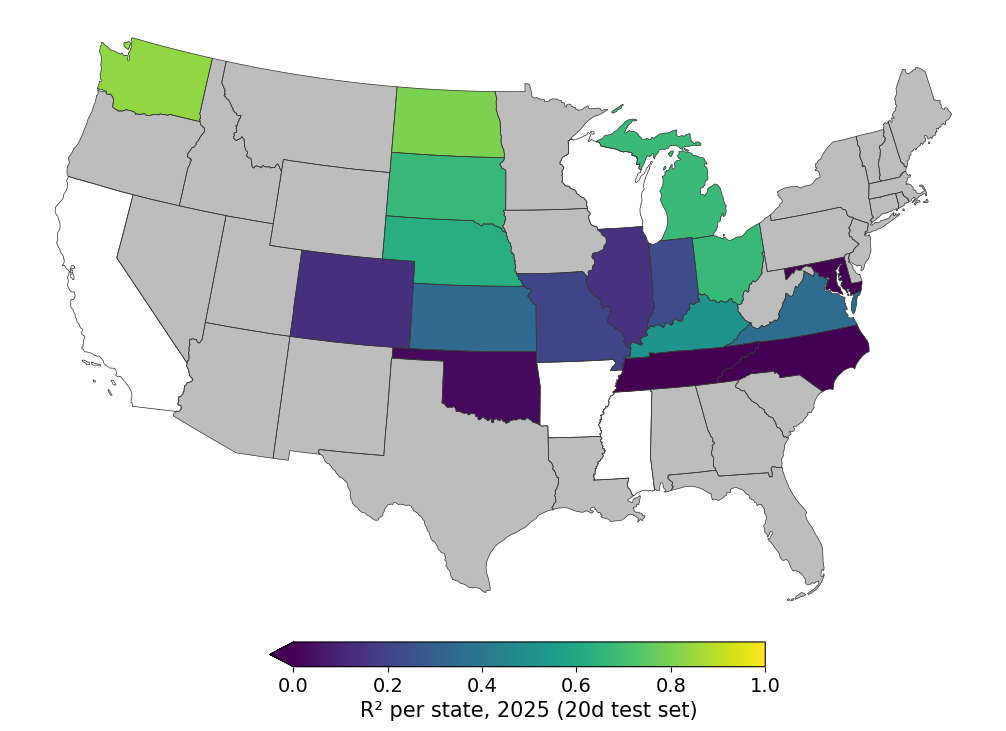

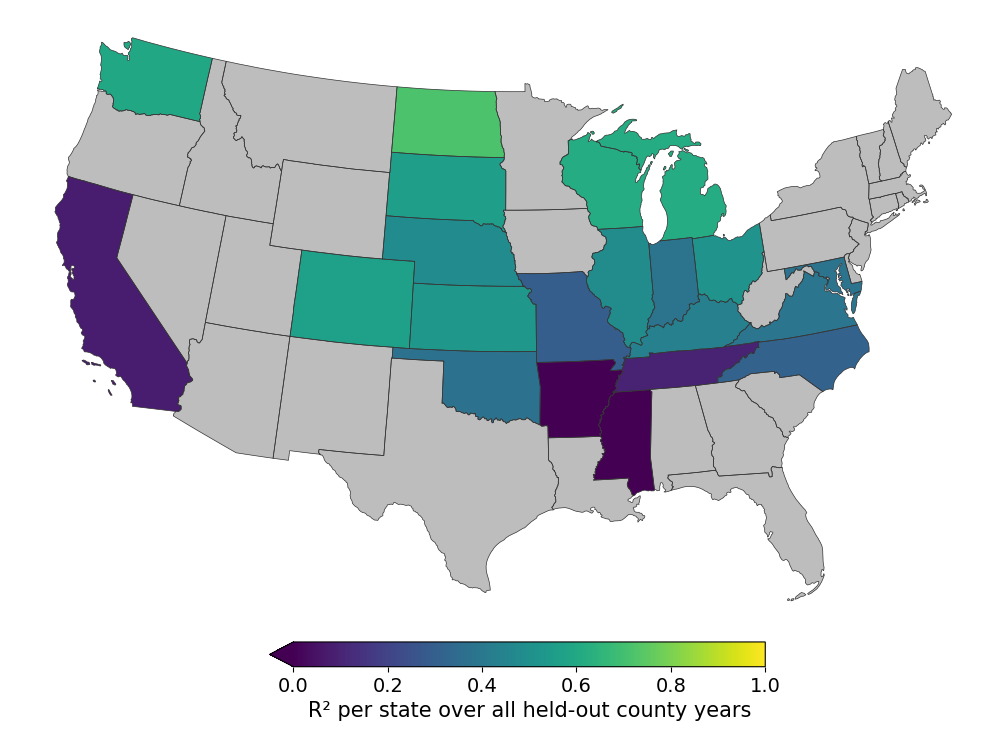

per state (t/ha), sorted by leave-one-year-out bias:


,county_years,bias_loyo,mean_absolute_error_loyo,R2 loyo,counties 2025,bias 2025,mean absolute error 2025,R2 2025
state,,,,,,,,
Illinois,288,-0.16,0.45,0.48,31.0,-0.30,0.47,0.14
California,21,-0.16,0.98,0.08,3.0,-0.21,0.38,NaN
Colorado,79,-0.06,0.40,0.57,12.0,-0.15,0.43,0.14
Nebraska,216,-0.06,0.51,0.48,24.0,-0.16,0.50,0.63
Missouri,207,-0.03,0.51,0.29,26.0,-0.46,0.57,0.20
Ohio,420,-0.01,0.44,0.52,37.0,0.15,0.30,0.67
Kansas,552,0.01,0.40,0.53,63.0,-0.11,0.46,0.34
Tennessee,98,0.01,0.44,0.10,18.0,0.27,0.39,-0.20
Michigan,278,0.03,0.42,0.62,30.0,-0.06,0.33,0.68


most over-predicted counties (at least 5 held-out seasons):


,seasons,bias,mean_absolute_error,county,state
county_id,,,,,
42_46,5,0.62,0.68,Meade,South Dakota
18_5,5,0.54,0.67,Barren,Kentucky
42_65,5,0.52,0.59,Yankton,South Dakota
23_69,6,0.49,0.51,Ogemaw,Michigan
4_39,5,0.49,0.73,Lee,Arkansas
26_37,6,0.49,0.62,Gasconade,Missouri
15_90,7,0.48,0.58,Wayne,Indiana
42_33,6,0.46,0.50,Hutchinson,South Dakota
34_74,8,0.41,0.52,Pitt,North Carolina


most under-predicted counties (at least 5 held-out seasons):


,seasons,bias,mean_absolute_error,county,state
county_id,,,,,
28_67,5,-0.62,0.62,Pawnee,Nebraska
23_58,5,-0.60,0.63,Mecosta,Michigan
43_9,5,-0.56,0.56,Carroll,Tennessee
47_43,7,-0.49,0.49,Fauquier,Virginia
23_54,7,-0.49,0.50,Macomb,Michigan
14_31,6,-0.45,0.47,Greene,Illinois
14_61,6,-0.45,0.67,Mason,Illinois
17_25,5,-0.44,0.47,Elk,Kansas
14_86,7,-0.44,0.63,Schuyler,Illinois


In [16]:
# After-season maps: 2025 holdout (headline of 01) and leave one year out (E1)
error_2025 = (headline_ensemble - yield_actual_test) / DT_HA_PER_T_HA
bias_2025_by_county = dict(zip(county_id_test, error_2025))
absolute_error_2025_by_county = dict(zip(county_id_test, np.abs(error_2025)))
counties_outside_headline_cohort = county_id_test[~is_headline_cohort]

loyo_prediction = np.full(n_county_years, np.nan, np.float32)
for held_out_year in LOYO_YEARS:
    loyo_prediction[year == held_out_year] = e01_test_by_year[held_out_year]
loyo_errors = pd.DataFrame({"county_id": county_id, "state": state_of_row, "year": year,
                            "error (t/ha)": (loyo_prediction - yield_actual) / DT_HA_PER_T_HA})
loyo_errors["absolute error (t/ha)"] = loyo_errors["error (t/ha)"].abs()
loyo_by_county = loyo_errors.groupby("county_id").agg(seasons=("year", "count"),
                                                      bias=("error (t/ha)", "mean"),
                                                      mean_absolute_error=("absolute error (t/ha)", "mean"))
r2_2025_by_state = r2_by_state(yield_actual_test, headline_ensemble, state_of_test_row)
r2_loyo_by_state = r2_by_state(yield_actual, loyo_prediction, state_of_row)

# shared colour limits (95th percentile), so each pair of maps reads on one scale
bias_limit = np.percentile(np.abs(np.concatenate([error_2025, loyo_by_county["bias"].to_numpy()])), 95)
absolute_error_limit = np.percentile(np.concatenate([np.abs(error_2025), loyo_by_county["mean_absolute_error"].to_numpy()]), 95)
hatch_note = f"hatched: not in the {TEST_SET_10D}"
after_season_maps = [
    dict(file_name="map_bias_2025.png", level="county", values=bias_2025_by_county, colormap=BIAS_COLORMAP,
         limits=(-bias_limit, bias_limit), extend="both", hatched=counties_outside_headline_cohort,
         label=f"Predicted minus observed yield, 2025 (t/ha); {hatch_note}"),
    dict(file_name="map_bias_loyo.png", level="county", values=loyo_by_county["bias"].to_dict(), colormap=BIAS_COLORMAP,
         limits=(-bias_limit, bias_limit), extend="both",
         label="Mean predicted minus observed yield over the held-out seasons (t/ha)"),
    dict(file_name="map_absolute_error_2025.png", level="county", values=absolute_error_2025_by_county,
         colormap=ABSOLUTE_ERROR_COLORMAP, limits=(0, absolute_error_limit), extend="max",
         hatched=counties_outside_headline_cohort, label=f"Absolute error, 2025 (t/ha); {hatch_note}"),
    dict(file_name="map_absolute_error_loyo.png", level="county", values=loyo_by_county["mean_absolute_error"].to_dict(),
         colormap=ABSOLUTE_ERROR_COLORMAP, limits=(0, absolute_error_limit), extend="max",
         label="Mean absolute error over the held-out seasons (t/ha)"),
    dict(file_name="map_r2_state_2025.png", level="state", values=r2_2025_by_state, colormap=R2_COLORMAP,
         limits=R2_LIMITS, extend="min", label=f"R² per state, 2025 ({TEST_SET_20D})"),
    dict(file_name="map_r2_state_loyo.png", level="state", values=r2_loyo_by_state, colormap=R2_COLORMAP,
         limits=R2_LIMITS, extend="min", label="R² per state over all held-out county years"),
]
# drawing the maps needs the US Census state boundaries, see the map geometry cell
#CENSUS for map_specification in after_season_maps:
    #CENSUS draw_map_figure(map_specification, "maps_after_season")

# numbers behind the maps, for describing unusual regions in the text
state_summary = loyo_errors.groupby("state").agg(county_years=("year", "count"),
                                                 bias_loyo=("error (t/ha)", "mean"),
                                                 mean_absolute_error_loyo=("absolute error (t/ha)", "mean"))
state_summary["R2 loyo"] = state_summary.index.map(r2_loyo_by_state)
state_summary_2025 = pd.DataFrame({"state": state_of_test_row, "error": error_2025}).groupby("state")
state_summary["counties 2025"] = state_summary_2025.size()
state_summary["bias 2025"] = state_summary_2025["error"].mean()
state_summary["mean absolute error 2025"] = state_summary_2025["error"].apply(lambda errors: errors.abs().mean())
state_summary["R2 2025"] = state_summary.index.map(r2_2025_by_state)
state_summary = state_summary.sort_values("bias_loyo").round(2)
state_summary.to_csv(os.path.join(experiment_folder("maps_after_season"), "state_summary.csv"))
print("per state (t/ha), sorted by leave-one-year-out bias:")
display(state_summary)

counties_with_many_seasons = loyo_by_county[loyo_by_county.seasons >= 5].copy()
counties_with_many_seasons["county"] = counties_with_many_seasons.index.map(county_name_by_county)
counties_with_many_seasons["state"] = counties_with_many_seasons.index.map(state_by_county)
counties_with_many_seasons.to_csv(os.path.join(experiment_folder("maps_after_season"), "county_summary_loyo.csv"))
print("most over-predicted counties (at least 5 held-out seasons):")
display(counties_with_many_seasons.nlargest(10, "bias").round(2))
print("most under-predicted counties (at least 5 held-out seasons):")
display(counties_with_many_seasons.nsmallest(10, "bias").round(2))

#### Observed against predicted
Three panels as separate figures: the 2025 holdout on the 10-day complete counties and on all
counties (headline of `01`), and every county-year of the leave-one-year-out seasons (E1). The same three
also as one figure on one axis range.

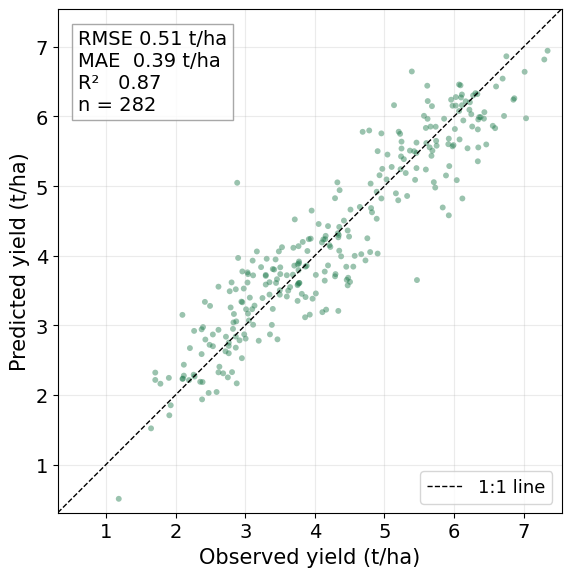

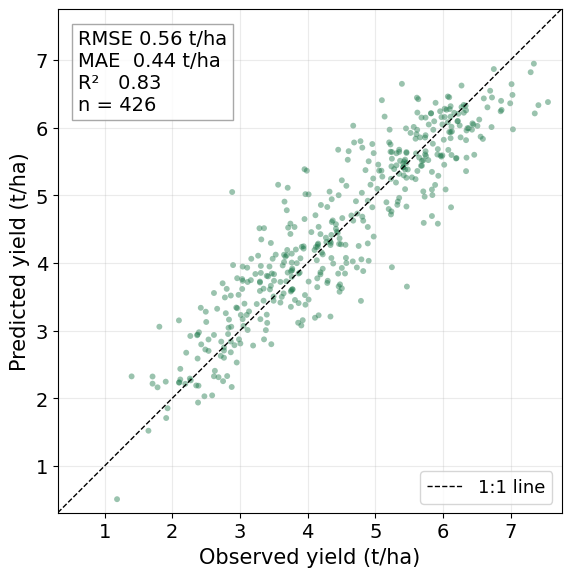

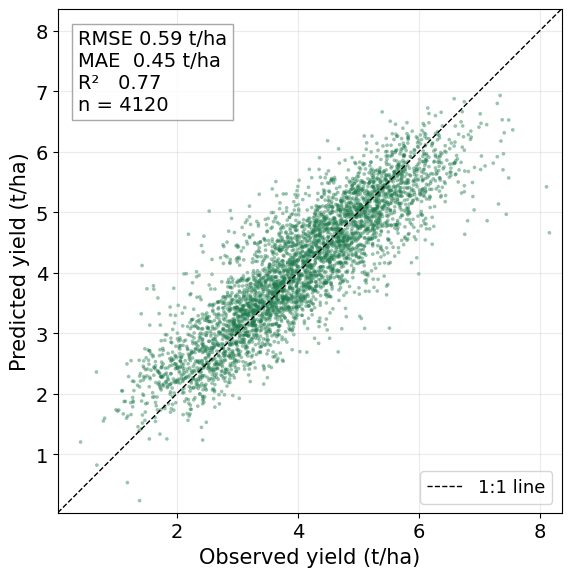

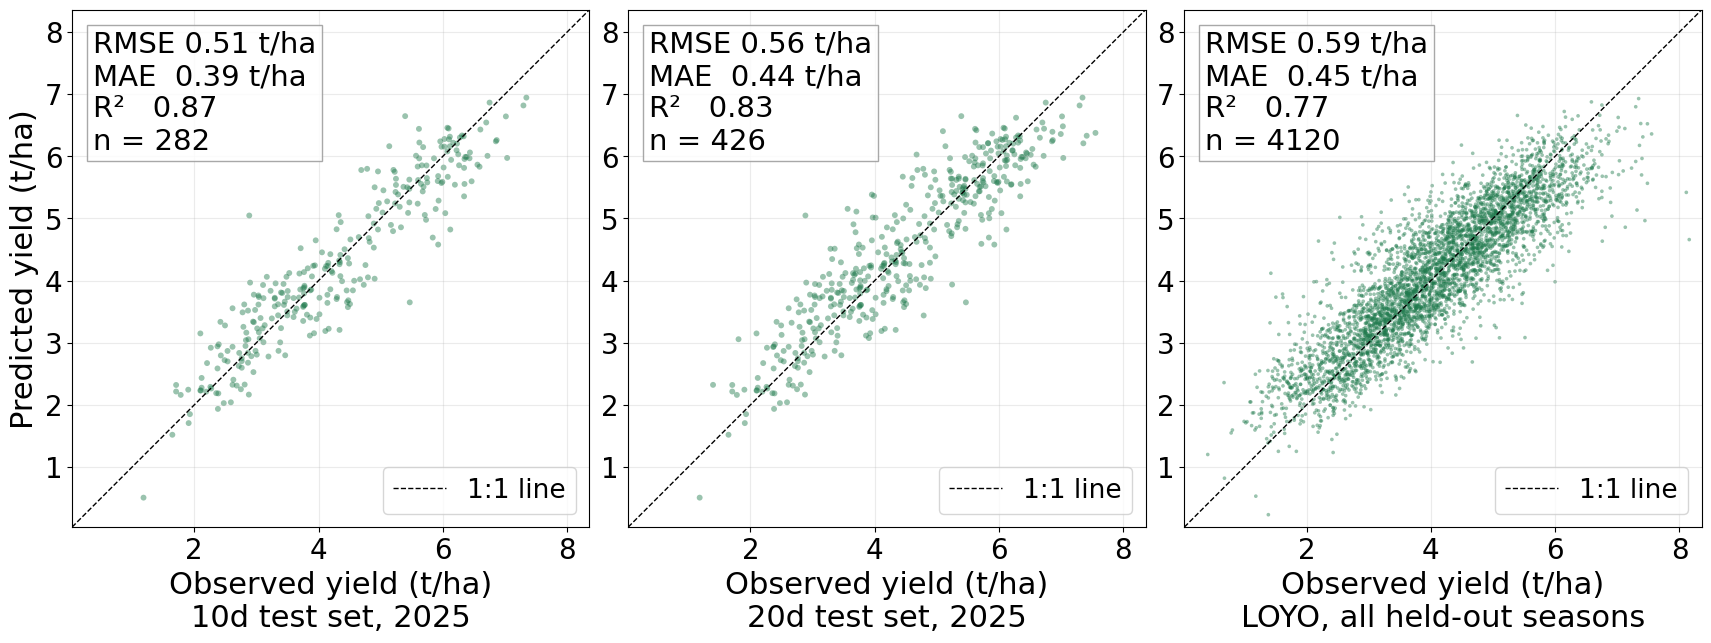

False

In [17]:
# Observed (x) against predicted (y)
plot_parity(yield_actual_test[is_headline_cohort], headline_ensemble[is_headline_cohort],
            MODEL_COLOURS["headline transformer"], "parity_after_season", "parity_2025_10d_test_set.png")
plot_parity(yield_actual_test, headline_ensemble,
            MODEL_COLOURS["headline transformer"], "parity_after_season", "parity_2025_20d_test_set.png")
plot_parity(yield_actual, loyo_prediction,
            MODEL_COLOURS["headline transformer"], "parity_after_season", "parity_loyo.png", point_size=7)

# the three next to each other, on one axis range so the spread compares directly
parity_panels = [(yield_actual_test[is_headline_cohort], headline_ensemble[is_headline_cohort], f"{TEST_SET_10D}, 2025", 18),
                 (yield_actual_test, headline_ensemble, f"{TEST_SET_20D}, 2025", 18),
                 (yield_actual, loyo_prediction, "LOYO, all held-out seasons", 7)]
all_values = np.concatenate([np.concatenate([actual, prediction]) for actual, prediction, _, _ in parity_panels]) / DT_HA_PER_T_HA
lower_limit, upper_limit = all_values.min() - 0.2, all_values.max() + 0.2
# three panels side by side print at about a third of their size, so this figure gets larger text
parity_text = plt.rc_context({"font.size": 21, "axes.labelsize": 22, "xtick.labelsize": 20, "ytick.labelsize": 20,
                              "legend.fontsize": 19})
parity_text.__enter__()
figure, axes = plt.subplots(1, 3, figsize=(17, 6.8), layout="constrained")
for axis, (actual, prediction, panel_label, point_size) in zip(axes, parity_panels):
    actual_t_per_ha = np.asarray(actual) / DT_HA_PER_T_HA
    prediction_t_per_ha = np.asarray(prediction) / DT_HA_PER_T_HA
    metrics = regression_metrics(prediction_t_per_ha, actual_t_per_ha)
    axis.scatter(actual_t_per_ha, prediction_t_per_ha, s=point_size, alpha=0.45,
                 color=MODEL_COLOURS["headline transformer"], edgecolor="none")
    axis.plot([lower_limit, upper_limit], [lower_limit, upper_limit], "k--", linewidth=1, label="1:1 line")
    axis.set_xlim(lower_limit, upper_limit)
    axis.set_ylim(lower_limit, upper_limit)
    axis.set_aspect("equal")
    axis.set_xlabel(f"Observed yield (t/ha)\n{panel_label}")
    axis.text(0.04, 0.96, f"RMSE {metrics['RMSE']:.2f} t/ha\nMAE  {metrics['MAE']:.2f} t/ha\n"
                          f"R²   {metrics['R2']:.2f}\nn = {len(actual_t_per_ha)}",
              transform=axis.transAxes, va="top", ha="left",
              bbox={"facecolor": "white", "edgecolor": "#999999", "alpha": 0.85})
    axis.legend(loc="lower right")
    axis.grid(alpha=0.25)
axes[0].set_ylabel("Predicted yield (t/ha)")
save_figure(figure, "parity_after_season", "parity_combined.png")
parity_text.__exit__(None, None, None)

### 1.2 In-season forecast

#### The 2025 horizon curve on both test sets (from `01`'s cache)
The prefix-retrained models of `01` section 4 (30 per horizon, `cache/inseason_D`, read only),
evaluated on the 10-day complete counties and on all counties. The pre-season point is the
history-only baseline.

30 models per horizon; pre-season = history only


,forecast date,282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%)
0,pre-season,0.77,0.62,0.70,18.0,0.76,0.61,0.68,16.9
1,Apr 26,0.61,0.49,0.81,14.4,0.64,0.50,0.77,14.3
2,May 16,0.59,0.46,0.82,13.8,0.63,0.49,0.78,14.0
3,Jun 5,0.57,0.45,0.84,13.2,0.60,0.48,0.80,13.5
4,Jun 25,0.52,0.41,0.86,12.3,0.57,0.45,0.82,12.7
5,Jul 15,0.52,0.40,0.86,12.0,0.56,0.44,0.83,12.6
6,Aug 4,0.51,0.39,0.87,11.8,0.55,0.43,0.83,12.4
7,Aug 24,0.51,0.39,0.87,11.8,0.56,0.44,0.83,12.4


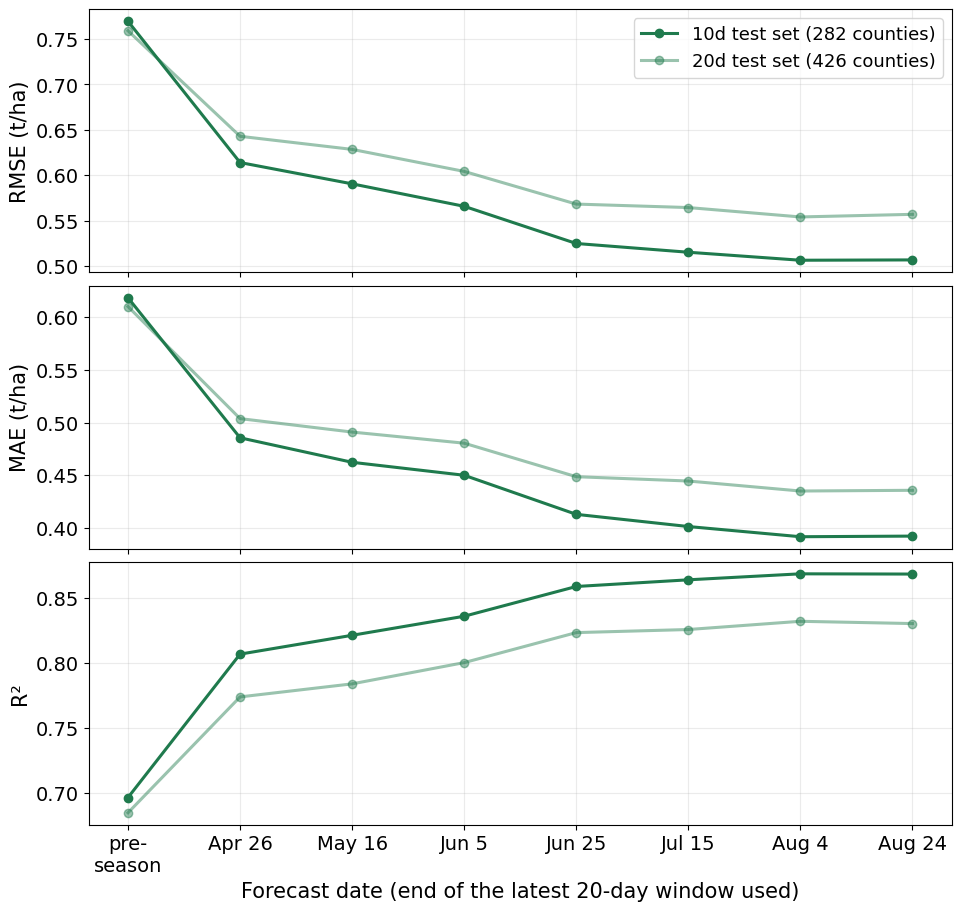

In [19]:
# 2025 in-season curve from notebook 01's per-horizon models
FORECAST_DATES = ["pre-season"] + WINDOW_END_DATES
inseason_folder = os.path.join(CACHE, "inseason_D")
n_inseason_models = len(glob.glob(os.path.join(inseason_folder, "D_h1_seed*.npy")))

inseason_prediction_2025 = {0: yield_history_test}
for horizon in range(1, N_WINDOWS + 1):
    horizon_bank = np.array([np.load(os.path.join(inseason_folder, f"D_h{horizon}_seed{seed}.npy"))
                             for seed in range(n_inseason_models)])
    inseason_prediction_2025[horizon] = horizon_bank.mean(axis=0)

inseason_rows = []
inseason_metrics = {}
for horizon, prediction in inseason_prediction_2025.items():
    inseason_metrics[horizon] = cohort_metrics(prediction)
    inseason_rows.append({"forecast date": FORECAST_DATES[horizon], **test_table_columns(prediction)})
inseason_table = pd.DataFrame(inseason_rows)
inseason_table.to_csv(os.path.join(experiment_folder("inseason_2025_curve"), "results.csv"), index=False)
print(f"{n_inseason_models} models per horizon; pre-season = history only")
display(inseason_table)

figure, axes = plt.subplots(3, 1, figsize=(9.5, 9.0), sharex=True, layout="constrained")
positions = np.arange(len(FORECAST_DATES))
for axis, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    for cohort, alpha, label in [("headline", 1.0, f"{TEST_SET_10D} ({HEADLINE_LABEL})"),
                                 ("full", FULL_COHORT_ALPHA, f"{TEST_SET_20D} ({FULL_LABEL})")]:
        values = [inseason_metrics[horizon][cohort][metric] for horizon in range(len(FORECAST_DATES))]
        axis.plot(positions, values, "-o", color=MODEL_COLOURS["headline transformer"], alpha=alpha, linewidth=2.2, label=label)
    axis.set_xticks(positions)
    axis.set_xticklabels(["pre-\nseason"] + WINDOW_END_DATES)
    axis.set_ylabel(METRIC_AXIS_LABELS[metric])
    axis.grid(alpha=0.25)
axes[-1].set_xlabel("Forecast date (end of the latest 20-day window used)")
axes[0].legend()
save_figure(figure, "inseason_2025_curve", "inseason_2025.png")

#### E2 — Leave one year out, in-season
The folds of E1. For every horizon *h* (1 to 7 windows) the model is retrained on the prefix
of the season, exactly as in `01` section 4, with tokens and scalers re-derived on the prefix.
30 models per fold per horizon. The full-season horizon is the E1 configuration with the same seeds,
so its models are those of the E1 fold rather than a second copy. The history-only
baseline (pre-season) uses each fold's own history median fill. Evaluated on the 10-day complete
counties of each held-out season.

In [20]:
# E2: prefix retraining per fold and horizon
N_MODELS_E02 = N_MODELS_PER_ENSEMBLE
assert N_MODELS_E02 <= N_MODELS_E01, "the full-season horizon reuses the E1 models of each fold"

e02_test_banks = {}
for held_out_year in LOYO_YEARS:
    for horizon in range(1, N_WINDOWS + 1):
        fold_split, fold_tokens, fold_coverage = prepare_loyo_fold(held_out_year, n_windows=horizon)
        if horizon == N_WINDOWS:
            folder_name = os.path.join(E01_FOLDER, f"fold_{held_out_year}")
        else:
            folder_name = os.path.join(E02_FOLDER, f"fold_{held_out_year}", f"horizon_{horizon}")
        _, horizon_test_bank = load_or_train_bank(
            folder_name, N_MODELS_E02,
            lambda seed: train_headline_model(fold_tokens, fold_coverage, fold_split, seed))
        e02_test_banks[(held_out_year, horizon)] = horizon_test_bank
    print(f"fold {held_out_year}: horizons 1-{N_WINDOWS} ready", flush=True)
print(f"E2 uses {N_MODELS_E02} models per fold per horizon")

fold 2016: horizons 1-7 ready


fold 2017: horizons 1-7 ready


fold 2018: horizons 1-7 ready


fold 2019: horizons 1-7 ready


fold 2020: horizons 1-7 ready


fold 2021: horizons 1-7 ready


fold 2022: horizons 1-7 ready


fold 2023: horizons 1-7 ready


fold 2025: horizons 1-7 ready


E2 uses 30 models per fold per horizon


RMSE (t/ha) on 10-day complete counties, 30 models per fold per horizon; pre-season = history only


held-out season,2016,2017,2018,2019,2020,2021,2022,2023,2025
pre-season,0.95,0.68,0.55,0.78,0.72,0.94,0.74,0.84,0.77
Apr 26,0.83,0.61,0.54,0.76,0.67,0.98,0.71,0.74,0.62
May 16,0.78,0.59,0.55,0.72,0.61,0.97,0.67,0.71,0.59
Jun 5,0.68,0.59,0.50,0.64,0.54,0.85,0.54,0.66,0.58
Jun 25,0.62,0.54,0.49,0.62,0.56,0.70,0.54,0.64,0.52
Jul 15,0.63,0.51,0.48,0.60,0.54,0.67,0.57,0.63,0.51
Aug 4,0.63,0.51,0.48,0.61,0.52,0.66,0.56,0.62,0.51
Aug 24,0.62,0.50,0.47,0.60,0.52,0.65,0.55,0.62,0.51


,mean over folds,std over folds,min,max
pre-season,0.77,0.13,0.55,0.95
Apr 26,0.72,0.13,0.54,0.98
May 16,0.69,0.13,0.55,0.97
Jun 5,0.62,0.10,0.50,0.85
Jun 25,0.58,0.07,0.49,0.70
Jul 15,0.57,0.07,0.48,0.67
Aug 4,0.57,0.06,0.48,0.66
Aug 24,0.56,0.06,0.47,0.65


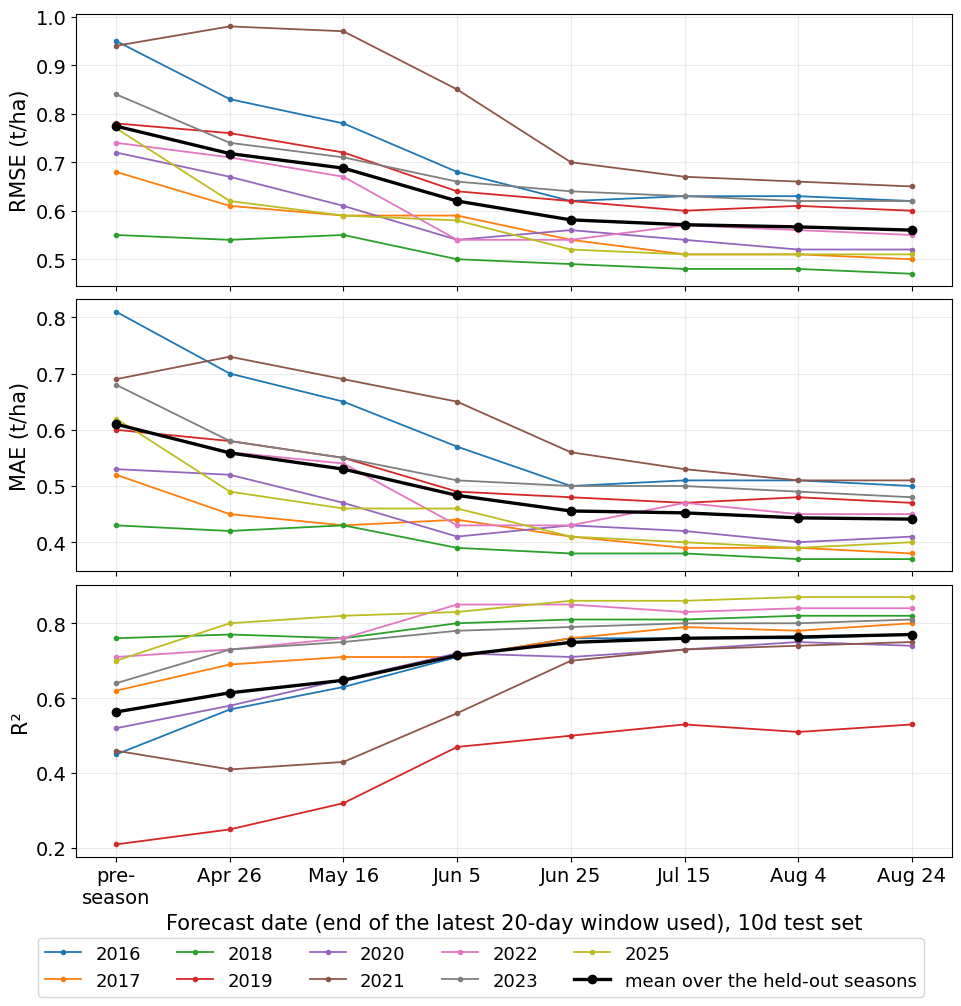

In [21]:
# E2 horizon curves per fold (10-day complete counties), with mean and spread across folds
SEASON_COLOURS = dict(zip(LOYO_YEARS, plt.get_cmap("tab10").colors))
e02_rows = []
for held_out_year in LOYO_YEARS:
    is_season_row = year == held_out_year
    season_actual = yield_actual[is_season_row]
    season_history = loyo_split(held_out_year)["yield_history"][is_season_row]
    season_is_ten_day_complete = is_ten_day_complete[is_season_row]
    for horizon in range(0, N_WINDOWS + 1):
        if horizon == 0:
            horizon_prediction = season_history
        else:
            horizon_prediction = e02_test_banks[(held_out_year, horizon)].mean(axis=0)
        e02_rows.append({
            "held-out season": held_out_year,
            "horizon": horizon,
            "forecast date": FORECAST_DATES[horizon],
            **metrics_t_per_ha(horizon_prediction[season_is_ten_day_complete],
                               season_actual[season_is_ten_day_complete], label="10-day complete"),
            **metrics_t_per_ha(horizon_prediction, season_actual, label="all counties"),
        })
e02_long_table = pd.DataFrame(e02_rows)
e02_long_table.to_csv(os.path.join(experiment_folder(E02_FOLDER), "results_per_fold.csv"), index=False)

curve_by_fold = e02_long_table.pivot(index="horizon", columns="held-out season", values="10-day complete RMSE (t/ha)")
curve_by_fold.index = FORECAST_DATES
e02_summary = pd.DataFrame({
    "mean over folds": curve_by_fold.mean(axis=1),
    "std over folds": curve_by_fold.std(axis=1),
    "min": curve_by_fold.min(axis=1),
    "max": curve_by_fold.max(axis=1),
})
e02_summary.to_csv(os.path.join(experiment_folder(E02_FOLDER), "results_summary.csv"))
print(f"RMSE (t/ha) on 10-day complete counties, {N_MODELS_E02} models per fold per horizon;"
      f" pre-season = history only")
display(curve_by_fold.round(2))
display(e02_summary.round(2))

positions = np.arange(len(FORECAST_DATES))
figure, axes = plt.subplots(3, 1, figsize=(9.5, 10.0), sharex=True, layout="constrained")
for axis, metric in zip(axes, ["RMSE (t/ha)", "MAE (t/ha)", "R2"]):
    metric_by_fold = e02_long_table.pivot(index="horizon", columns="held-out season",
                                          values=f"10-day complete {metric}")
    for held_out_year in LOYO_YEARS:
        axis.plot(positions, metric_by_fold[held_out_year], "-", marker=".", color=SEASON_COLOURS[held_out_year],
                  linewidth=1.3, label=str(held_out_year))
    axis.plot(positions, metric_by_fold.mean(axis=1), "-o", color="black", linewidth=2.4,
              label="mean over the held-out seasons")
    axis.set_xticks(positions)
    axis.set_xticklabels(["pre-\nseason"] + WINDOW_END_DATES)
    axis.set_ylabel(METRIC_AXIS_LABELS['R2' if metric == 'R2' else metric.split(' ')[0]])
    axis.grid(alpha=0.25)
axes[-1].set_xlabel(f"Forecast date (end of the latest 20-day window used), {TEST_SET_10D}")
legend_handles, legend_labels = axes[0].get_legend_handles_labels()
figure.legend(legend_handles, legend_labels, ncol=5, loc="outside lower center")
save_figure(figure, E02_FOLDER, "inseason_loyo.png")

#### In-season maps, 2025, 10-day complete counties
One small map per forecast date (models of `01`), for bias, absolute error and R² per state. All
panels of one figure share a colour scale.

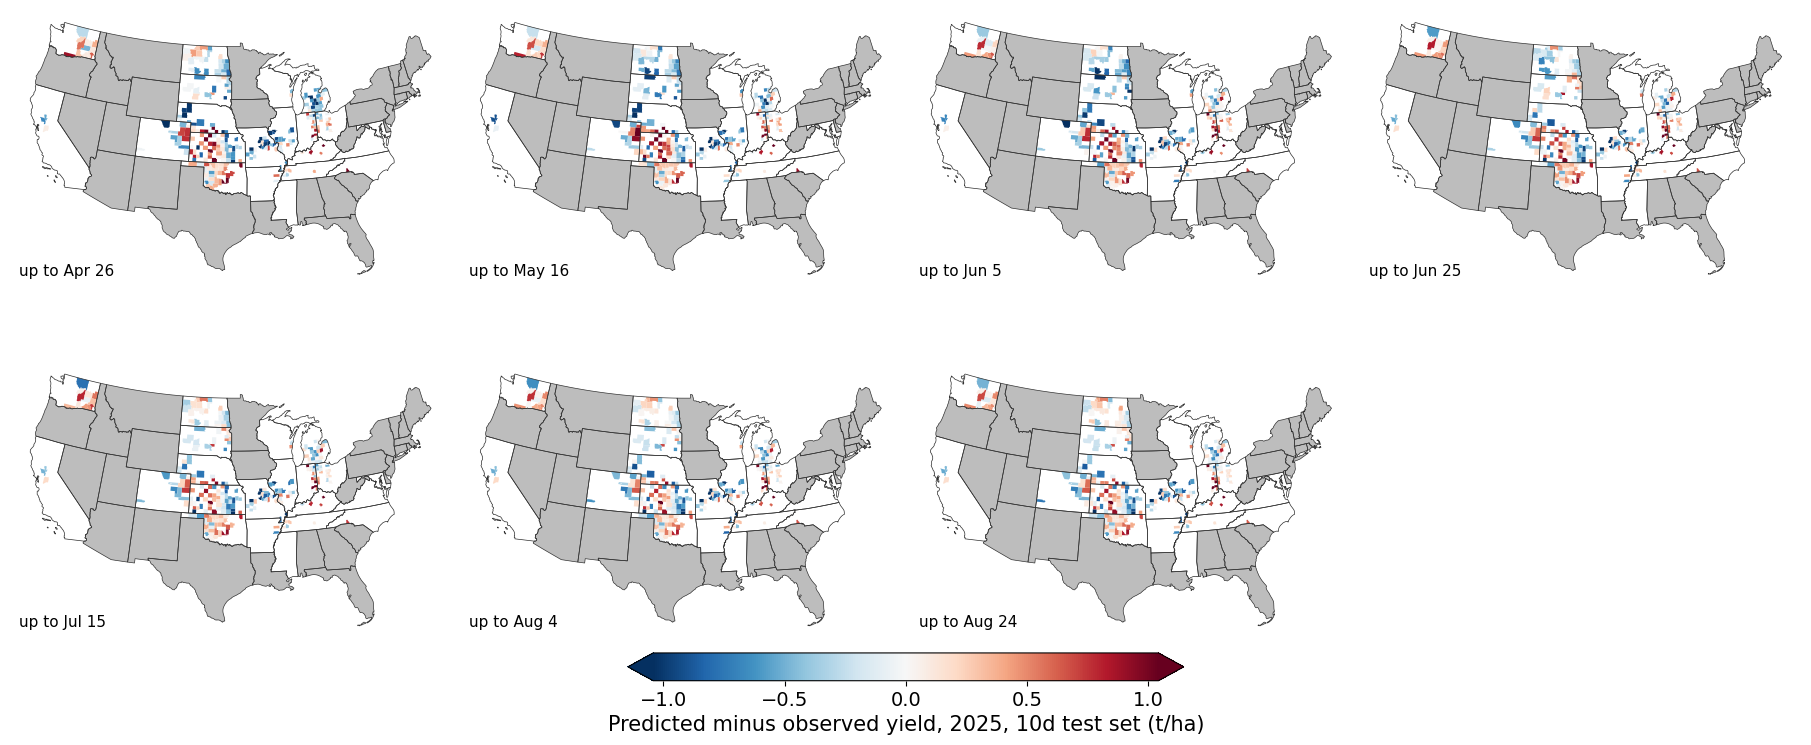

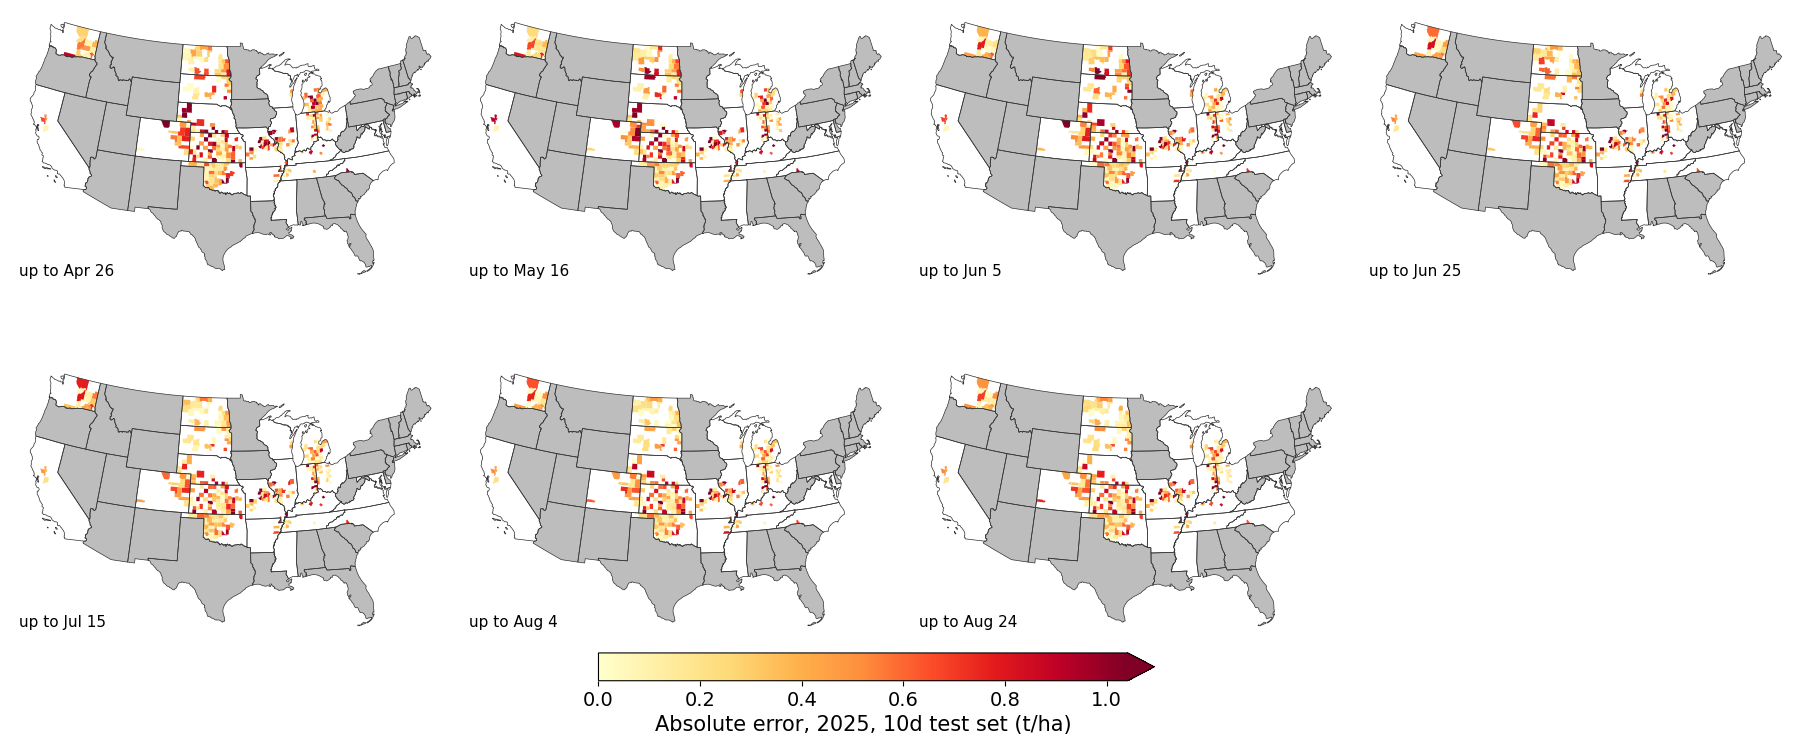

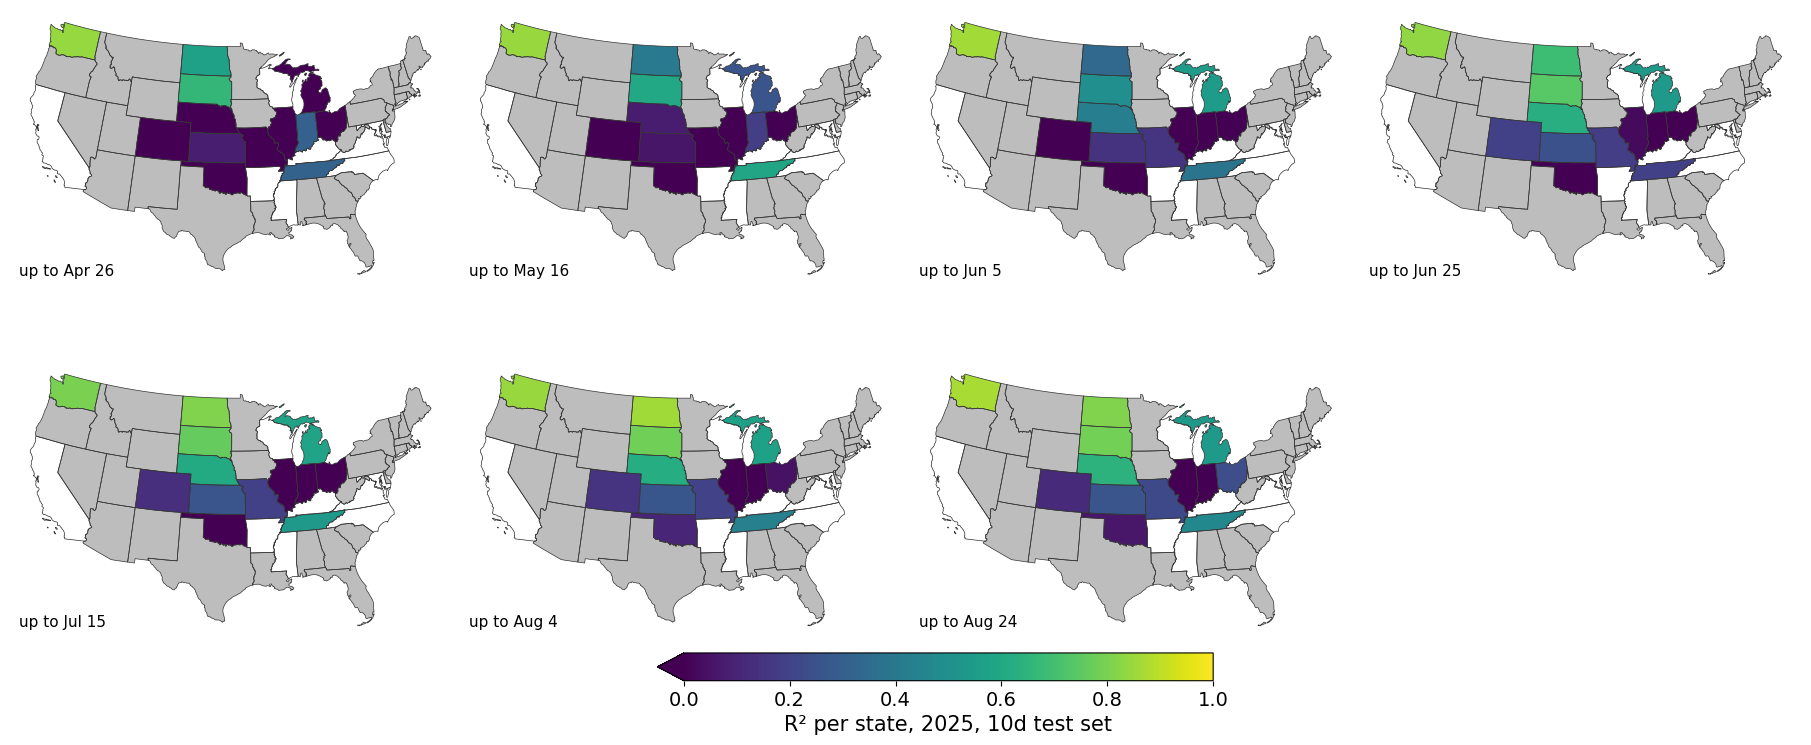

R² per state (states with at least 5 10-day complete counties):


forecast date,Apr 26,May 16,Jun 5,Jun 25,Jul 15,Aug 4,Aug 24
Colorado,-0.30,-0.48,-0.17,0.19,0.14,0.15,0.12
Illinois,-0.94,-0.41,-0.04,0.03,-0.29,-0.18,-0.23
Indiana,0.31,0.18,-0.28,-0.20,0.00,-0.06,-0.03
Kansas,0.08,0.06,0.15,0.25,0.26,0.27,0.26
Michigan,-0.33,0.26,0.55,0.54,0.58,0.57,0.54
Missouri,-0.17,-0.01,0.15,0.18,0.19,0.20,0.22
Nebraska,-0.02,0.08,0.42,0.63,0.61,0.62,0.64
North Dakota,0.57,0.41,0.33,0.69,0.81,0.86,0.81
Ohio,-0.38,-0.22,-0.61,-0.35,-0.06,0.04,0.24
Oklahoma,-0.44,-0.03,-0.08,-0.13,-0.05,0.10,0.06


In [22]:
# In-season maps per forecast date on the 10-day complete counties of 2025
headline_county_ids = county_id_test[is_headline_cohort]
headline_actual = yield_actual_test[is_headline_cohort]
headline_states = state_of_test_row[is_headline_cohort]
inseason_error = {horizon: (inseason_prediction_2025[horizon][is_headline_cohort] - headline_actual) / DT_HA_PER_T_HA
                  for horizon in range(1, N_WINDOWS + 1)}
all_inseason_errors = np.concatenate(list(inseason_error.values()))
inseason_bias_limit = np.percentile(np.abs(all_inseason_errors), 95)
inseason_absolute_error_limit = np.percentile(np.abs(all_inseason_errors), 95)

inseason_map_figures = [
    ("map_inseason_bias.png", BIAS_COLORMAP, (-inseason_bias_limit, inseason_bias_limit), "both",
     f"Predicted minus observed yield, 2025, {TEST_SET_10D} (t/ha)"),
    ("map_inseason_absolute_error.png", ABSOLUTE_ERROR_COLORMAP, (0, inseason_absolute_error_limit), "max",
     f"Absolute error, 2025, {TEST_SET_10D} (t/ha)"),
    ("map_inseason_r2_state.png", R2_COLORMAP, R2_LIMITS, "min",
     f"R² per state, 2025, {TEST_SET_10D}"),
]
inseason_state_r2_rows = []
# drawing the maps needs the US Census state boundaries, see the map geometry cell
for file_name, colormap, limits, extend, label in inseason_map_figures:
    #CENSUS figure, axes = plt.subplots(2, 4, figsize=(18, 8), layout="constrained")
    #CENSUS for horizon, axis in zip(range(1, N_WINDOWS + 1), axes.flat):
    for horizon in range(1, N_WINDOWS + 1):  # WITHOUT CENSUS: delete this line when restoring the maps
        if "r2_state" in file_name:
            state_r2 = r2_by_state(headline_actual, inseason_prediction_2025[horizon][is_headline_cohort], headline_states)
            inseason_state_r2_rows.append({"forecast date": WINDOW_END_DATES[horizon - 1], **state_r2})
            #CENSUS draw_state_values(axis, state_r2, colormap, limits)
        #CENSUS elif "bias" in file_name:
            #CENSUS draw_county_values(axis, dict(zip(headline_county_ids, inseason_error[horizon])), colormap, limits)
        #CENSUS else:
            #CENSUS draw_county_values(axis, dict(zip(headline_county_ids, np.abs(inseason_error[horizon]))), colormap, limits)
        #CENSUS axis.text(0.02, 0.04, f"up to {WINDOW_END_DATES[horizon - 1]}", transform=axis.transAxes, fontsize=11)
    #CENSUS axes.flat[N_WINDOWS].set_axis_off()
    #CENSUS add_horizontal_colourbar(figure, axes, colormap, limits, label, extend)
    #CENSUS save_figure(figure, "maps_in_season", file_name)

inseason_state_r2 = pd.DataFrame(inseason_state_r2_rows).set_index("forecast date").T.round(2)
inseason_state_r2.to_csv(os.path.join(experiment_folder("maps_in_season"), "state_r2_per_forecast_date.csv"))
print(f"R² per state (states with at least {MINIMUM_COUNTIES_FOR_STATE_R2} 10-day complete counties):")
display(inseason_state_r2)

### Reading, section 1
All numbers in t/ha; a difference counts as real only when it reaches 0.01 t/ha, unrounded.

- **2025.** The headline ensemble reaches 0.51 on the 10-day complete counties and 0.56 on all counties,
  against 0.77 and 0.76 for the history-only baseline, a gain of 0.26.
- **Leave one year out (E1).** Mean over the nine held-out seasons 0.56, pooled over all county-years
  0.56, against 0.77 for the baseline; on all counties 0.58 and 0.59 against 0.76. The transformer beats
  the baseline in every season on both test sets. The seasons run from 0.47 (2018) to 0.65 (2021, only
  76 counties); 2019 is the hardest by R² (0.53 against a baseline of 0.21). The 2025 fold reproduces E7
  and the headline of `01` exactly (0.51 each), so the fold machinery is sound.
- **2025 is an easier season than the average one.** Its 0.51 lies well below the leave-one-year-out mean
  of 0.56, so the strict holdout alone would overstate what to expect in an arbitrary season. The same
  holds for R²: 0.87 on 2025 against 0.77 as the mean over the seasons.
- **Maps.** Leave-one-year-out biases per state stay within ±0.3 t/ha, and the largest mean absolute
  errors sit in California, Mississippi and Washington. R² per state is far below the pooled value in
  several states, which suggests that much of the pooled R² comes from differences between states rather
  than within them.
- **In season, 2025.** From 0.77 before the season to 0.52 by 25 June, then 0.52, 0.51 and 0.51: the last
  three forecast dates are indistinguishable, and two thirds of the way through the season the forecast
  is as good as it gets.
- **In season, leave one year out (E2).** The mean over the seasons falls from 0.77 to 0.62 by 5 June and
  0.58 by 25 June, then flattens at 0.57, 0.57 and 0.56. The spread between seasons shrinks from 0.13 to
  0.06, so the forecast becomes both better and more predictable as the season fills in.

## 2. Configuration of the headline model

### 2.1 10d and 20d windows: resolution or labels? (from `03`)
The ten-day table has 14 windows instead of 7, but far fewer county-years, because a county-year
only enters it when all 14 windows were recorded. The same **plain** transformer is trained three
ways:

| arm | features | training county-years |
|---|---|---|
| A | 10-day, 14 windows | those of the 10-day table |
| B | 20-day, 7 windows | restricted to the **same** county-years |
| C | 20-day, 7 windows | all |

A − B isolates temporal resolution, B − C the number of training labels; both are read on the
10-day complete counties (the 10d test set), the only ones arm A can predict, so the figure shows that
test set only. The table also gives arms B and C on all counties. 30 models per arm.

All three arms use the headline configuration: the same architecture, the same lean 27-value feature
set and the coverage of their own windows, which `00` builds for both window lengths. Only the windows
and the county-years differ between them, and arm C is exactly the headline configuration, so it is
the E7 ensemble and is not trained again.

In [23]:
# The three arms in the headline configuration; arm C is E7 and is not trained again
N_WINDOWS_10D = 2 * N_WINDOWS
N_MODELS_TEN_DAY_TRACK = N_MODELS_PER_ENSEMBLE

split_10d = make_split(features_10d.year.to_numpy(), features_10d["yield"].to_numpy(np.float32),
                       features_10d["yield_5yr_avg"].to_numpy(np.float32),
                       held_out_year=2025, validation_year=2023)
tokens_10d = standardize_tokens(build_lean_tokens(features_10d, n_windows=N_WINDOWS_10D), split_10d["is_train_row"])
coverage_10d = standardize_columns(coverage_ratio_10d_raw, split_10d["is_train_row"])

# arm B trains only on the county-years the 10-day table also contains, so its scalers are refitted
split_20d_restricted = dict(headline_split)
split_20d_restricted["is_train_row"] = headline_split["is_train_row"] & is_ten_day_complete
tokens_20d_restricted = standardize_tokens(lean_tokens_raw, split_20d_restricted["is_train_row"])
coverage_20d_restricted = standardize_columns(coverage_ratio_raw, split_20d_restricted["is_train_row"])

_, bank_10d = load_or_train_bank(
    f"ten_day_track_10d_coverage_{HEADLINE_WIDTH_TAG}", N_MODELS_TEN_DAY_TRACK,
    lambda seed: train_headline_model(tokens_10d, coverage_10d, split_10d, seed))
_, bank_20d_restricted = load_or_train_bank(
    f"ten_day_track_20d_same_county_years_coverage_{HEADLINE_WIDTH_TAG}", N_MODELS_TEN_DAY_TRACK,
    lambda seed: train_headline_model(tokens_20d_restricted, coverage_20d_restricted, split_20d_restricted, seed))
print(f"training county-years: A {split_10d['is_train_row'].sum()} | "
      f"B {split_20d_restricted['is_train_row'].sum()} | C {headline_split['is_train_row'].sum()}")
print(f"values per window: A {tokens_10d.shape[2]} over {tokens_10d.shape[1]} windows | "
      f"B and C {lean_tokens_headline.shape[2]} over {N_WINDOWS}")

training county-years: A 1763 | B 1763 | C 3181
values per window: A 27 over 14 windows | B and C 27 over 7


,arm,training county-years,282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%)
0,"10d windows, 10d dataset",1763,0.54,0.42,0.85,12.5,NaN,NaN,NaN,NaN
1,"20d windows, 10d dataset",1763,0.52,0.40,0.86,12.2,0.56,0.44,0.83,12.5
2,"20d windows, 20d dataset (headline)",3181,0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4


resolution effect A - B (positive = the coarser 20-day series is better): +0.016 t/ha, B against A: lower RMSE (-0.016)
label effect      B - C (positive = more training labels help)        : +0.010 t/ha, C against B: within noise (-0.010)


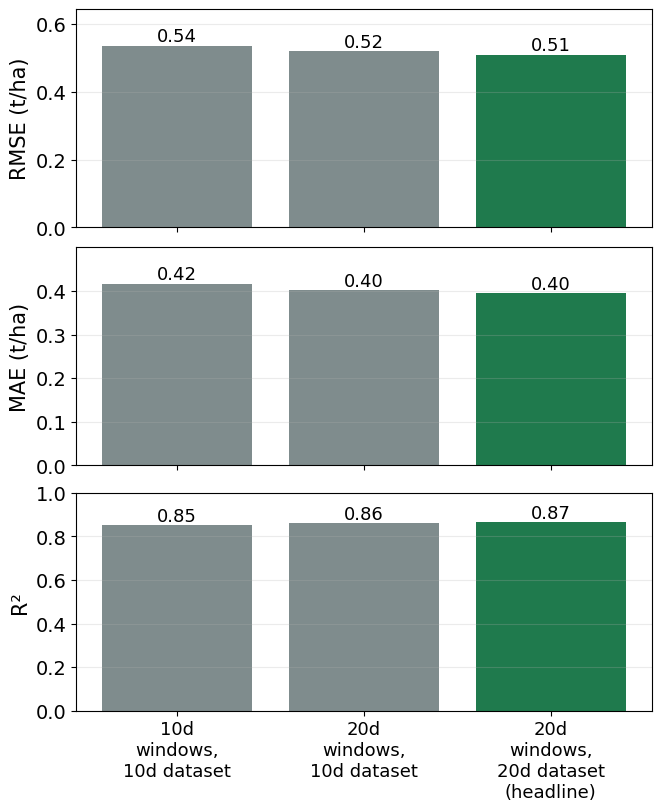

In [24]:
# The 10-day predictions are matched to the 2025 rows of the 20-day table by county id
test_county_ids_10d = features_10d.county_id.to_numpy()[split_10d["is_test_row"]]
test_yields_10d = features_10d["yield"].to_numpy(np.float32)[split_10d["is_test_row"]]
yield_10d_by_county = dict(zip(test_county_ids_10d, test_yields_10d))


def ten_day_prediction_on_test_rows(ten_day_prediction):
    """Place a 10-day prediction on the 2025 rows of the 20-day table (NaN where the 10-day table has no row)."""
    prediction_by_county = dict(zip(test_county_ids_10d, ten_day_prediction))
    return np.array([prediction_by_county.get(c, np.nan) for c in county_id_test], np.float32)


arm_a_prediction = ten_day_prediction_on_test_rows(bank_10d.mean(axis=0))
is_shared_test_county = ~np.isnan(arm_a_prediction)
assert np.array_equal(is_shared_test_county, is_headline_cohort), "shared 2025 counties differ from the headline cohort"
labels_agree = np.allclose([yield_10d_by_county[c] for c in county_id_test[is_shared_test_county]],
                           yield_actual_test[is_shared_test_county])
assert labels_agree, "the two tables carry different 2025 labels"

# arm A, B and C of the text; the figure names carry no letters
ARM_A = "10d windows, 10d dataset"
ARM_B = "20d windows, 10d dataset"
ARM_C = "20d windows, 20d dataset (headline)"
ten_day_arms = {
    ARM_A: (arm_a_prediction, split_10d["is_train_row"].sum()),
    ARM_B: (bank_20d_restricted.mean(axis=0), split_20d_restricted["is_train_row"].sum()),
    ARM_C: (e07_test_ensemble, headline_split["is_train_row"].sum()),
}
ten_day_arm_banks = {
    ARM_A: np.array([ten_day_prediction_on_test_rows(prediction) for prediction in bank_10d]),
    ARM_B: bank_20d_restricted,
    ARM_C: e07_test_bank[:N_MODELS_PER_ENSEMBLE],
}
ten_day_rows = []
for arm_name, (arm_prediction, n_training_rows) in ten_day_arms.items():
    ten_day_rows.append({"arm": arm_name, "training county-years": int(n_training_rows), **test_table_columns(arm_prediction)})
    if arm_name == ARM_C:
        continue                      # arm C is the headline configuration (E7) and is already recorded
    record_in_summary("2.1", f"arm {arm_name}", arm_prediction, models=N_MODELS_TEN_DAY_TRACK,
                      note="exists for the 10-day complete counties only" if arm_name.startswith("A") else "")
    record_single_models("2.1", f"arm {arm_name}", test_bank=ten_day_arm_banks[arm_name],
                         colour=MODEL_COLOURS["variant"])
ten_day_table = pd.DataFrame(ten_day_rows)
ten_day_table.to_csv(os.path.join(experiment_folder("section2_ten_day_track"), "results.csv"), index=False)
display(ten_day_table)

arm_rmses = [headline_rmse(ten_day_arms[arm_name][0]) for arm_name in ten_day_arm_banks]
resolution_effect = (arm_rmses[0] - arm_rmses[1]) / DT_HA_PER_T_HA
label_effect = (arm_rmses[1] - arm_rmses[2]) / DT_HA_PER_T_HA
print(f"resolution effect A - B (positive = the coarser 20-day series is better): {resolution_effect:+.3f} t/ha, "
      f"B against A: {noise_verdict(arm_rmses[1], arm_rmses[0])}")
print(f"label effect      B - C (positive = more training labels help)        : {label_effect:+.3f} t/ha, "
      f"C against B: {noise_verdict(arm_rmses[2], arm_rmses[1])}")

arm_colours = {arm_name: MODEL_COLOURS["variant"] for arm_name in ten_day_arms}
arm_colours[ARM_C] = MODEL_COLOURS["headline transformer"]
# the 10d test set only: arm A has no prediction for the rest of the 20d test set
plot_prediction_bars({arm_name: arm_prediction for arm_name, (arm_prediction, _) in ten_day_arms.items()},
                     arm_colours, "section2_ten_day_track", "10d_against_20d_windows.png",
                     cohorts=("headline",))

### 2.2 E3 — Ensemble size, and the noise between independent ensembles
No training. From the 60 models of the E7 bank, 200 random subsets of size *k* are drawn without
replacement for *k* = 1, 5, 10 and 30 and averaged; *k* = 60 is the single full ensemble. Shown on
the 10-day complete counties, both test sets in the table.

Random subsets of one bank share models, so they understate how much two **independent** 30-model
ensembles differ. The second table therefore lists the three independent 30-model ensembles of the
identical headline configuration that exist: E7 models 0–29, E7 models 30–59 and the headline of `01`.
Their spread is what the 0.01 t/ha threshold of the noise rule is set against.

RMSE and MAE in t/ha


,models,subsets drawn,10-day complete RMSE mean,10-day complete RMSE p5,10-day complete RMSE p95,10-day complete MAE mean,10-day complete MAE p5,10-day complete MAE p95,10-day complete R2 mean,10-day complete R2 p5,10-day complete R2 p95,all counties RMSE mean,all counties RMSE p5,all counties RMSE p95,all counties MAE mean,all counties MAE p5,all counties MAE p95,all counties R2 mean,all counties R2 p5,all counties R2 p95
0,1,200,0.55,0.53,0.57,0.42,0.40,0.45,0.85,0.83,0.86,0.59,0.57,0.61,0.46,0.44,0.48,0.81,0.80,0.82
1,5,200,0.52,0.51,0.53,0.40,0.39,0.41,0.86,0.86,0.87,0.56,0.55,0.57,0.44,0.43,0.45,0.83,0.82,0.83
2,10,200,0.51,0.51,0.52,0.40,0.39,0.40,0.86,0.86,0.87,0.56,0.55,0.56,0.44,0.43,0.44,0.83,0.83,0.83
3,30,200,0.51,0.51,0.51,0.39,0.39,0.40,0.87,0.86,0.87,0.56,0.55,0.56,0.44,0.43,0.44,0.83,0.83,0.83
4,60,1,0.51,0.51,0.51,0.39,0.39,0.39,0.87,0.87,0.87,0.56,0.56,0.56,0.44,0.44,0.44,0.83,0.83,0.83


individual models with a lower RMSE than the full 60-model ensemble, 10-day complete: 0
individual models with a lower RMSE than the full 60-model ensemble, all counties: 0

independent 30-model ensembles of the identical headline configuration:


,independent 30-model ensemble,282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%)
0,E7 models 0-29,0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4
1,E7 models 30-59,0.51,0.39,0.87,12.0,0.56,0.43,0.83,12.4
2,headline of 01,0.51,0.39,0.87,11.9,0.56,0.44,0.83,12.5


spread of their 10-day complete RMSE: 0.003 t/ha (noise rule threshold: 0.01 t/ha)


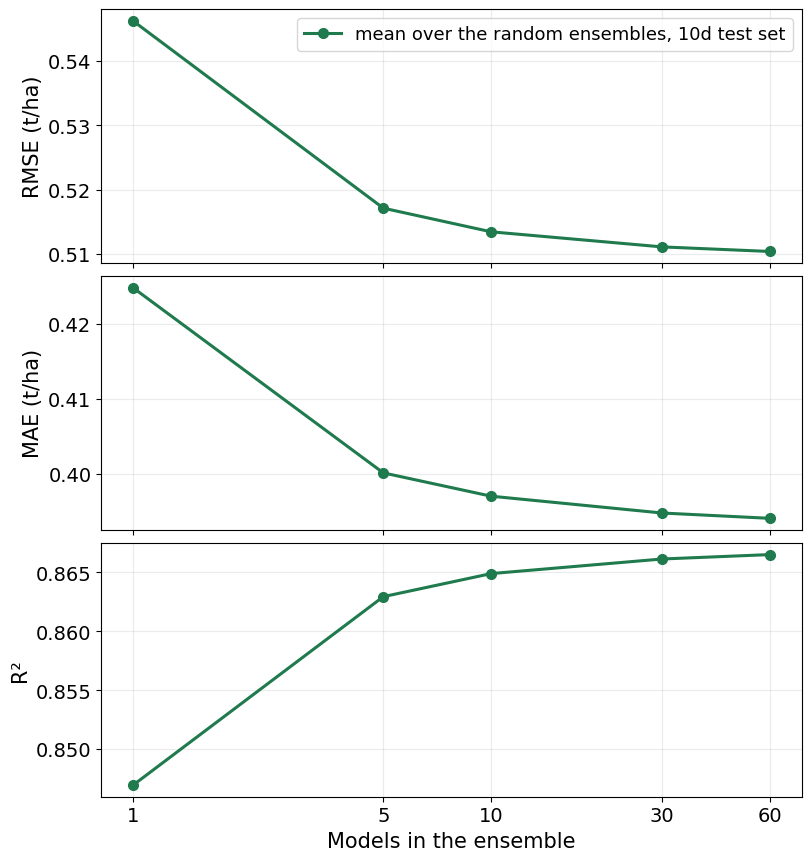

In [25]:
# E3: RMSE, MAE and R2 against ensemble size, from the 60 models of the E7 bank
ENSEMBLE_SIZES = [1, 5, 10, 30, 60]
N_RANDOM_SUBSETS = 200
assert max(ENSEMBLE_SIZES) <= len(e07_test_bank), "the E7 bank has fewer models than the largest ensemble"
COHORT_NAMES = {"headline": "10-day complete", "full": "all counties"}

random_generator = np.random.default_rng(0)
e03_rows = []
subset_metrics_by_size = {}
for ensemble_size in ENSEMBLE_SIZES:
    if ensemble_size == len(e07_test_bank):
        subsets = [np.arange(len(e07_test_bank))]
    else:
        subsets = [random_generator.choice(len(e07_test_bank), size=ensemble_size, replace=False)
                   for _ in range(N_RANDOM_SUBSETS)]
    subset_metrics = [cohort_metrics(e07_test_bank[subset].mean(axis=0)) for subset in subsets]
    subset_metrics_by_size[ensemble_size] = subset_metrics
    row = {"models": ensemble_size, "subsets drawn": len(subsets)}
    for cohort, cohort_name in COHORT_NAMES.items():
        for metric in ["RMSE", "MAE", "R2"]:
            values = [metrics[cohort][metric] for metrics in subset_metrics]
            row[f"{cohort_name} {metric} mean"] = np.mean(values)
            row[f"{cohort_name} {metric} p5"] = np.percentile(values, 5)
            row[f"{cohort_name} {metric} p95"] = np.percentile(values, 95)
    e03_rows.append(row)
e03_table = pd.DataFrame(e03_rows)
e03_table.to_csv(os.path.join(experiment_folder("e03_ensemble_size"), "results.csv"), index=False)
print("RMSE and MAE in t/ha")
display(e03_table.round(2))

full_ensemble_metrics = cohort_metrics(e07_test_bank.mean(axis=0))
single_model_metrics = [cohort_metrics(single_prediction) for single_prediction in e07_test_bank]
for cohort, cohort_name in COHORT_NAMES.items():
    n_better = sum(metrics[cohort]["RMSE"] < full_ensemble_metrics[cohort]["RMSE"] for metrics in single_model_metrics)
    print(f"individual models with a lower RMSE than the full {len(e07_test_bank)}-model ensemble, {cohort_name}: {n_better}")

independent_ensembles = {
    f"E7 models 0-{N_MODELS_PER_ENSEMBLE - 1}": e07_test_ensemble,
    f"E7 models {N_MODELS_PER_ENSEMBLE}-{2 * N_MODELS_PER_ENSEMBLE - 1}": e07_test_bank[N_MODELS_PER_ENSEMBLE:2 * N_MODELS_PER_ENSEMBLE].mean(axis=0),
    "headline of 01": headline_ensemble,
}
independent_ensemble_table = pd.DataFrame([{"independent 30-model ensemble": name, **test_table_columns(prediction)}
                                           for name, prediction in independent_ensembles.items()])
independent_ensemble_table.to_csv(os.path.join(experiment_folder("e03_ensemble_size"), "independent_ensembles.csv"), index=False)
print("\nindependent 30-model ensembles of the identical headline configuration:")
display(independent_ensemble_table)
independent_rmses = [headline_rmse(prediction) for prediction in independent_ensembles.values()]
print(f"spread of their 10-day complete RMSE: {(max(independent_rmses) - min(independent_rmses)) / DT_HA_PER_T_HA:.3f} t/ha "
      f"(noise rule threshold: {NOISE_FLOOR_T_PER_HA:.2f} t/ha)")

figure, axes = plt.subplots(3, 1, figsize=(8.0, 8.5), sharex=True, layout="constrained")
for axis, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    axis.plot(e03_table["models"], e03_table[f"10-day complete {metric} mean"], "-o",
              color=MODEL_COLOURS["headline transformer"], linewidth=2.2, markersize=7,
              label=f"mean over the random ensembles, {TEST_SET_10D}")
    axis.set_xscale("log")
    axis.set_xticks(ENSEMBLE_SIZES)
    axis.set_xticklabels([str(size) for size in ENSEMBLE_SIZES])
    axis.minorticks_off()
    axis.set_ylabel(METRIC_AXIS_LABELS[metric])
    axis.grid(alpha=0.25)
axes[-1].set_xlabel("Models in the ensemble")
axes[0].legend()
save_figure(figure, "e03_ensemble_size", "ensemble_size.png")

#### Single models against ensembles of 5, 10 and 30 models
The headline configuration only, since E7 is the one bank with more than 30 models. One box per ensemble
size and test set: every single model of the 60, and the 200 random ensembles of 5, 10 and 30 models drawn
from the 60 above. The three independent 30-model ensembles are in the table above, not in the figure.
The dashed red line is the ensemble of all 60. The box spans the middle half of the models, the line
inside it is the median, the whiskers reach the most extreme value within 1.5 box lengths and a plus
marks anything beyond them.

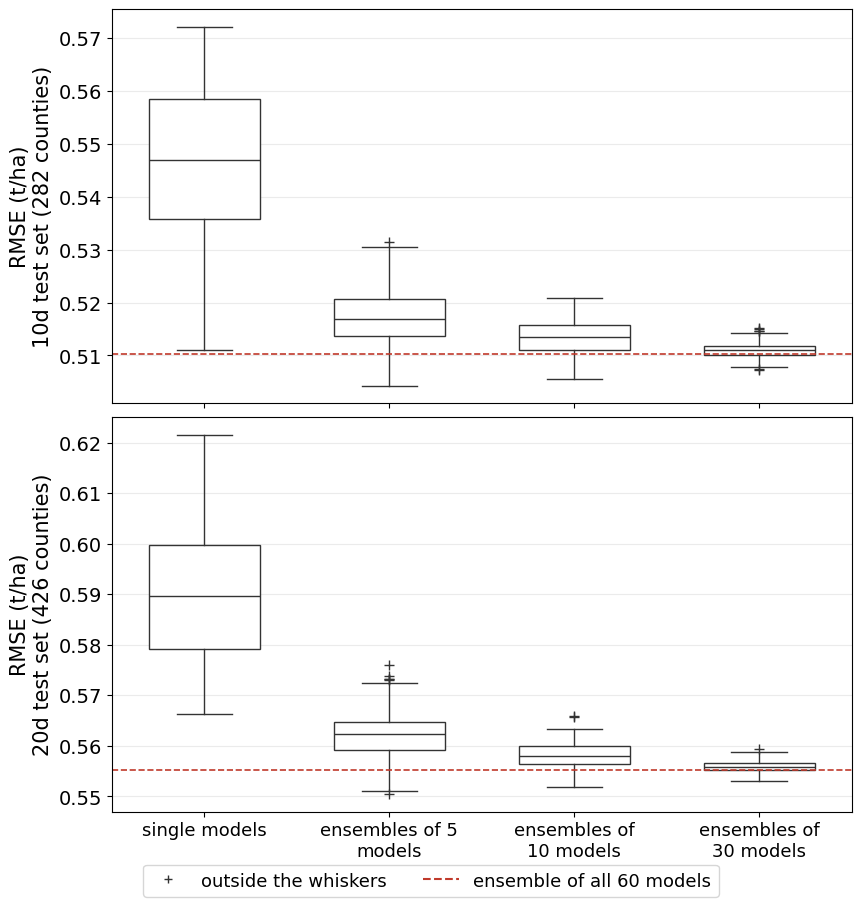

RMSE in t/ha; three decimals only because the ensemble spread lies below 0.01


,test set,row,n,min,median,max,std
0,10d test set (282 counties),single models,60,0.511,0.547,0.572,0.014
1,10d test set (282 counties),ensembles of 5 models,200,0.504,0.517,0.531,0.005
2,10d test set (282 counties),ensembles of 10 models,200,0.506,0.513,0.521,0.003
3,10d test set (282 counties),ensembles of 30 models,200,0.507,0.511,0.515,0.002
4,20d test set (426 counties),single models,60,0.566,0.590,0.621,0.013
5,20d test set (426 counties),ensembles of 5 models,200,0.551,0.562,0.576,0.004
6,20d test set (426 counties),ensembles of 10 models,200,0.552,0.558,0.566,0.003
7,20d test set (426 counties),ensembles of 30 models,200,0.553,0.556,0.559,0.001


In [26]:
# Box plots: single models and random ensembles of 5, 10 and 30 models of the headline configuration
ENSEMBLE_BOX_SUBSET_SIZE = N_MODELS_PER_ENSEMBLE
ENSEMBLE_BOX_SIZES = [5, 10, N_MODELS_PER_ENSEMBLE]
# the counts (60 single models, 200 random ensembles per size) are in the text and the table, not the labels
ensemble_box_rows = ["single models"] + [f"ensembles of {size} models" for size in ENSEMBLE_BOX_SIZES]

ensemble_variance_rows = []
figure, axes = plt.subplots(2, 1, figsize=(8.5, 9.0), sharex=True, layout="constrained")
for axis, (cohort, cohort_label) in zip(axes, [("headline", f"{TEST_SET_10D} ({HEADLINE_LABEL})"),
                                               ("full", f"{TEST_SET_20D} ({FULL_LABEL})")]):
    values_by_row = [[metrics[cohort]["RMSE"] for metrics in single_model_metrics]] + [
        [metrics[cohort]["RMSE"] for metrics in subset_metrics_by_size[size]] for size in ENSEMBLE_BOX_SIZES]
    for position, (row_name, values) in enumerate(zip(ensemble_box_rows, values_by_row)):
        ensemble_variance_rows.append({"test set": cohort_label, "row": row_name, "n": len(values),
                                       "min": round(float(np.min(values)), 3), "median": round(float(np.median(values)), 3),
                                       "max": round(float(np.max(values)), 3), "std": round(float(np.std(values)), 3)})
        axis.boxplot(values, positions=[position], widths=0.6, showfliers=True,
                     patch_artist=True, boxprops={"facecolor": "white", "edgecolor": "#333333"},
                     medianprops={"color": "#333333"}, whiskerprops={"color": "#333333"},
                     capprops={"color": "#333333"},
                     flierprops={"marker": "+", "markersize": 7, "markeredgecolor": "#333333"})
    axis.axhline(full_ensemble_metrics[cohort]["RMSE"], color="#c0392b", linestyle="--", linewidth=1.2)
    axis.set_ylabel(f"RMSE (t/ha)\n{cohort_label}")
    axis.grid(axis="y", alpha=0.25)
axes[-1].set_xticks(range(len(ensemble_box_rows)))
axes[-1].set_xticklabels([wrap_label(row, 14) for row in ensemble_box_rows], fontsize=CATEGORY_FONT_SIZE)
legend_handles = [plt.Line2D([], [], marker="+", linestyle="none", color="#333333", label="outside the whiskers"),
                  plt.Line2D([], [], linestyle="--", color="#c0392b", label=f"ensemble of all {len(e07_test_bank)} models")]
figure.legend(handles=legend_handles, ncol=2, loc="outside lower center")
save_figure(figure, "e03_ensemble_size", "single_models_against_ensembles.png")

ensemble_variance_table = pd.DataFrame(ensemble_variance_rows)
ensemble_variance_table.to_csv(os.path.join(experiment_folder("e03_ensemble_size"), "single_models_against_ensembles.csv"), index=False)
print("RMSE in t/ha; three decimals only because the ensemble spread lies below 0.01")
display(ensemble_variance_table)

### 2.3 E4 — Larger and deeper variants, and E21 — one model 60 times as large
**E4.** Everything identical to the headline except width (half or double the headline width, one
encoder layer) or depth (2 or 3 encoder layers at the headline width). Half the headline width is the
width-128 configuration the design started from. Feed forward width stays 2 × width, heads stay 4,
register tokens stay 18. 30 models per configuration, against E7. The configuration is chosen on the
2023 validation season; the verdict column applies the noise rule on 2025.

**E21.** One model with about 60 times the parameters of the headline, reached by widening the single
encoder layer. Five such models are trained. An ensemble of them would mix size with averaging again, so
the figure shows one single model: model 2, chosen by the author after seeing all five (the table lists
every one; model 2 lies near the middle of the five on 2025 and is not the best of them).

In [27]:
# E4: four configurations, 30 models each
N_MODELS_E04 = N_MODELS_PER_ENSEMBLE
# named as in the table of the thesis (variants 1 to 4)
E04_CONFIGURATIONS = {
    f"Variant 1: width {D // 2}, 1 layer": dict(width=D // 2, n_encoder_layers=1),
    f"Variant 2: width {2 * D}, 1 layer": dict(width=2 * D, n_encoder_layers=1),
    f"Variant 3: width {D}, 2 layers": dict(width=D, n_encoder_layers=2),
    f"Variant 4: width {D}, 3 layers": dict(width=D, n_encoder_layers=3),
}

e04_banks = {}
for configuration_name, configuration in E04_CONFIGURATIONS.items():
    folder_name = f"e04_width{configuration['width']}_layers{configuration['n_encoder_layers']}"
    e04_banks[configuration_name] = load_or_train_bank(
        folder_name, N_MODELS_E04,
        lambda seed: train_neural_model(
            build_model=lambda: ConfigurableYieldPredictor(lean_tokens_headline.shape[2],
                                                           configuration["width"],
                                                           configuration["n_encoder_layers"]),
            input_arrays=[lean_tokens_headline, history_headline, coverage_headline],
            split=headline_split, seed=seed))
    print(f"{configuration_name}: ready", flush=True)

Variant 1: width 128, 1 layer: ready


Variant 2: width 512, 1 layer: ready


Variant 3: width 256, 2 layers: ready


Variant 4: width 256, 3 layers: ready


In [28]:
# E21: widen the headline until it has about 60 times the parameters, then train single models
N_MODELS_E21 = 5                 # independent single models, never averaged
E21_PRESENTED_MODEL = 2           # the one in the figure, chosen by the author (see the markdown above)
E21_TARGET_SIZE_FACTOR = 60


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters())


headline_parameter_count = count_parameters(YIELD_PREDICTOR(lean_tokens_headline.shape[2]))
# widen in steps of 32, which keeps the width divisible by the 4 attention heads
e21_width = D
e21_size_factor = 1.0
while e21_size_factor < E21_TARGET_SIZE_FACTOR:
    previous_width = e21_width
    previous_size_factor = e21_size_factor
    e21_width = e21_width + 32
    e21_size_factor = count_parameters(ConfigurableYieldPredictor(lean_tokens_headline.shape[2], e21_width, 1)) / headline_parameter_count
if abs(previous_size_factor - E21_TARGET_SIZE_FACTOR) < abs(e21_size_factor - E21_TARGET_SIZE_FACTOR):
    e21_width = previous_width
    e21_size_factor = previous_size_factor
print(f"headline: {headline_parameter_count:,} parameters | E21: width {e21_width}, one encoder layer, "
      f"{e21_size_factor:.1f} times as many parameters")

e21_validation_bank, e21_test_bank = load_or_train_bank(
    f"e21_single_model_width{e21_width}", N_MODELS_E21,
    lambda seed: train_neural_model(
        build_model=lambda: ConfigurableYieldPredictor(lean_tokens_headline.shape[2], e21_width, 1),
        input_arrays=[lean_tokens_headline, history_headline, coverage_headline],
        split=headline_split, seed=seed))

headline: 936,707 parameters | E21: width 2016, one encoder layer, 60.9 times as many parameters


,configuration,parameters,models,validation 2023 RMSE (t/ha),282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%),against the headline
0,"Headline: width 256, 1 layer",936707,30,0.66,0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4,reference
1,"Variant 1: width 128, 1 layer",238979,30,0.68,0.51,0.39,0.87,12.0,0.56,0.44,0.83,12.4,within noise (+0.001)
2,"Variant 2: width 512, 1 layer",3708419,30,0.65,0.51,0.40,0.86,12.0,0.56,0.44,0.83,12.4,within noise (+0.004)
3,"Variant 3: width 256, 2 layers",1463811,30,0.66,0.52,0.40,0.86,12.1,0.56,0.44,0.83,12.5,within noise (+0.007)
4,"Variant 4: width 256, 3 layers",1990915,30,0.67,0.52,0.40,0.86,12.2,0.56,0.44,0.83,12.5,higher RMSE (+0.010)
5,E21 single model 0,57050787,1,0.68,0.54,0.42,0.85,12.6,0.57,0.44,0.82,12.8,higher RMSE (+0.030)
6,E21 single model 1,57050787,1,0.66,0.54,0.42,0.85,12.6,0.57,0.45,0.82,12.8,higher RMSE (+0.029)
7,E21 single model 2 (in the figure),57050787,1,0.68,0.52,0.41,0.86,12.3,0.60,0.46,0.81,13.3,higher RMSE (+0.014)
8,E21 single model 3,57050787,1,0.75,0.56,0.44,0.84,13.1,0.62,0.49,0.79,13.9,higher RMSE (+0.050)
9,E21 single model 4,57050787,1,0.68,0.51,0.41,0.87,11.9,0.57,0.45,0.82,12.7,within noise (+0.001)


best configuration on the 2023 validation season: Variant 2: width 512, 1 layer


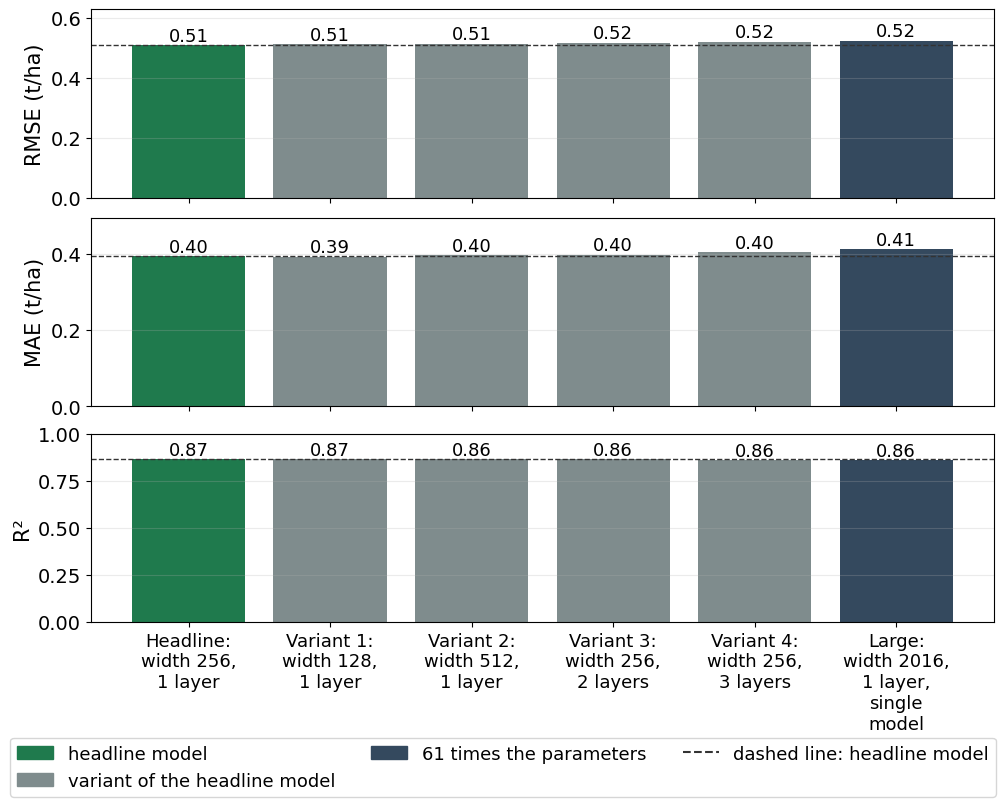

In [29]:
# E4 and E21 results: E4 ensembles and one large single model (E21) against E7; all five E21 models in the table
e04_rows = []
e04_predictions = {}
e04_colours = {}

reference_name = f"Headline: width {D}, 1 layer"
e04_predictions[reference_name] = e07_test_ensemble
e04_colours[reference_name] = MODEL_COLOURS["headline transformer"]
e04_rows.append({"configuration": reference_name, "parameters": headline_parameter_count, "models": N_MODELS_PER_ENSEMBLE,
                 "validation 2023 RMSE (t/ha)": validation_rmse_t_per_ha(e07_validation_ensemble),
                 **test_table_columns(e07_test_ensemble), "against the headline": "reference"})
for configuration_name, (validation_bank, test_bank) in e04_banks.items():
    configuration = E04_CONFIGURATIONS[configuration_name]
    test_prediction = test_bank.mean(axis=0)
    e04_predictions[configuration_name] = test_prediction
    e04_colours[configuration_name] = MODEL_COLOURS["variant"]
    parameters = count_parameters(ConfigurableYieldPredictor(lean_tokens_headline.shape[2], configuration["width"], configuration["n_encoder_layers"]))
    e04_rows.append({"configuration": configuration_name, "parameters": parameters, "models": N_MODELS_E04,
                     "validation 2023 RMSE (t/ha)": validation_rmse_t_per_ha(validation_bank.mean(axis=0)),
                     **test_table_columns(test_prediction),
                     "against the headline": noise_verdict(headline_rmse(test_prediction), headline_rmse(e07_test_ensemble))})
    record_in_summary("2.3", f"E4 {configuration_name}", test_prediction, models=N_MODELS_E04)
    record_single_models("2.3", f"E4 {configuration_name}", test_bank=test_bank)

# E21: every large model on its own; the figure shows the presented one
e21_parameter_count = count_parameters(ConfigurableYieldPredictor(lean_tokens_headline.shape[2], e21_width, 1))
e21_name = f"Large: width {e21_width}, 1 layer, single model"
for model_number in range(N_MODELS_E21):
    e04_rows.append({"configuration": f"E21 single model {model_number}" + (" (in the figure)" if model_number == E21_PRESENTED_MODEL else ""),
                     "parameters": e21_parameter_count, "models": 1,
                     "validation 2023 RMSE (t/ha)": validation_rmse_t_per_ha(e21_validation_bank[model_number]),
                     **test_table_columns(e21_test_bank[model_number]),
                     "against the headline": noise_verdict(headline_rmse(e21_test_bank[model_number]), headline_rmse(e07_test_ensemble))})
e21_presented_prediction = e21_test_bank[E21_PRESENTED_MODEL]
e04_predictions[e21_name] = e21_presented_prediction
e04_colours[e21_name] = MODEL_COLOURS["large single model"]
record_in_summary("2.3", f"E21 {e21_size_factor:.0f}x parameters, single model {E21_PRESENTED_MODEL}", e21_presented_prediction,
                  models=1, note="chosen by the author from five")


def single_model_summary(test_bank):
    """Metrics of single models scored one by one: their mean and their (lowest, highest) value,
    both shaped {"headline": {...}, "full": {...}}."""
    per_model = [cohort_metrics(prediction) for prediction in test_bank]
    mean_metrics = {}
    metric_ranges = {}
    for cohort in ["headline", "full"]:
        mean_metrics[cohort] = {}
        metric_ranges[cohort] = {}
        for metric in ["RMSE", "MAE", "R2"]:
            values = [metrics[cohort][metric] for metrics in per_model]
            mean_metrics[cohort][metric] = float(np.mean(values))
            metric_ranges[cohort][metric] = (float(np.min(values)), float(np.max(values)))
    return mean_metrics, metric_ranges


# for the table only: the models of E21 and five headline-size models scored one by one
for display_name, validation_bank, test_bank, parameters, colour in [
        (f"single model, headline size (mean of {N_MODELS_E21})", e07_validation_bank[:N_MODELS_E21], e07_test_bank[:N_MODELS_E21],
         headline_parameter_count, MODEL_COLOURS["headline transformer"]),
        (f"single model, {e21_size_factor:.0f}x parameters (mean of {N_MODELS_E21})", e21_validation_bank, e21_test_bank,
         e21_parameter_count, MODEL_COLOURS["large single model"])]:
    mean_metrics, metric_ranges = single_model_summary(test_bank)
    row = {"configuration": display_name, "parameters": parameters, "models": f"{len(test_bank)} single",
           "validation 2023 RMSE (t/ha)": round(float(np.mean([rmse(prediction, yield_actual_validation)
                                                              for prediction in validation_bank])) / DT_HA_PER_T_HA, 2)}
    for cohort, cohort_label in [("headline", HEADLINE_LABEL), ("full", FULL_LABEL)]:
        row[f"{cohort_label} RMSE (t/ha)"] = round(mean_metrics[cohort]["RMSE"], 2)
        row[f"{cohort_label} MAE (t/ha)"] = round(mean_metrics[cohort]["MAE"], 2)
        row[f"{cohort_label} R2"] = round(mean_metrics[cohort]["R2"], 2)
    e04_rows.append(row)

record_single_models("2.3", f"E21 single model, {e21_size_factor:.0f}x parameters ({N_MODELS_E21} models)", test_bank=e21_test_bank,
                     colour=MODEL_COLOURS["large single model"])

e04_table = pd.DataFrame(e04_rows)
e04_table.to_csv(os.path.join(experiment_folder("e04_larger_deeper"), "results.csv"), index=False)
display(e04_table)
ensemble_rows = e04_table.iloc[:1 + len(E04_CONFIGURATIONS)]
best_on_validation = ensemble_rows.loc[ensemble_rows["validation 2023 RMSE (t/ha)"].idxmin(), "configuration"]
print(f"best configuration on the 2023 validation season: {best_on_validation}")

plot_prediction_bars(e04_predictions, e04_colours, "e04_larger_deeper", "larger_and_deeper.png",
                     cohorts=("headline",), reference_name=reference_name,
                     colour_legend=[("headline model", MODEL_COLOURS["headline transformer"]),
                                    ("variant of the headline model", MODEL_COLOURS["variant"]),
                                    (f"{e21_size_factor:.0f} times the parameters", MODEL_COLOURS["large single model"])],
                     reference_legend_label="headline model")

### 2.4 E19 — The prediction target
Three targets, identical in every other respect and all with the historic yield as an input:

Arms A and B scale their target to mean 0 and standard deviation 1 with the statistics of the training
rows and convert the prediction back afterwards; arm C trains on the yield as it is:

| arm | figure name | target | prediction |
|---|---|---|---|
| A (E7) | headline model | the deviation from the historical yield, scaled | the history is added back |
| B | scaled yield | the yield, scaled | nothing is added back |
| C | absolute yield | the yield in dt/ha, unscaled | nothing is added back |

30 models per arm. The validation RMSE is reported next to the test season, since the target also
decides what early stopping optimizes. E12b cannot answer this question, because it changes the target
and removes the history input at the same time.

In [30]:
# E19 arms B and C: the yield as the target, standardized and unstandardized
N_MODELS_E19 = N_MODELS_PER_ENSEMBLE

e19_validation_bank, e19_test_bank = load_or_train_bank(
    f"e19_raw_yield_target_{HEADLINE_WIDTH_TAG}", N_MODELS_E19,
    lambda seed: train_headline_model(lean_tokens_headline, coverage_headline, headline_split, seed,
                                      target_kind="raw_yield"))
e19_validation_ensemble = e19_validation_bank.mean(axis=0)
e19_test_ensemble = e19_test_bank.mean(axis=0)

e19b_validation_bank, e19b_test_bank = load_or_train_bank(
    f"e19b_raw_yield_unstandardized_{HEADLINE_WIDTH_TAG}", N_MODELS_E19,
    lambda seed: train_headline_model(lean_tokens_headline, coverage_headline, headline_split, seed,
                                      target_kind="raw_yield_unstandardized"))
e19b_validation_ensemble = e19b_validation_bank.mean(axis=0)
e19b_test_ensemble = e19b_test_bank.mean(axis=0)

,arm,validation 2023 RMSE (t/ha),282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%)
0,headline model,0.66,0.51,0.4,0.87,11.9,0.56,0.44,0.83,12.4
1,scaled yield,0.66,0.52,0.4,0.86,12.1,0.56,0.44,0.83,12.4
2,absolute yield,0.65,0.51,0.4,0.86,12.0,0.56,0.44,0.83,12.4


standardized yield against the deviation: within noise (+0.006)
unstandardized yield against the deviation: within noise (+0.003)
Note: E12b cannot answer this question; it changes the target and removes the history input at once.


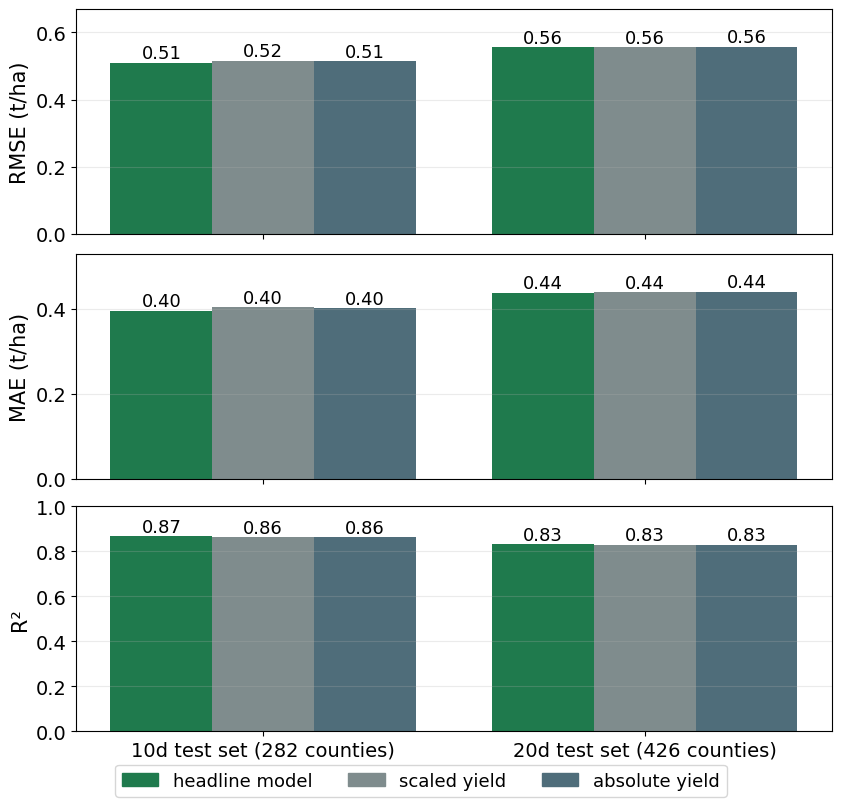

In [31]:
# E19 results
# the headline predicts the deviation from the historical yield; the other two predict the yield, once
# scaled to mean 0 and standard deviation 1 with the training statistics and once in dt/ha as it is
e19_arms = {"headline model": (e07_validation_ensemble, e07_test_ensemble, MODEL_COLOURS["headline transformer"]),
            "scaled yield": (e19_validation_ensemble, e19_test_ensemble, MODEL_COLOURS["variant"]),
            "absolute yield": (e19b_validation_ensemble, e19b_test_ensemble, MODEL_COLOURS["second variant"])}
e19_table = pd.DataFrame([{
    "arm": arm_name,
    "validation 2023 RMSE (t/ha)": validation_rmse_t_per_ha(validation_prediction),
    **test_table_columns(test_prediction),
} for arm_name, (validation_prediction, test_prediction, _) in e19_arms.items()])
e19_table.to_csv(os.path.join(experiment_folder("e19_raw_yield_target"), "results.csv"), index=False)
display(e19_table)
print(f"standardized yield against the deviation: {noise_verdict(headline_rmse(e19_test_ensemble), headline_rmse(e07_test_ensemble))}")
print(f"unstandardized yield against the deviation: {noise_verdict(headline_rmse(e19b_test_ensemble), headline_rmse(e07_test_ensemble))}")
print("Note: E12b cannot answer this question; it changes the target and removes the history input at once.")
record_in_summary("2.4", "E19 standardized yield as target", e19_test_ensemble, models=N_MODELS_E19)
record_single_models("2.4", "E19 standardized yield as target", test_bank=e19_test_bank)
record_in_summary("2.4", "E19 unstandardized yield as target", e19b_test_ensemble, models=N_MODELS_E19)
record_single_models("2.4", "E19 unstandardized yield as target", test_bank=e19b_test_bank)

plot_bars_by_test_set({name: values[1] for name, values in e19_arms.items()},
                      {name: values[2] for name, values in e19_arms.items()},
                      "e19_raw_yield_target", "prediction_target.png")

### Reading, section 2
- **10d and 20d windows (2.1).** With the same model, the same features and the coverage of its own
  windows, arm A reaches 0.54, arm B 0.52 and arm C 0.51. The resolution effect is +0.016 and counts as
  real: the twenty-day windows are **better**, not merely equal, on identical county-years. The label
  effect is +0.0098, just below the threshold, so the extra county-years of the twenty-day table add nothing
  measurable.
- **Ensemble size and noise (2.2).** Single models range from 0.51 to 0.57 with a median of 0.55, and none
  of the 60 beats their own ensemble. Thirty models bring the spread down to 0.51 to 0.52, and the three
  independent 30-model ensembles all land on 0.51, a spread of 0.00 after rounding. That is the evidence
  behind the 0.01 threshold.
- **Larger and deeper (2.3, E4).** On the validation season width 512 is best (0.65) ahead of width 256 and two
  layers (0.66), width 128 and three layers (0.67 and 0.68). On 2025 every configuration is within noise of the
  headline except three layers, which is slightly worse (+0.010), so the capacity of the network does not
  decide the result.
- **One model 60 times as large (2.3, E21).** The five single models of width 2016 (61 times the parameters)
  reach 0.511 to 0.560, 0.535 on average; the figure shows model 2 with 0.524. Five single headline-size
  models average 0.548. A large single model is therefore at best slightly better than a small one, and the
  30-model ensemble of small models (0.510) is better than all but the luckiest of the large ones: the gain of
  the ensemble comes from averaging, not from size.
- **Prediction target (2.4).** All three targets land within noise of each other, on the validation season
  (0.66, 0.66, 0.65) and on 2025 (0.51, 0.52, 0.51). The deviation from the historical yield is a reasonable
  default but is not measurably better than predicting the yield itself, scaled or absolute.

## 3. Different ML methodologies

### 3.1 E7 — The Transformer next to the headline
E7 retrains the headline configuration (section 0), seeded and with validation predictions. Its
30-model reference ensemble and the headline of `01` are independent ensembles of the identical
configuration, so they must agree within noise.

In [32]:
# E7 against the headline of 01
e07_table = pd.DataFrame([
    {"ensemble": "headline of 01 (unseeded, test only)", "validation 2023 RMSE (t/ha)": np.nan, **test_table_columns(headline_ensemble)},
    {"ensemble": f"E7 models 0-{N_MODELS_PER_ENSEMBLE - 1} (seeded)", "validation 2023 RMSE (t/ha)": validation_rmse_t_per_ha(e07_validation_ensemble),
     **test_table_columns(e07_test_ensemble)},
])
e07_table.to_csv(os.path.join(experiment_folder(f"e07_transformer_bank_{HEADLINE_WIDTH_TAG}"), "results.csv"), index=False)
display(e07_table)
print(f"headline of 01 against E7: {noise_verdict(headline_rmse(headline_ensemble), headline_rmse(e07_test_ensemble))} "
      f"(expected: within noise, same configuration)")
record_in_summary("3.1", "E7 transformer (headline configuration, seeded)", e07_test_ensemble,
                  models=N_MODELS_PER_ENSEMBLE, note="reference for sections 2-4")
record_single_models("3.1", "headline configuration (2025: E7, LOYO: E1)", test_bank=e07_test_bank[:N_MODELS_PER_ENSEMBLE],
                     colour=MODEL_COLOURS["headline transformer"])

,ensemble,validation 2023 RMSE (t/ha),282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%)
0,"headline of 01 (unseeded, test only)",NaN,0.51,0.39,0.87,11.9,0.56,0.44,0.83,12.5
1,E7 models 0-29 (seeded),0.66,0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4


headline of 01 against E7: within noise (-0.002) (expected: within noise, same configuration)


### 3.2 E8 — Random forest
Inputs are the flattened lean tokens (7 × 27), the 7 coverage ratios and the historic yield, 197
values, unscaled because trees do not need it. Missing coverage and history are filled with the
training median. The target is the raw anomaly (yield minus history), and the history is added back
to predict. A small grid over `n_estimators`, `max_features`, `max_depth` and `min_samples_leaf` is
searched on the validation season; the chosen forest (trained on the training rows only) predicts
the test season. A forest is already an ensemble and fully determined by its `random_state`, so it is
trained once. Leave one year out (3.5) keeps the settings chosen here for every fold.

In [33]:
# Random forest: grid search on the validation season of a split, then one forest predicts its test rows
RANDOM_FOREST_RANDOM_STATE = 0
RANDOM_FOREST_SEARCH_GRID = {
    "n_estimators": [300, 800],
    "max_features": ["sqrt", 0.33, 1.0],
    "max_depth": [None, 16],
    "min_samples_leaf": [1, 5],
}


def tree_inputs(raw_tokens, split):
    """Flattened raw tokens, raw coverage ratio and history, with missing coverage filled by the
    training median of the split. No scaling."""
    coverage_filled = coverage_ratio_raw.copy()
    for window in range(coverage_filled.shape[1]):
        window_values = coverage_filled[:, window]
        training_median = np.nanmedian(window_values[split["is_train_row"]])
        coverage_filled[:, window] = np.where(np.isnan(window_values), training_median, window_values)
    flattened_tokens = raw_tokens.reshape(len(raw_tokens), -1)
    return np.concatenate([flattened_tokens, coverage_filled, split["yield_history"][:, None]], axis=1)


def fit_random_forest_on_split(split, folder_name):
    """Grid search on the split's validation season; the chosen forest predicts validation and test rows.
    Cached in folder_name (predictions.npz, search_results.csv). Returns dict(validation, test, search)."""
    folder = experiment_folder(folder_name)
    predictions_file = os.path.join(folder, "predictions.npz")
    search_file = os.path.join(folder, "search_results.csv")
    if os.path.exists(predictions_file) and os.path.exists(search_file):
        with np.load(predictions_file) as cached_predictions:
            return dict(validation=cached_predictions["validation"], test=cached_predictions["test"],
                        search=pd.read_csv(search_file, keep_default_na=False))   # keeps max_depth "None" as text

    forest_inputs = tree_inputs(lean_tokens_raw, split)
    anomaly_target = split["yield_actual"] - split["yield_history"]
    is_train_row = split["is_train_row"]
    is_val_row = split["is_val_row"]
    actual_validation = split["yield_actual"][is_val_row]

    search_rows = []
    best_validation_rmse = np.inf
    best_forest = None
    best_validation_prediction = None
    for n_estimators, max_features, max_depth, min_samples_leaf in itertools.product(*RANDOM_FOREST_SEARCH_GRID.values()):
        forest = RandomForestRegressor(n_estimators=n_estimators, max_features=max_features,
                                       max_depth=max_depth, min_samples_leaf=min_samples_leaf,
                                       random_state=RANDOM_FOREST_RANDOM_STATE, n_jobs=-1)
        forest.fit(forest_inputs[is_train_row], anomaly_target[is_train_row])
        validation_prediction = forest.predict(forest_inputs[is_val_row]) + split["yield_history"][is_val_row]
        validation_rmse = rmse(validation_prediction, actual_validation)
        search_rows.append({"n_estimators": n_estimators, "max_features": str(max_features),
                            "max_depth": str(max_depth), "min_samples_leaf": min_samples_leaf,
                            "validation RMSE (t/ha)": validation_rmse / DT_HA_PER_T_HA})
        if validation_rmse < best_validation_rmse:
            best_validation_rmse = validation_rmse
            best_forest = forest
            best_validation_prediction = validation_prediction
    # only the forest chosen on the validation season ever predicts the test season
    test_prediction = best_forest.predict(forest_inputs[split["is_test_row"]]) + split["yield_history"][split["is_test_row"]]
    search_table = pd.DataFrame(search_rows)
    search_table["chosen"] = search_table["validation RMSE (t/ha)"] == best_validation_rmse / DT_HA_PER_T_HA
    search_table.to_csv(search_file, index=False)
    np.savez(predictions_file, validation=best_validation_prediction, test=test_prediction)
    return dict(validation=best_validation_prediction, test=test_prediction, search=search_table)


e08_forest = fit_random_forest_on_split(headline_split, "e08_random_forest")
e08_validation_prediction = e08_forest["validation"]
e08_test_prediction = e08_forest["test"]
print(f"random forest inputs: {tree_inputs(lean_tokens_raw, headline_split).shape[1]} values per county-year")

random forest inputs: 197 values per county-year


,n_estimators,max_features,max_depth,min_samples_leaf,validation RMSE (t/ha),chosen
0,300,sqrt,None,1,0.818,True
1,300,sqrt,None,5,0.819,False
2,300,sqrt,16,1,0.827,False
3,300,sqrt,16,5,0.823,False
4,300,0.33,None,1,0.829,False
5,300,0.33,None,5,0.824,False
6,300,0.33,16,1,0.829,False
7,300,0.33,16,5,0.826,False
8,300,1.0,None,1,0.833,False
9,300,1.0,None,5,0.834,False


chosen on 2023: n_estimators=300, max_features=sqrt, max_depth=None, min_samples_leaf=1, random_state=0


,model,validation 2023 RMSE (t/ha),282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%),against the transformer (E7)
0,random forest (E8),0.82,0.61,0.48,0.81,14.2,0.61,0.48,0.79,13.7,higher RMSE (+0.095)


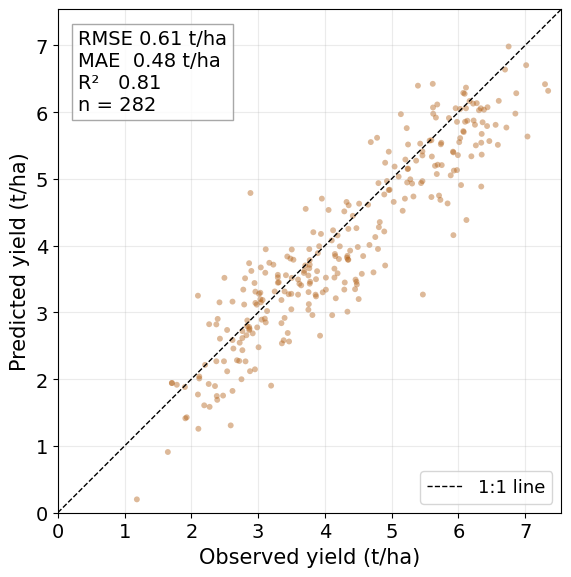

In [34]:
# E8 results
display(e08_forest["search"].round(3))
e08_chosen = e08_forest["search"][e08_forest["search"]["chosen"]].iloc[0]
print(f"chosen on 2023: n_estimators={e08_chosen['n_estimators']}, max_features={e08_chosen['max_features']}, "
      f"max_depth={e08_chosen['max_depth']}, min_samples_leaf={e08_chosen['min_samples_leaf']}, "
      f"random_state={RANDOM_FOREST_RANDOM_STATE}")
e08_table = pd.DataFrame([{
    "model": "random forest (E8)",
    "validation 2023 RMSE (t/ha)": validation_rmse_t_per_ha(e08_validation_prediction),
    **test_table_columns(e08_test_prediction),
    "against the transformer (E7)": noise_verdict(headline_rmse(e08_test_prediction), headline_rmse(e07_test_ensemble)),
}])
e08_table.to_csv(os.path.join(experiment_folder("e08_random_forest"), "results.csv"), index=False)
display(e08_table)
record_in_summary("3.2", "E8 random forest", e08_test_prediction, models="1 forest")
plot_parity(yield_actual_test[is_headline_cohort], e08_test_prediction[is_headline_cohort],
            MODEL_COLOURS["random forest"], "e08_random_forest", "random_forest_parity_10d_test_set.png")

### 3.3 E9 — Multilayer perceptron
The same 197 inputs as the forest, scaled as for the transformer (tokens standardized as in `01`,
coverage per window, history unscaled), with the full transformer protocol including noise on the
token part only. Depth and width are checked lightly on the validation season with 10 models per
configuration; the chosen configuration is then extended to 30 models. Leave one year out (3.5) keeps
the configuration chosen here for every fold.

In [35]:
# MLP: configuration check on the validation season of a split, then the chosen configuration is extended
N_MODELS_E09_CHECK = 10
N_MODELS_E09 = N_MODELS_PER_ENSEMBLE
MLP_CONFIGURATIONS = [dict(n_hidden_layers=2, hidden_width=128),     # default
                      dict(n_hidden_layers=1, hidden_width=128),
                      dict(n_hidden_layers=3, hidden_width=128),
                      dict(n_hidden_layers=2, hidden_width=64),
                      dict(n_hidden_layers=2, hidden_width=256)]


def mlp_folder_name(folder_prefix, configuration):
    return f"{folder_prefix}_{configuration['n_hidden_layers']}x{configuration['hidden_width']}"


def train_mlp(configuration, tokens, coverage, split, seed):
    """One WindowMLP with the transformer protocol and inputs."""
    return train_neural_model(
        build_model=lambda: WindowMLP(tokens.shape[1], tokens.shape[2],
                                      configuration["hidden_width"], configuration["n_hidden_layers"]),
        input_arrays=[tokens, split["yield_history"][:, None], coverage],
        split=split, seed=seed)


def select_and_train_mlp(tokens, coverage, split, folder_prefix, n_models):
    """Check every configuration with N_MODELS_E09_CHECK models on the split's validation season, then
    extend the chosen one to n_models (its check models are reused). Returns
    (chosen configuration, check table, validation bank, test bank)."""
    check_rows = []
    actual_validation = split["yield_actual"][split["is_val_row"]]
    for configuration in MLP_CONFIGURATIONS:
        validation_bank, _ = load_or_train_bank(mlp_folder_name(folder_prefix, configuration), N_MODELS_E09_CHECK,
                                                lambda seed: train_mlp(configuration, tokens, coverage, split, seed))
        check_rows.append({**configuration, "models": N_MODELS_E09_CHECK,
                           "validation RMSE (t/ha)": rmse(validation_bank.mean(axis=0), actual_validation) / DT_HA_PER_T_HA})
    check_table = pd.DataFrame(check_rows)
    chosen_configuration = MLP_CONFIGURATIONS[int(check_table["validation RMSE (t/ha)"].idxmin())]
    validation_bank, test_bank = load_or_train_bank(mlp_folder_name(folder_prefix, chosen_configuration), n_models,
                                                    lambda seed: train_mlp(chosen_configuration, tokens, coverage, split, seed))
    return chosen_configuration, check_table, validation_bank, test_bank


e09_chosen_configuration, e09_check_table, e09_validation_bank, e09_test_bank = select_and_train_mlp(
    lean_tokens_headline, coverage_headline, headline_split, "e09_mlp", N_MODELS_E09)
e09_validation_ensemble = e09_validation_bank.mean(axis=0)
e09_test_ensemble = e09_test_bank.mean(axis=0)

In [36]:
# E9 results
display(e09_check_table.round(3))
chosen_label = f"{e09_chosen_configuration['n_hidden_layers']} x {e09_chosen_configuration['hidden_width']}"
print(f"chosen on 2023: {chosen_label} (hidden layers x width), GELU, dropout 0.1, {N_MODELS_E09} models")
e09_table = pd.DataFrame([{
    "model": f"MLP {chosen_label} (E9)",
    "validation 2023 RMSE (t/ha)": validation_rmse_t_per_ha(e09_validation_ensemble),
    **test_table_columns(e09_test_ensemble),
    "against the transformer (E7)": noise_verdict(headline_rmse(e09_test_ensemble), headline_rmse(e07_test_ensemble)),
}])
e09_check_table.to_csv(os.path.join(experiment_folder("e09_mlp"), "configuration_check.csv"), index=False)
e09_table.to_csv(os.path.join(experiment_folder("e09_mlp"), "results.csv"), index=False)
display(e09_table)
record_in_summary("3.3", "E9 MLP", e09_test_ensemble, models=N_MODELS_E09, note=chosen_label)
record_single_models("3.3", "MLP (2025: E9, LOYO: E23)", test_bank=e09_test_bank[:N_MODELS_E09], colour=MODEL_COLOURS["MLP"])

,n_hidden_layers,hidden_width,models,validation RMSE (t/ha)
0,2,128,10,0.749
1,1,128,10,0.742
2,3,128,10,0.745
3,2,64,10,0.759
4,2,256,10,0.740


chosen on 2023: 2 x 256 (hidden layers x width), GELU, dropout 0.1, 30 models


,model,validation 2023 RMSE (t/ha),282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%),against the transformer (E7)
0,MLP 2 x 256 (E9),0.74,0.59,0.46,0.82,13.9,0.61,0.48,0.8,13.6,higher RMSE (+0.084)


### 3.4 E10 and E11 — Weighted combinations
Combination = *w* × first model + (1 − *w*) × second model, *w* from 0 to 1 in steps of 0.05: the
Transformer with the E8 forest (E10), the Transformer with the E9 MLP (E11) and the forest with the MLP.
*w* is chosen on 2023 and then applied to 2025.

The **oracle** combinations choose *w* on the 2025 10-day complete counties themselves. They are not valid
models; they show the best any fixed weight could have done.

*Note for the text:* the 2023 predictions that choose *w* were already used for the early-stopping
checkpoint of every model, so the chosen weight is somewhat optimistic. No 2025 information enters it.

In [37]:
# E10, E11 and the forest with the MLP: w chosen on 2023 (valid) and on 2025 (oracle, labelled as such)
BLEND_WEIGHTS = np.round(np.arange(0.0, 1.0 + 1e-9, 0.05), 2)


def choose_blend_weight(transformer_prediction, partner_prediction, actual):
    """The w in BLEND_WEIGHTS with the lowest RMSE of the blend against `actual`."""
    blend_rmses = [rmse(weight * transformer_prediction + (1 - weight) * partner_prediction, actual)
                   for weight in BLEND_WEIGHTS]
    return float(BLEND_WEIGHTS[int(np.argmin(blend_rmses))])


def blend_predictions(transformer_validation, transformer_test, partner_validation, partner_test,
                      actual_validation, oracle=False):
    """Blend two models with w chosen on the validation season (or, for the oracle, on the 2025 10-day
    complete counties). Returns (blend validation prediction, blend test prediction, w)."""
    if oracle:
        weight = choose_blend_weight(transformer_test[is_headline_cohort], partner_test[is_headline_cohort],
                                     yield_actual_test[is_headline_cohort])
    else:
        weight = choose_blend_weight(transformer_validation, partner_validation, actual_validation)
    return (weight * transformer_validation + (1 - weight) * partner_validation,
            weight * transformer_test + (1 - weight) * partner_test,
            weight)


# the three pairs: (first model, second model); w is the weight of the first
COMBINATION_PAIRS = {
    "Transformer + random forest": ("E10", "Transformer", "random forest", e07_validation_ensemble, e07_test_ensemble,
                                    e08_validation_prediction, e08_test_prediction, "e10_blend_random_forest"),
    "Transformer + MLP": ("E11", "Transformer", "MLP", e07_validation_ensemble, e07_test_ensemble,
                          e09_validation_ensemble, e09_test_ensemble, "e11_blend_mlp"),
    "random forest + MLP": ("", "random forest", "MLP", e08_validation_prediction, e08_test_prediction,
                            e09_validation_ensemble, e09_test_ensemble, "e10_blend_random_forest"),
}
blend_rows = []
blend_validation_predictions = {}
blend_test_predictions = {}
oracle_test_predictions = {}
blend_weights = {}
oracle_weights = {}
blend_curves = {}
for pair_name, (experiment_name, first_name, second_name, first_validation, first_test,
                second_validation, second_test, folder_name) in COMBINATION_PAIRS.items():
    blend_validation, blend_test, chosen_weight = blend_predictions(first_validation, first_test, second_validation,
                                                                    second_test, yield_actual_validation)
    _, oracle_test, oracle_weight = blend_predictions(first_validation, first_test, second_validation, second_test,
                                                      yield_actual_validation, oracle=True)
    blend_validation_predictions[pair_name] = blend_validation
    blend_test_predictions[pair_name] = blend_test
    oracle_test_predictions[pair_name] = oracle_test
    blend_weights[pair_name] = chosen_weight
    oracle_weights[pair_name] = oracle_weight
    for blend_kind, weight, test_prediction in [("w chosen on 2023", chosen_weight, blend_test),
                                                ("oracle: w chosen on 2025", oracle_weight, oracle_test)]:
        blend_rows.append({"experiment": f"{experiment_name} {pair_name}".strip(), "blend": blend_kind,
                           f"w (weight of the {first_name})": weight, **test_table_columns(test_prediction),
                           "against the transformer (E7)": noise_verdict(headline_rmse(test_prediction), headline_rmse(e07_test_ensemble))})
    summary_name = f"{experiment_name} {pair_name} blend".strip()
    record_in_summary("3.4", summary_name, blend_test, note=f"w = {chosen_weight:.2f} on the {first_name}, chosen on 2023")
    record_in_summary("3.4", f"{summary_name}, oracle", oracle_test,
                      note=f"w = {oracle_weight:.2f} on the {first_name}, chosen on 2025 - an upper bound, not a model")

    # RMSE over the whole range of w; the 2025 curves are for reading only, never for choosing
    validation_curve = [rmse(w * first_validation + (1 - w) * second_validation, yield_actual_validation) / DT_HA_PER_T_HA
                        for w in BLEND_WEIGHTS]
    test_curve = [rmse_t_per_ha_on_cohorts(w * first_test + (1 - w) * second_test) for w in BLEND_WEIGHTS]
    blend_curves[pair_name] = (validation_curve, [values[0] for values in test_curve])
    pd.DataFrame({f"weight of the {first_name} w": BLEND_WEIGHTS, "validation 2023 RMSE (t/ha)": validation_curve,
                  "2025 10-day complete RMSE (t/ha)": [values[0] for values in test_curve],
                  "2025 all counties RMSE (t/ha)": [values[1] for values in test_curve]}).to_csv(
        os.path.join(experiment_folder(folder_name), f"blend_curve_{pair_name.replace(' + ', '_').replace(' ', '_')}.csv"), index=False)

blend_table = pd.DataFrame(blend_rows)
blend_table.to_csv(os.path.join(experiment_folder("e10_blend_random_forest"), "results_e10_e11.csv"), index=False)
display(blend_table)

,experiment,blend,w (weight of the Transformer),282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%),against the transformer (E7),w (weight of the random forest)
0,E10 Transformer + random forest,w chosen on 2023,1.0,0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4,within noise (+0.000),NaN
1,E10 Transformer + random forest,oracle: w chosen on 2025,1.0,0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4,within noise (+0.000),NaN
2,E11 Transformer + MLP,w chosen on 2023,1.0,0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4,within noise (+0.000),NaN
3,E11 Transformer + MLP,oracle: w chosen on 2025,1.0,0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4,within noise (+0.000),NaN
4,random forest + MLP,w chosen on 2023,NaN,0.59,0.46,0.82,13.9,0.61,0.48,0.80,13.6,higher RMSE (+0.084),0.00
5,random forest + MLP,oracle: w chosen on 2025,NaN,0.58,0.45,0.83,13.5,0.59,0.47,0.81,13.2,higher RMSE (+0.068),0.45


#### The methods and their combinations on 2025
One figure with the three methods on both test sets, and four variants of the combination figure to
choose from, all on the 10d test set:

- **a** the three combinations with the weight chosen on 2023, the weight in the label;
- **b** as a, with the oracle combination (weight chosen on 2025) as a marker on the same row;
- **c** the RMSE over the whole range of the weight, one panel per pair, the chosen and the oracle
  weight marked;
- **d** the three methods and the three combinations in one bar chart, without the oracle.

,model,validation 2023 RMSE (t/ha),282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%),against the transformer (E7)
0,transformer (E7),0.66,0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4,reference
1,random forest (E8),0.82,0.61,0.48,0.81,14.2,0.61,0.48,0.79,13.7,higher RMSE (+0.095)
2,MLP (E9),0.74,0.59,0.46,0.82,13.9,0.61,0.48,0.80,13.6,higher RMSE (+0.084)
3,"Transformer + random forest, w from 2023",0.66,0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4,within noise (+0.000)
4,"Transformer + random forest, oracle w from 2025",NaN,0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4,within noise (+0.000)
5,"Transformer + MLP, w from 2023",0.66,0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4,within noise (+0.000)
6,"Transformer + MLP, oracle w from 2025",NaN,0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4,within noise (+0.000)
7,"random forest + MLP, w from 2023",0.74,0.59,0.46,0.82,13.9,0.61,0.48,0.80,13.6,higher RMSE (+0.084)
8,"random forest + MLP, oracle w from 2025",NaN,0.58,0.45,0.83,13.5,0.59,0.47,0.81,13.2,higher RMSE (+0.068)


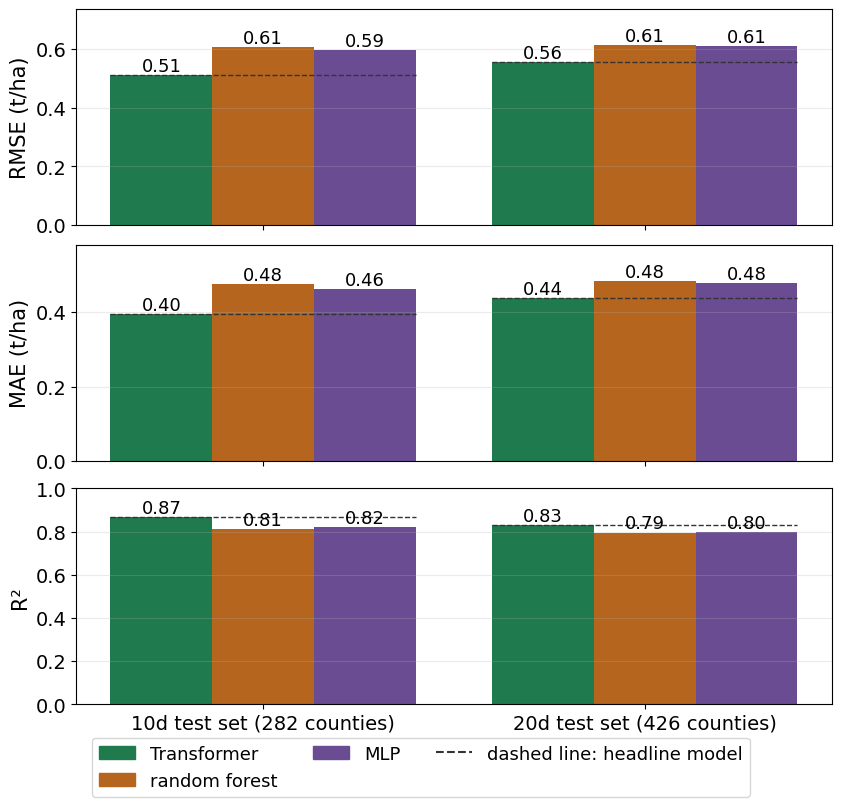

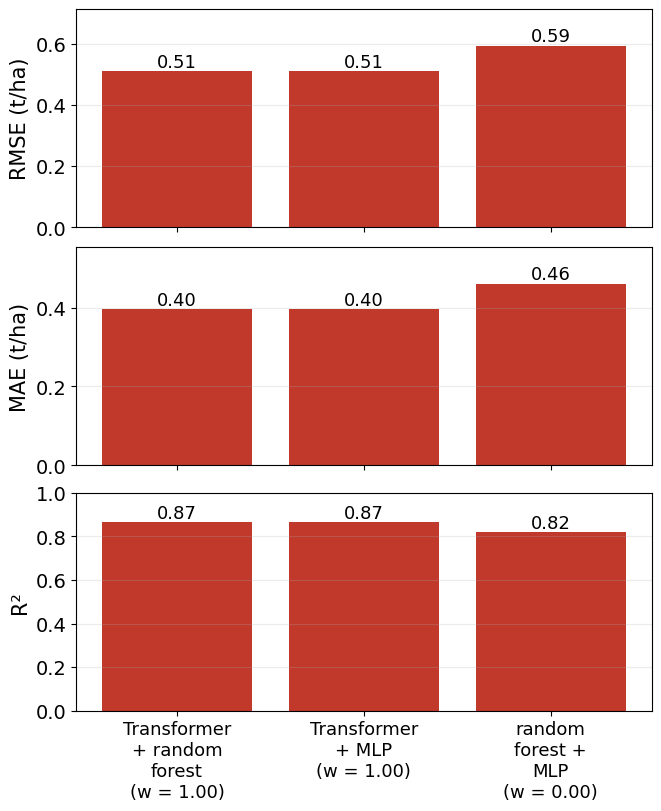

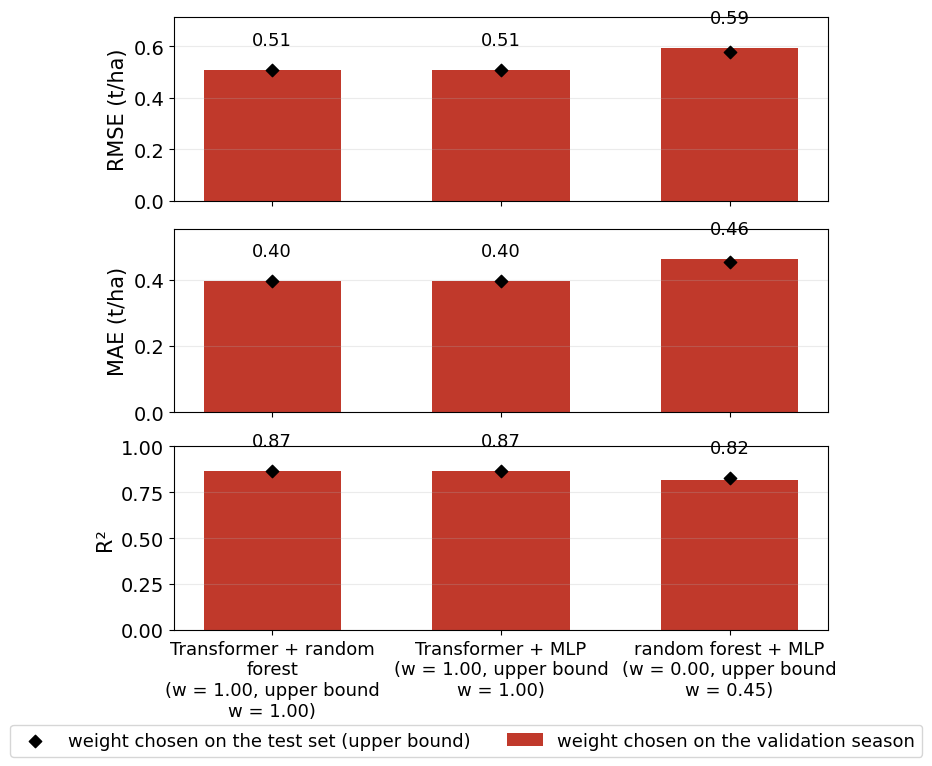

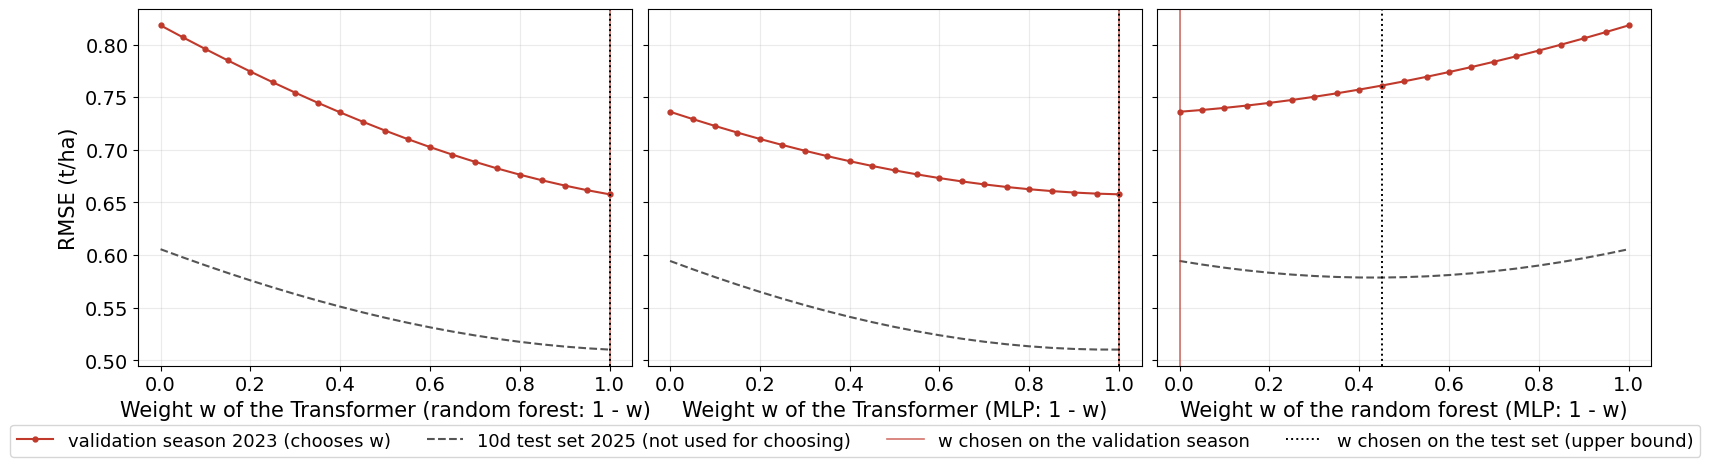

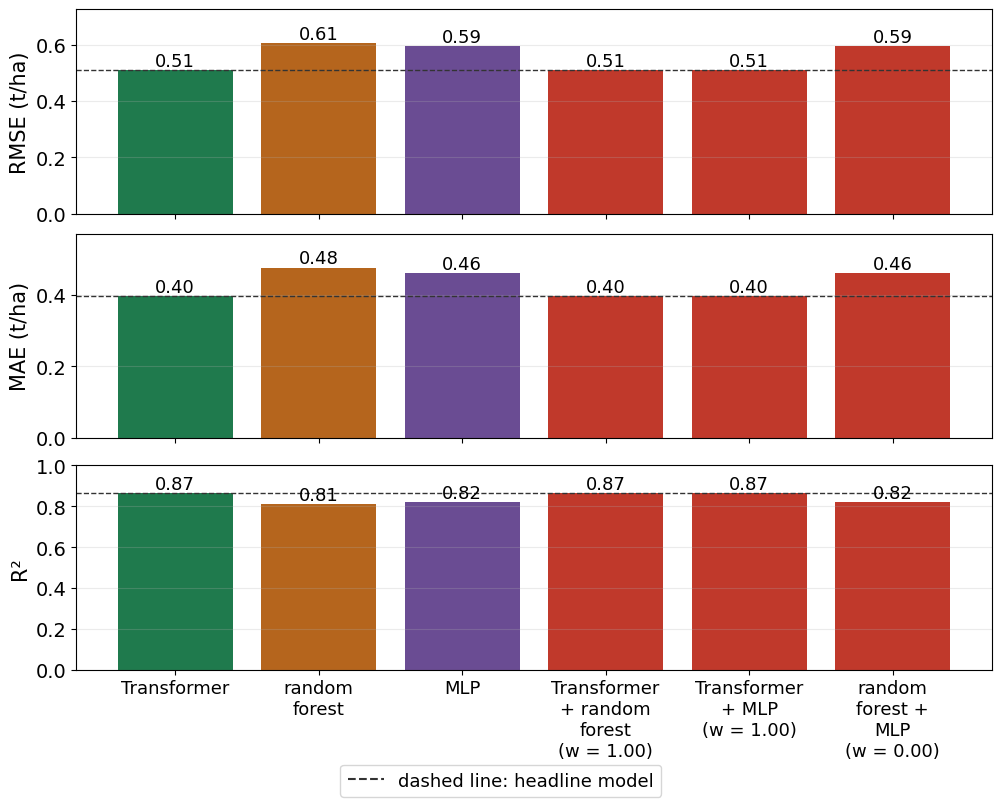

In [38]:
# Every model of section 3 on the 2025 holdout: the table, the methods and the combination variants
section3_models = {
    "transformer (E7)": (e07_validation_ensemble, e07_test_ensemble),
    "random forest (E8)": (e08_validation_prediction, e08_test_prediction),
    "MLP (E9)": (e09_validation_ensemble, e09_test_ensemble),
}
for pair_name in COMBINATION_PAIRS:
    section3_models[f"{pair_name}, w from 2023"] = (blend_validation_predictions[pair_name], blend_test_predictions[pair_name])
    section3_models[f"{pair_name}, oracle w from 2025"] = (None, oracle_test_predictions[pair_name])
section3_rows = []
for model_name, (validation_prediction, test_prediction) in section3_models.items():
    if validation_prediction is None:
        validation_rmse = np.nan
    else:
        validation_rmse = validation_rmse_t_per_ha(validation_prediction)
    if model_name == "transformer (E7)":
        verdict = "reference"
    else:
        verdict = noise_verdict(headline_rmse(test_prediction), headline_rmse(e07_test_ensemble))
    section3_rows.append({"model": model_name, "validation 2023 RMSE (t/ha)": validation_rmse,
                          **test_table_columns(test_prediction), "against the transformer (E7)": verdict})
section3_table = pd.DataFrame(section3_rows)
section3_table.to_csv(os.path.join(experiment_folder("section3_comparison"), "results.csv"), index=False)
display(section3_table)

METHOD_PREDICTIONS = {"Transformer": e07_test_ensemble, "random forest": e08_test_prediction, "MLP": e09_test_ensemble}
METHOD_COLOURS = {"Transformer": MODEL_COLOURS["headline transformer"], "random forest": MODEL_COLOURS["random forest"],
                  "MLP": MODEL_COLOURS["MLP"]}
plot_bars_by_test_set(METHOD_PREDICTIONS, METHOD_COLOURS, "section3_comparison", "methods_2025.png",
                      reference_name="Transformer", reference_legend_label="headline model")

# variant a: the combinations with the weight chosen on 2023
combination_labels = {pair_name: f"{pair_name}\n(w = {blend_weights[pair_name]:.2f})" for pair_name in COMBINATION_PAIRS}
plot_prediction_bars({combination_labels[pair_name]: blend_test_predictions[pair_name] for pair_name in COMBINATION_PAIRS},
                     {combination_labels[pair_name]: MODEL_COLOURS["blend"] for pair_name in COMBINATION_PAIRS},
                     "section3_comparison", "combinations_variant_a.png", cohorts=("headline",))

# variant b: as a, with the oracle as a marker
pair_names = list(COMBINATION_PAIRS)
figure, axes = plt.subplots(3, 1, figsize=(7.5, 7.6), sharex=True, layout="constrained")
for axis, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    chosen_values = [cohort_metrics(blend_test_predictions[name])["headline"][metric] for name in pair_names]
    oracle_values = [cohort_metrics(oracle_test_predictions[name])["headline"][metric] for name in pair_names]
    axis.bar(range(len(pair_names)), chosen_values, 0.6, color=MODEL_COLOURS["blend"],
             label="weight chosen on the validation season")
    axis.scatter(range(len(pair_names)), oracle_values, marker="D", s=40, color="black", zorder=3,
                 label="weight chosen on the test set (upper bound)")
    for position, value in enumerate(chosen_values):
        axis.text(position, max(value, oracle_values[position]), f"{value:.2f}\n", ha="center", va="bottom", fontsize=VALUE_FONT_SIZE)
    if metric == "R2":
        axis.set_ylim(0.0, 1.0)
    else:
        axis.set_ylim(0.0, 1.2 * max(chosen_values + oracle_values))
    axis.set_ylabel(METRIC_AXIS_LABELS[metric])
    axis.grid(axis="y", alpha=0.25)
axes[-1].set_xticks(range(len(pair_names)))
axes[-1].set_xticklabels([wrap_label(f"{name}\n(w = {blend_weights[name]:.2f}, upper bound w = {oracle_weights[name]:.2f})", 22)
                          for name in pair_names], fontsize=CATEGORY_FONT_SIZE)
legend_handles, legend_labels = axes[0].get_legend_handles_labels()
figure.legend(legend_handles, legend_labels, ncol=2, loc="outside lower center")
save_figure(figure, "section3_comparison", "combinations_variant_b.png")

# variant c: the RMSE over the whole range of w, one panel per pair
figure, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=True, layout="constrained")
for axis, (pair_name, (_, first_name, second_name, *_)) in zip(axes, COMBINATION_PAIRS.items()):
    validation_curve, test_curve = blend_curves[pair_name]
    axis.plot(BLEND_WEIGHTS, validation_curve, "-o", markersize=3.5, color=MODEL_COLOURS["blend"],
              label="validation season 2023 (chooses w)")
    axis.plot(BLEND_WEIGHTS, test_curve, "--", color="#555555", label=f"{TEST_SET_10D} 2025 (not used for choosing)")
    axis.axvline(blend_weights[pair_name], color=MODEL_COLOURS["blend"], linewidth=1.2, alpha=0.7,
                 label="w chosen on the validation season")
    axis.axvline(oracle_weights[pair_name], color="black", linestyle=":", linewidth=1.4,
                 label="w chosen on the test set (upper bound)")
    axis.set_xlabel(f"Weight w of the {first_name} ({second_name}: 1 - w)")
    axis.grid(alpha=0.25)
axes[0].set_ylabel("RMSE (t/ha)")
legend_handles, legend_labels = axes[0].get_legend_handles_labels()
figure.legend(legend_handles, legend_labels, ncol=4, loc="outside lower center")
save_figure(figure, "section3_comparison", "combinations_variant_c.png")

# variant d: the three methods and the three combinations, without the oracle
variant_d_predictions = dict(METHOD_PREDICTIONS)
variant_d_colours = dict(METHOD_COLOURS)
for pair_name in COMBINATION_PAIRS:
    variant_d_predictions[combination_labels[pair_name]] = blend_test_predictions[pair_name]
    variant_d_colours[combination_labels[pair_name]] = MODEL_COLOURS["blend"]
plot_prediction_bars(variant_d_predictions, variant_d_colours, "section3_comparison", "combinations_variant_d.png",
                     cohorts=("headline",), reference_name="Transformer", reference_legend_label="headline model")

### 3.5 E22–E24 — Leave one year out for every methodology
The folds of E1. Every method keeps one setting in every fold, as the Transformer (E1) keeps its
configuration: the random forest the settings chosen in 3.2 (E22), the MLP the configuration chosen in
3.3, 30 models per fold (E23). Those were chosen on 2023, which is the held-out season of one fold; the
same holds for the configuration of the Transformer. The combinations choose *w* on each fold's
validation season (E24). The noise rule is applied to the mean over the held-out seasons of the 10-day
complete RMSE. The figure shows the three methods; the combinations are in the table.

An earlier version searched the forest grid and the MLP configurations again in every fold (cache folders
`e22_loyo_random_forest/` and the other configurations in `e23_loyo_mlp/`, kept but no longer read).

In [39]:
# E22 random forest per fold (CPU), with the settings chosen on 2023 in 3.2
def chosen_forest_settings(search_table):
    """The settings of the row chosen on the validation season, with their original types."""
    chosen = search_table[search_table["chosen"]].iloc[0]
    max_features = chosen["max_features"] if chosen["max_features"] == "sqrt" else float(chosen["max_features"])
    max_depth = None if str(chosen["max_depth"]) == "None" else int(float(chosen["max_depth"]))
    return dict(n_estimators=int(chosen["n_estimators"]), max_features=max_features,
                max_depth=max_depth, min_samples_leaf=int(chosen["min_samples_leaf"]))


def fit_random_forest_with_settings(split, settings, folder_name):
    """One forest with fixed settings on the training rows of a split; predicts its validation and test
    rows. Cached in folder_name (predictions.npz). Returns dict(validation, test)."""
    predictions_file = os.path.join(experiment_folder(folder_name), "predictions.npz")
    if os.path.exists(predictions_file):
        with np.load(predictions_file) as cached_predictions:
            return dict(validation=cached_predictions["validation"], test=cached_predictions["test"])
    forest_inputs = tree_inputs(lean_tokens_raw, split)
    anomaly_target = split["yield_actual"] - split["yield_history"]
    forest = RandomForestRegressor(**settings, random_state=RANDOM_FOREST_RANDOM_STATE, n_jobs=-1)
    forest.fit(forest_inputs[split["is_train_row"]], anomaly_target[split["is_train_row"]])
    validation = forest.predict(forest_inputs[split["is_val_row"]]) + split["yield_history"][split["is_val_row"]]
    test = forest.predict(forest_inputs[split["is_test_row"]]) + split["yield_history"][split["is_test_row"]]
    np.savez(predictions_file, validation=validation, test=test)
    return dict(validation=validation, test=test)


E22_FOREST_SETTINGS = chosen_forest_settings(e08_forest["search"])
print(f"every fold uses the settings chosen in 3.2: {E22_FOREST_SETTINGS}, random_state={RANDOM_FOREST_RANDOM_STATE}")
e22_prediction_by_year = {}
e22_validation_by_year = {}
for held_out_year in LOYO_YEARS:
    fold_forest = fit_random_forest_with_settings(loyo_split(held_out_year), E22_FOREST_SETTINGS,
                                                  os.path.join("e22_loyo_random_forest_e08_settings", f"fold_{held_out_year}"))
    e22_prediction_by_year[held_out_year] = fold_forest["test"]
    e22_validation_by_year[held_out_year] = fold_forest["validation"]
    print(f"fold {held_out_year}: ready", flush=True)
assert np.allclose(e22_prediction_by_year[2025], e08_test_prediction), "the 2025 fold must reproduce E8"

every fold uses the settings chosen in 3.2: {'n_estimators': 300, 'max_features': 'sqrt', 'max_depth': None, 'min_samples_leaf': 1}, random_state=0
fold 2016: ready


fold 2017: ready


fold 2018: ready


fold 2019: ready


fold 2020: ready


fold 2021: ready


fold 2022: ready


fold 2023: ready


fold 2025: ready


In [40]:
# E23 MLP per fold, with the configuration chosen on 2023 in 3.3
N_MODELS_E23 = N_MODELS_PER_ENSEMBLE
E23_CONFIGURATION = e09_chosen_configuration
print(f"every fold uses the configuration chosen in 3.3: {E23_CONFIGURATION['n_hidden_layers']} x "
      f"{E23_CONFIGURATION['hidden_width']}, {N_MODELS_E23} models per fold")

e23_test_by_year = {}
e23_validation_by_year = {}
e23_test_bank_by_year = {}
for held_out_year in LOYO_YEARS:
    fold_split, fold_tokens, fold_coverage = prepare_loyo_fold(held_out_year)
    fold_validation_bank, fold_test_bank = load_or_train_bank(
        mlp_folder_name(os.path.join("e23_loyo_mlp", f"fold_{held_out_year}", "mlp"), E23_CONFIGURATION), N_MODELS_E23,
        lambda seed: train_mlp(E23_CONFIGURATION, fold_tokens, fold_coverage, fold_split, seed))
    e23_test_by_year[held_out_year] = fold_test_bank.mean(axis=0)
    e23_validation_by_year[held_out_year] = fold_validation_bank.mean(axis=0)
    e23_test_bank_by_year[held_out_year] = fold_test_bank
    print(f"fold {held_out_year}: {len(fold_test_bank)} models", flush=True)

every fold uses the configuration chosen in 3.3: 2 x 256, 30 models per fold
fold 2016: 30 models


fold 2017: 30 models


fold 2018: 30 models


fold 2019: 30 models


fold 2020: 30 models


fold 2021: 30 models


fold 2022: 30 models


fold 2023: 30 models


fold 2025: 30 models


blend weights chosen on each fold's validation season:


,held-out season,w transformer + random forest,w transformer + MLP,w random forest + MLP
0,2016,1.0,0.85,0.00
1,2017,1.0,0.70,0.00
2,2018,1.0,0.95,0.00
3,2019,1.0,0.95,0.00
4,2020,1.0,0.30,0.00
5,2021,1.0,0.80,0.00
6,2022,1.0,1.00,0.00
7,2023,1.0,1.00,0.45
8,2025,1.0,1.00,0.00


mean over the held-out seasons:


,10-day complete RMSE (t/ha),10-day complete MAE (t/ha),10-day complete R2,10-day complete nRMSE (%),all counties RMSE (t/ha),all counties MAE (t/ha),all counties R2,all counties nRMSE (%),against the transformer (E1)
model,,,,,,,,,
transformer (E1),0.56,0.44,0.77,14.59,0.58,0.45,0.74,14.36,reference
random forest (E22),0.69,0.54,0.63,18.12,0.69,0.54,0.63,16.94,higher RMSE (+0.134)
MLP (E23),0.59,0.46,0.74,15.44,0.62,0.48,0.71,15.14,higher RMSE (+0.034)
transformer + random forest (E24),0.56,0.44,0.77,14.59,0.58,0.45,0.74,14.36,within noise (+0.000)
transformer + MLP (E24),0.56,0.44,0.77,14.66,0.59,0.45,0.74,14.42,within noise (+0.003)
random forest + MLP (E24),0.60,0.47,0.74,15.46,0.62,0.48,0.71,15.18,higher RMSE (+0.035)


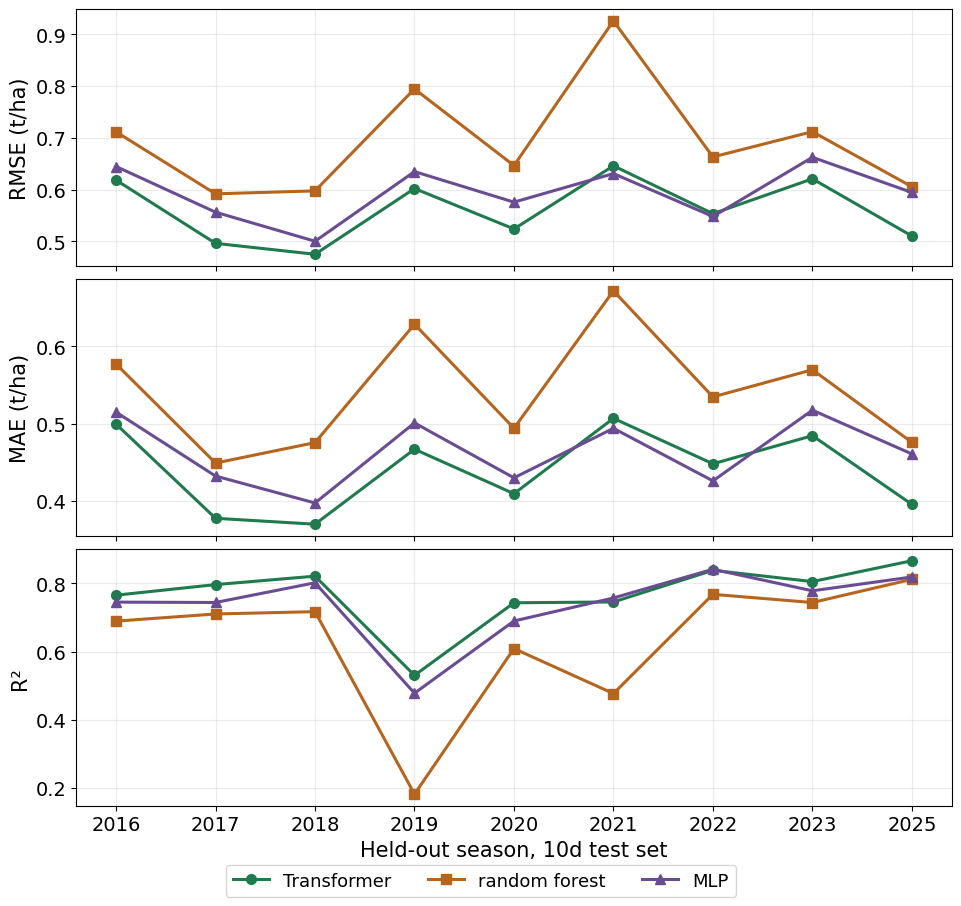

In [41]:
# E24 blends per fold, and the leave-one-year-out comparison of all methodologies
e24_rf_blend_by_year = {}
e24_mlp_blend_by_year = {}
e24_rf_mlp_blend_by_year = {}
e24_weight_rows = []
for held_out_year in LOYO_YEARS:
    actual_validation = yield_actual[loyo_split(held_out_year)["is_val_row"]]
    _, rf_blend, rf_weight = blend_predictions(e01_validation_by_year[held_out_year], e01_test_by_year[held_out_year],
                                               e22_validation_by_year[held_out_year], e22_prediction_by_year[held_out_year],
                                               actual_validation)
    _, mlp_blend, mlp_weight = blend_predictions(e01_validation_by_year[held_out_year], e01_test_by_year[held_out_year],
                                                 e23_validation_by_year[held_out_year], e23_test_by_year[held_out_year],
                                                 actual_validation)
    _, rf_mlp_fold_blend, rf_mlp_fold_weight = blend_predictions(
        e22_validation_by_year[held_out_year], e22_prediction_by_year[held_out_year],
        e23_validation_by_year[held_out_year], e23_test_by_year[held_out_year], actual_validation)
    e24_rf_blend_by_year[held_out_year] = rf_blend
    e24_mlp_blend_by_year[held_out_year] = mlp_blend
    e24_rf_mlp_blend_by_year[held_out_year] = rf_mlp_fold_blend
    e24_weight_rows.append({"held-out season": held_out_year,
                            "w transformer + random forest": rf_weight,
                            "w transformer + MLP": mlp_weight,
                            "w random forest + MLP": rf_mlp_fold_weight})
print("blend weights chosen on each fold's validation season:")
display(pd.DataFrame(e24_weight_rows))

loyo_methodologies = {
    "transformer (E1)": (e01_test_by_year, MODEL_COLOURS["headline transformer"], "-o"),
    "random forest (E22)": (e22_prediction_by_year, MODEL_COLOURS["random forest"], "-s"),
    "MLP (E23)": (e23_test_by_year, MODEL_COLOURS["MLP"], "-^"),
    "transformer + random forest (E24)": (e24_rf_blend_by_year, MODEL_COLOURS["blend"], "--s"),
    "transformer + MLP (E24)": (e24_mlp_blend_by_year, MODEL_COLOURS["blend"], ":^"),
    "random forest + MLP (E24)": (e24_rf_mlp_blend_by_year, MODEL_COLOURS["oracle blend"], "--v"),
}
loyo_rows = []
for model_name, (prediction_by_year, _, _) in loyo_methodologies.items():
    for held_out_year in LOYO_YEARS:
        loyo_rows.append({"model": model_name, "held-out season": held_out_year,
                          **loyo_season_metrics(held_out_year, prediction_by_year[held_out_year])})
loyo_methodology_table = pd.DataFrame(loyo_rows)
loyo_methodology_table.round(2).to_csv(os.path.join(experiment_folder("e24_loyo_methodologies"), "results_per_season.csv"), index=False)
loyo_methodology_means = loyo_methodology_table.drop(columns="held-out season").groupby("model", sort=False).mean()
transformer_loyo_rmse = loyo_mean_rmse(e01_test_by_year)
loyo_methodology_means["against the transformer (E1)"] = [
    "reference" if model_name == "transformer (E1)" else noise_verdict(loyo_mean_rmse(prediction_by_year), transformer_loyo_rmse)
    for model_name, (prediction_by_year, _, _) in loyo_methodologies.items()]
loyo_methodology_means = loyo_methodology_means.round(2)
loyo_methodology_means.to_csv(os.path.join(experiment_folder("e24_loyo_methodologies"), "results_mean_over_seasons.csv"))
print("mean over the held-out seasons:")
display(loyo_methodology_means)

record_loyo_in_summary("3.5", "random forest (E22)", e22_prediction_by_year, models="1 forest per fold",
                       note="settings of E8 in every fold")
record_loyo_in_summary("3.5", "MLP (E23)", e23_test_by_year, models=f"{N_MODELS_E23} per fold",
                       note="configuration of E9 in every fold")
record_single_models("3.5", "MLP (2025: E9, LOYO: E23)", loyo_test_bank_by_year=e23_test_bank_by_year, colour=MODEL_COLOURS["MLP"])
record_loyo_in_summary("3.5", "transformer + random forest blend (E24)", e24_rf_blend_by_year, note="w chosen per fold on its validation season")
record_loyo_in_summary("3.5", "transformer + MLP blend (E24)", e24_mlp_blend_by_year, note="w chosen per fold on its validation season")
record_loyo_in_summary("3.5", "random forest + MLP blend (E24)", e24_rf_mlp_blend_by_year, note="w chosen per fold on its validation season")

# the figure shows the three methods; the combinations are in the table
LOYO_METHODS_IN_FIGURE = {"transformer (E1)": "Transformer", "random forest (E22)": "random forest", "MLP (E23)": "MLP"}
figure, axes = plt.subplots(3, 1, figsize=(9.5, 9.0), sharex=True, layout="constrained")
positions = np.arange(len(LOYO_YEARS))
for axis, (metric_column, axis_label) in zip(axes, [("10-day complete RMSE (t/ha)", "RMSE (t/ha)"),
                                                    ("10-day complete MAE (t/ha)", "MAE (t/ha)"),
                                                    ("10-day complete R2", "R²")]):
    for model_name, figure_name in LOYO_METHODS_IN_FIGURE.items():
        _, colour, line_style = loyo_methodologies[model_name]
        model_rows = loyo_methodology_table[loyo_methodology_table.model == model_name]
        axis.plot(positions, model_rows[metric_column], line_style, color=colour, linewidth=2.2, markersize=7, label=figure_name)
    axis.set_xticks(positions)
    axis.set_xticklabels([str(held_out_year) for held_out_year in LOYO_YEARS])
    axis.set_ylabel(axis_label)
    axis.grid(alpha=0.25)
axes[-1].set_xlabel(f"Held-out season, {TEST_SET_10D}")
legend_handles, legend_labels = axes[0].get_legend_handles_labels()
figure.legend(legend_handles, legend_labels, ncol=3, loc="outside lower center")
save_figure(figure, "e24_loyo_methodologies", "loyo_methods.png")

### Reading, section 3
- **Transformer (E7).** 0.51 on the 10-day complete counties and 0.56 on all counties, identical to the
  headline of `01`.
- **Random forest (E8).** 0.61, worse by 0.10, with the weakest validation RMSE of the three (0.82).
- **MLP (E9).** The check picks two hidden layers of width 256. It reaches 0.59, worse by 0.08.
- **Combinations (E10, E11).** Both weights chosen on 2023 are 1.00, the transformer alone, and so is the
  oracle weight chosen on 2025. Neither partner carries information the transformer does not already use.
- **Random forest with the MLP.** The weight chosen on 2023 is 0.00, so the combination is the MLP alone
  (0.59). Even the oracle weight of 0.45 only reaches 0.58, still 0.07 worse than the transformer. The two
  weaker methods do not compensate for each other.
- **Leave one year out (E22–E24), one setting in every fold.** Transformer 0.56, random forest 0.69
  (+0.13), MLP 0.59 (+0.03), the forest with the MLP 0.60 (+0.03). Both combinations with the transformer
  stay within noise of it. The ranking of the three methods is the same over nine seasons as on 2025
  alone. With a search in every fold (the earlier version) the forest reached 0.66 and the MLP 0.60, so the
  fixed setting costs the forest 0.03 and leaves the MLP unchanged within noise.

## 4. Effect of inclusion and exclusion of inputs

### 4.1 Soil: the mechanism ladder (repeated from `02` at the headline width)
Removing soil once meant removing the soil values **and** the cross-attention block together. Three
controls separate the two, 30 models each at the headline width, compared with the register headline
configuration (E7). The soil vector holds the 18 properties that are the first of their correlation group in
the ranking of section 5.2, at the threshold 0.85 (folders `soil_ladder_*_grouped_085_*`; the earlier runs on
the hand-made 18 and on the 15 groups of the threshold 0.80 are kept next to them):

| variant | the cross-attention block attends to |
|---|---|
| register (headline) | 18 learned tokens, no external data |
| real soil | the county's own 18 SoilGrids properties |
| permuted soil | another county's soil: block kept, information destroyed |
| no cross-attention block | nothing, the block is removed |

permuted − real = the soil **information**; no block − permuted = the block's **capacity**. Every
comparison is judged with the noise rule.

In [42]:
# Soil ladder at the headline width
N_MODELS_SOIL_LADDER = N_MODELS_PER_ENSEMBLE


def train_soil_variant(variant, seed):
    """One model of a soil-ladder variant with the headline protocol."""
    random_generator = np.random.default_rng(seed)
    if variant == "permuted":
        shuffled_counties = random_generator.permutation(len(unique_counties))
        soil_input = soil_by_county[shuffled_counties][county_index]
        architecture = SoilCrossAttentionPredictor
    elif variant == "no_block":
        soil_input = soil_values_standardized
        architecture = NoCrossAttentionPredictor
    else:
        soil_input = soil_values_standardized
        architecture = SoilCrossAttentionPredictor
    return train_neural_model(
        build_model=lambda: architecture(lean_tokens_headline.shape[2]),
        input_arrays=[lean_tokens_headline, history_headline, coverage_headline, soil_input],
        split=headline_split, seed=seed)


soil_ladder_validation = {}
soil_ladder_test = {}
soil_ladder_test_banks = {}
for variant_name, variant in [("real soil", "real_soil"), ("permuted soil", "permuted"),
                              ("no cross-attention block", "no_block")]:
    variant_validation_bank, variant_test_bank = load_or_train_bank(
        f"soil_ladder_{variant}_grouped_085_{HEADLINE_WIDTH_TAG}", N_MODELS_SOIL_LADDER,
        lambda seed: train_soil_variant(variant, seed))
    soil_ladder_validation[variant_name] = variant_validation_bank.mean(axis=0)
    soil_ladder_test[variant_name] = variant_test_bank.mean(axis=0)
    soil_ladder_test_banks[variant_name] = variant_test_bank

,variant,282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%),against the register headline
0,"register (headline, no soil)",0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4,reference
1,real soil,0.51,0.39,0.87,11.8,0.55,0.43,0.83,12.3,within noise (-0.004)
2,permuted soil,0.51,0.39,0.87,11.9,0.55,0.43,0.83,12.3,within noise (-0.001)
3,no cross-attention block,0.52,0.40,0.86,12.1,0.56,0.44,0.83,12.4,within noise (+0.007)


soil information = permuted - real soil: +0.00 t/ha, real against permuted soil: within noise (-0.003)
block capacity   = no block - permuted  : +0.01 t/ha, permuted soil against no block: within noise (-0.008)


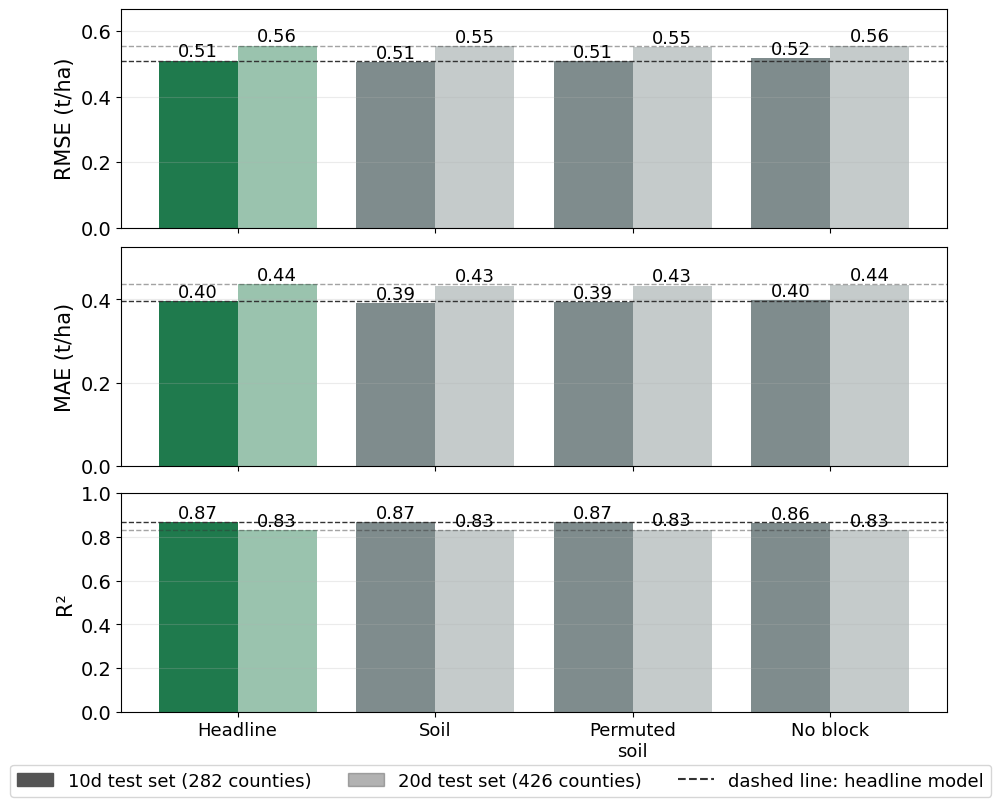

In [43]:
# The ladder and the information / capacity decomposition, judged with the noise rule
soil_ladder = {"register (headline, no soil)": e07_test_ensemble, **soil_ladder_test}
soil_ladder_rows = []
for variant_name, prediction in soil_ladder.items():
    if variant_name == "register (headline, no soil)":
        verdict = "reference"
    else:
        verdict = noise_verdict(headline_rmse(prediction), headline_rmse(e07_test_ensemble))
        record_in_summary("4.1", f"soil ladder: {variant_name}", prediction, models=N_MODELS_SOIL_LADDER)
        record_single_models("4.1", f"soil ladder: {variant_name}", test_bank=soil_ladder_test_banks[variant_name])
    soil_ladder_rows.append({"variant": variant_name, **test_table_columns(prediction), "against the register headline": verdict})
soil_ladder_table = pd.DataFrame(soil_ladder_rows)
soil_ladder_table.to_csv(os.path.join(experiment_folder("section4_soil_ladder"), "results.csv"), index=False)
display(soil_ladder_table)

rmses_by_variant = {name: headline_rmse(prediction) for name, prediction in soil_ladder.items()}
soil_information = round((rmses_by_variant["permuted soil"] - rmses_by_variant["real soil"]) / DT_HA_PER_T_HA, 2) + 0.0
block_capacity = round((rmses_by_variant["no cross-attention block"] - rmses_by_variant["permuted soil"]) / DT_HA_PER_T_HA, 2) + 0.0
print(f"soil information = permuted - real soil: {soil_information:+.2f} t/ha, "
      f"real against permuted soil: {noise_verdict(rmses_by_variant['real soil'], rmses_by_variant['permuted soil'])}")
print(f"block capacity   = no block - permuted  : {block_capacity:+.2f} t/ha, "
      f"permuted soil against no block: {noise_verdict(rmses_by_variant['permuted soil'], rmses_by_variant['no cross-attention block'])}")

# named as in the thesis
SOIL_FIGURE_NAMES = {"register (headline, no soil)": "Headline", "real soil": "Soil", "permuted soil": "Permuted soil",
                     "no cross-attention block": "No block"}
soil_colours = {figure_name: MODEL_COLOURS["variant"] for figure_name in SOIL_FIGURE_NAMES.values()}
soil_colours["Headline"] = MODEL_COLOURS["headline transformer"]
plot_prediction_bars({SOIL_FIGURE_NAMES[name]: prediction for name, prediction in soil_ladder.items()}, soil_colours,
                     "section4_soil_ladder", "soil.png", cohorts=("headline", "full"), reference_name="Headline",
                     reference_legend_label="headline model")

### 4.2 E12 — Without the historical yield
Two variants, 30 models each:
- **E12a, history removed as an input.** The history branch is dropped (head input 2 × width →
  width). The target stays the standardized anomaly and the history is still added back. Asks
  whether the model needs history as an input when the target already encodes it.
- **E12b, no history anywhere.** No history input, the target is the standardized raw yield, nothing
  is added back. Measures the total contribution of history.

In [44]:
# E12a and E12b
N_MODELS_E12 = N_MODELS_PER_ENSEMBLE

e12a_validation_bank, e12a_test_bank = load_or_train_bank(
    f"e12a_no_history_input_{HEADLINE_WIDTH_TAG}", N_MODELS_E12,
    lambda seed: train_neural_model(
        build_model=lambda: NoHistoryYieldPredictor(lean_tokens_headline.shape[2]),
        input_arrays=[lean_tokens_headline, coverage_headline],
        split=headline_split, seed=seed, target_kind="anomaly"))
e12b_validation_bank, e12b_test_bank = load_or_train_bank(
    f"e12b_no_history_anywhere_{HEADLINE_WIDTH_TAG}", N_MODELS_E12,
    lambda seed: train_neural_model(
        build_model=lambda: NoHistoryYieldPredictor(lean_tokens_headline.shape[2]),
        input_arrays=[lean_tokens_headline, coverage_headline],
        split=headline_split, seed=seed, target_kind="raw_yield"))

### 4.3 E13 — Without the temporal deltas
The five temporal deltas are dropped, leaving 22 values per window. 30 models.

In [45]:
# E13: 16 band statistics + 6 spectral indices
N_MODELS_E13 = N_MODELS_PER_ENSEMBLE

tokens_without_deltas = standardize_tokens(lean_tokens_raw[:, :, BAND_STATISTIC_POSITIONS + SPECTRAL_INDEX_POSITIONS],
                                           headline_split["is_train_row"])
e13_validation_bank, e13_test_bank = load_or_train_bank(
    f"e13_no_delta_features_{HEADLINE_WIDTH_TAG}", N_MODELS_E13,
    lambda seed: train_headline_model(tokens_without_deltas, coverage_headline, headline_split, seed))
print(f"E13 tokens: {tokens_without_deltas.shape[2]} values per window")

E13 tokens: 22 values per window


### 4.4 E20b — Without spectral indices
Can the model work from raw reflectance alone? Every vegetation index leaves the token: the six indices
computed from the window means, the mean and the standard deviation of the NDVI and GCVI bands, and the
NDVI and GCVI deltas. What remains are the six reflectance bands with their mean and standard deviation
and the three reflectance deltas, 15 values per window. 30 models.

The weaker variant that drops the six derived indices only (E20) is in appendix A.4.

In [46]:
# E20b: no index information at all, reflectance bands and their deltas only
N_MODELS_E20 = N_MODELS_PER_ENSEMBLE

tokens_without_any_index = standardize_tokens(
    lean_tokens_raw[:, :, REFLECTANCE_STATISTIC_POSITIONS + REFLECTANCE_DELTA_POSITIONS],
    headline_split["is_train_row"])
e20b_validation_bank, e20b_test_bank = load_or_train_bank(
    f"e20b_no_index_information_{HEADLINE_WIDTH_TAG}", N_MODELS_E20,
    lambda seed: train_headline_model(tokens_without_any_index, coverage_headline, headline_split, seed))
print(f"E20b tokens: {tokens_without_any_index.shape[2]} values per window (no index information)")

E20b tokens: 15 values per window (no index information)


### 4.5 E14 — Additional statistics
The 27 lean values **plus** the 88 statistics the lean set drops (the nine percentiles, skewness and
kurtosis of all eight bands), 115 values per window. This isolates whether adding the dropped
statistics back helps. The raw 104-statistic set is a different test, since it has no indices and no
deltas. 30 models.

In [47]:
# E14: lean tokens + the 88 dropped statistics
N_MODELS_E14 = N_MODELS_PER_ENSEMBLE

dropped_statistic_tokens_raw = build_statistic_tokens(county_year_features, DROPPED_STATISTIC_NAMES)
tokens_all_statistics = standardize_tokens(np.concatenate([lean_tokens_raw, dropped_statistic_tokens_raw], axis=2),
                                           headline_split["is_train_row"])
e14_validation_bank, e14_test_bank = load_or_train_bank(
    f"e14_all_statistics_{HEADLINE_WIDTH_TAG}", N_MODELS_E14,
    lambda seed: train_headline_model(tokens_all_statistics, coverage_headline, headline_split, seed))
print(f"E14 tokens: {tokens_all_statistics.shape[2]} values per window")

E14 tokens: 115 values per window


### 4.6 Comparison of the input variants
Every variant of 4.2 to 4.5 against E7, which shares their protocol, width, seeds and ensemble size. The
verdict column applies the noise rule. One figure on the 10d test set, in the order of the thesis.

,variant,values per window,validation 2023 RMSE (t/ha),282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%),against the headline inputs
0,headline inputs (E7),27,0.66,0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4,reference
1,E12a without history as input,27,0.77,0.62,0.48,0.81,14.4,0.62,0.48,0.79,13.8,higher RMSE (+0.105)
2,E12b without history anywhere,27,0.76,0.64,0.49,0.79,15.0,0.72,0.56,0.72,16.0,higher RMSE (+0.131)
3,E13 without delta features,22,0.65,0.51,0.39,0.87,11.8,0.55,0.43,0.83,12.3,within noise (-0.004)
4,E20b without any index information,15,0.66,0.51,0.39,0.87,11.9,0.55,0.43,0.84,12.2,within noise (-0.003)
5,E14 plus the 88 dropped statistics,115,0.66,0.52,0.40,0.86,12.1,0.56,0.44,0.83,12.6,within noise (+0.008)


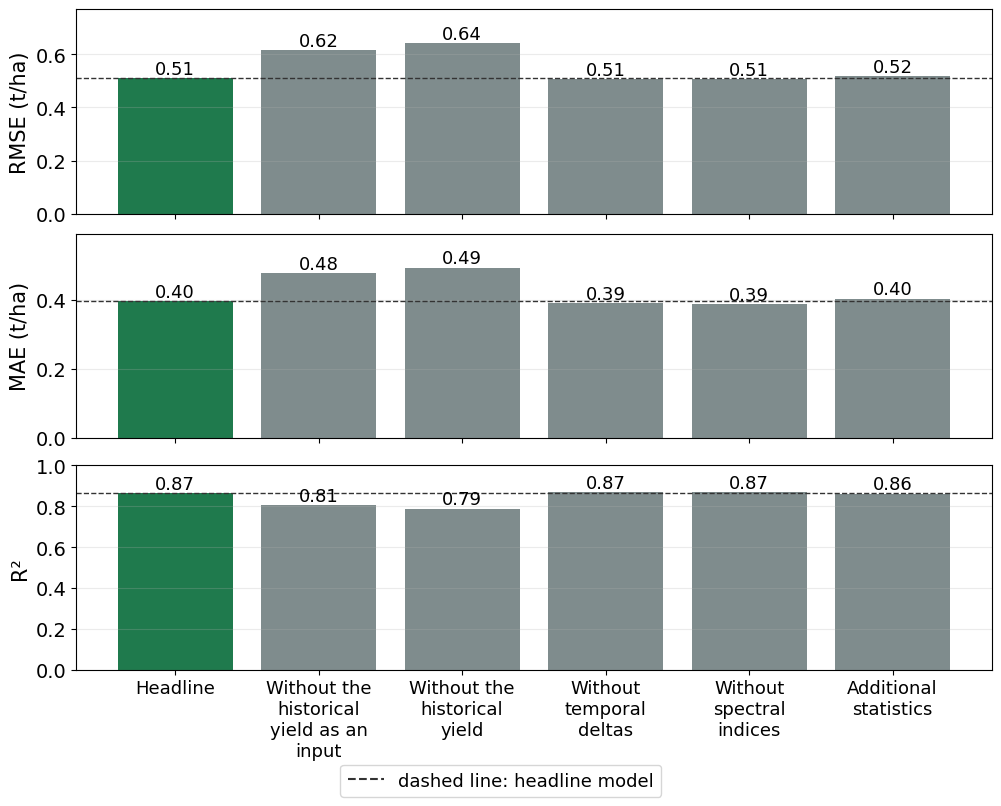

In [48]:
# Section 4 comparison, in the order of the thesis; figure names as in the thesis
input_variants = {
    "headline inputs (E7)": ("Headline", e07_validation_ensemble, e07_test_ensemble, lean_tokens_headline.shape[2]),
    "E12a without history as input": ("Without the historical yield as an input", e12a_validation_bank.mean(axis=0), e12a_test_bank.mean(axis=0), lean_tokens_headline.shape[2]),
    "E12b without history anywhere": ("Without the historical yield", e12b_validation_bank.mean(axis=0), e12b_test_bank.mean(axis=0), lean_tokens_headline.shape[2]),
    "E13 without delta features": ("Without temporal deltas", e13_validation_bank.mean(axis=0), e13_test_bank.mean(axis=0), tokens_without_deltas.shape[2]),
    "E20b without any index information": ("Without spectral indices", e20b_validation_bank.mean(axis=0), e20b_test_bank.mean(axis=0), tokens_without_any_index.shape[2]),
    "E14 plus the 88 dropped statistics": ("Additional statistics", e14_validation_bank.mean(axis=0), e14_test_bank.mean(axis=0), tokens_all_statistics.shape[2]),
}
SECTION_OF_INPUT_VARIANT = {"E12a": "4.2", "E12b": "4.2", "E13": "4.3", "E20b": "4.4", "E14": "4.5"}
TEST_BANK_OF_INPUT_VARIANT = {"E12a": e12a_test_bank, "E12b": e12b_test_bank, "E13": e13_test_bank,
                              "E20b": e20b_test_bank, "E14": e14_test_bank}

section4_rows = []
for variant_name, (_, validation_prediction, test_prediction, values_per_window) in input_variants.items():
    if variant_name == "headline inputs (E7)":
        verdict = "reference"
    else:
        verdict = noise_verdict(headline_rmse(test_prediction), headline_rmse(e07_test_ensemble))
        experiment_code = variant_name.split(" ")[0]
        record_in_summary(SECTION_OF_INPUT_VARIANT[experiment_code], variant_name, test_prediction, models=N_MODELS_PER_ENSEMBLE)
        record_single_models(SECTION_OF_INPUT_VARIANT[experiment_code], variant_name, test_bank=TEST_BANK_OF_INPUT_VARIANT[experiment_code])
    section4_rows.append({
        "variant": variant_name,
        "values per window": values_per_window,
        "validation 2023 RMSE (t/ha)": validation_rmse_t_per_ha(validation_prediction),
        **test_table_columns(test_prediction),
        "against the headline inputs": verdict,
    })
section4_table = pd.DataFrame(section4_rows)
section4_table.to_csv(os.path.join(experiment_folder("section4_input_variants"), "results.csv"), index=False)
display(section4_table)

input_colours = {figure_name: MODEL_COLOURS["variant"] for figure_name, *_ in input_variants.values()}
input_colours["Headline"] = MODEL_COLOURS["headline transformer"]
plot_prediction_bars({figure_name: test_prediction for figure_name, _, test_prediction, _ in input_variants.values()},
                     input_colours, "section4_input_variants", "inputs.png", cohorts=("headline",),
                     reference_name="Headline", reference_legend_label="headline model")

### Reading, section 4
- **Soil (4.1).** With the 18 properties that are the first of their correlation group at |r| >= 0.85, real
  soil (-0.004), permuted soil (-0.001) and the removed block (+0.007) all lie within noise of the register
  headline. The soil information (permuted minus real) is +0.003 and the block capacity +0.008 t/ha, both
  below the threshold. At this width and with the exact standard deviation, neither the soil values nor the
  cross-attention block change the prediction measurably.
- **Historical yield (4.2, E12).** The only input whose removal clearly hurts: 0.62 without it as an input
  (+0.11) and 0.64 without it anywhere (+0.13), which on all counties becomes 0.72. The validation season
  agrees (0.77 and 0.76 against 0.66).
- **Temporal deltas (4.3).** Without the deltas 0.51, within noise.
- **Spectral indices (4.4, E20b).** Dropping every index, leaving the six reflectance bands and their three
  deltas, 15 values per window, gives 0.51. The model does not need any vegetation index: it reconstructs
  what it needs from raw reflectance.
- **Additional statistics (4.5).** With the 88 dropped statistics 0.52, within noise. The lean set neither
  loses nor gains anything measurable.

## 5. Feature selection

### 5.1 E17 — Random forest ranking of the satellite statistics
All 104 statistics of all 7 windows (728 values) from the 20-day table; no derived indices, no
deltas, no history, no coverage. Target is the anomaly (history median-filled on training rows).
Rows are the training seasons 2016 to 2022 only. Fixed hyperparameters, impurity-based
`feature_importances_` only. Importance is aggregated by statistic type, by band and by window, and
the 25 most important statistics are shown, each summed over the seven windows (the single features per
window are in the table).

In [49]:
# E17: one forest on the training seasons, impurity importances cached as CSV
E17_RANDOM_STATE = 0
SATELLITE_RANKING_COLOUR = "#1f7a4d"      # green, as the satellite model elsewhere
SOIL_RANKING_COLOUR = "#8b5a2b"           # brown, for the soil properties
E17_FOREST_SETTINGS = dict(n_estimators=500, max_features=0.33, min_samples_leaf=5)
BAND_NAMES = {"B2": "Blue (B2)", "B3": "Green (B3)", "B4": "Red (B4)", "B5": "NIR (B5)",
              "B6": "SWIR1 (B6)", "B7": "SWIR2 (B7)", "NDVI": "NDVI", "GCVI": "GCVI"}


def statistic_type_of(statistic_name):
    """Group a statistic suffix: mean, standard deviation, skewness, kurtosis or percentiles."""
    if statistic_name == "mean":
        return "mean"
    elif statistic_name == "stdDev":
        return "standard deviation"
    elif statistic_name == "skew":
        return "skewness"
    elif statistic_name == "kurtosis":
        return "kurtosis"
    else:
        return "percentiles (p10-p90)"


e17_importance_file = os.path.join(experiment_folder("e17_rf_ranking_satellite"), "feature_importances.csv")
is_ranking_row = headline_split["is_train_row"]
assert set(np.unique(year[is_ranking_row])) == {2016, 2017, 2018, 2019, 2020, 2021, 2022}

if os.path.exists(e17_importance_file):
    e17_importances = pd.read_csv(e17_importance_file)
    print("loaded cached importances")
else:
    ranking_columns = [f"w{window:02d}_{name}" for window in range(N_WINDOWS) for name in ALL_STATISTIC_NAMES]
    ranking_target = yield_actual - headline_split["yield_history"]
    forest = RandomForestRegressor(**E17_FOREST_SETTINGS, random_state=E17_RANDOM_STATE, n_jobs=-1)
    forest.fit(county_year_features.loc[is_ranking_row, ranking_columns].to_numpy(np.float32), ranking_target[is_ranking_row])
    e17_importances = pd.DataFrame({"feature": ranking_columns, "importance": forest.feature_importances_})
    e17_importances["window"] = e17_importances.feature.str.slice(1, 3).astype(int)
    e17_importances["band"] = e17_importances.feature.str.slice(4).str.split("_").str[0]
    e17_importances["statistic"] = e17_importances.feature.str.slice(4).str.split("_", n=1).str[1]
    e17_importances.to_csv(e17_importance_file, index=False)
e17_importances["statistic type"] = e17_importances["statistic"].map(statistic_type_of)
print(f"forest: {E17_FOREST_SETTINGS}, random_state={E17_RANDOM_STATE}, rows = seasons 2016-2022 "
      f"({is_ranking_row.sum()} county-years), {len(e17_importances)} features")

loaded cached importances
forest: {'n_estimators': 500, 'max_features': 0.33, 'min_samples_leaf': 5}, random_state=0, rows = seasons 2016-2022 (3181 county-years), 728 features


by statistic type (percentiles are nine statistics per band, the other groups one each):


,importance
statistic type,
percentiles (p10-p90),0.550
standard deviation,0.171
skewness,0.124
kurtosis,0.112
mean,0.044


by band:


,importance
band,
GCVI,0.191
NIR (B5),0.143
SWIR1 (B6),0.135
SWIR2 (B7),0.124
Green (B3),0.114
NDVI,0.102
Red (B4),0.096
Blue (B2),0.096


by window (end date):


,importance
Apr 26,0.144
May 16,0.171
Jun 5,0.157
Jun 25,0.112
Jul 15,0.109
Aug 4,0.126
Aug 24,0.182


,feature,importance
207,w01_GCVI_p90,0.0232
196,w01_GCVI_stdDev,0.0151
206,w01_GCVI_p80,0.0126
300,w02_GCVI_stdDev,0.0122
225,w02_B3_p10,0.0106
92,w00_GCVI_stdDev,0.0103
158,w01_B6_skew,0.0092
264,w02_B6_p10,0.0090
693,w06_B7_p10,0.0083
40,w00_B5_stdDev,0.0061


the 25 most important statistics, summed over the windows (the figure):


,statistic,importance
0,GCVI SD,0.0463
1,GCVI p90,0.0338
2,SWIR1 SD,0.0215
3,NIR SD,0.0210
4,SWIR1 skewness,0.0210
5,SWIR2 SD,0.0200
6,GCVI p80,0.0195
7,Green p10,0.0191
8,SWIR1 p10,0.0179
9,SWIR2 skewness,0.0176


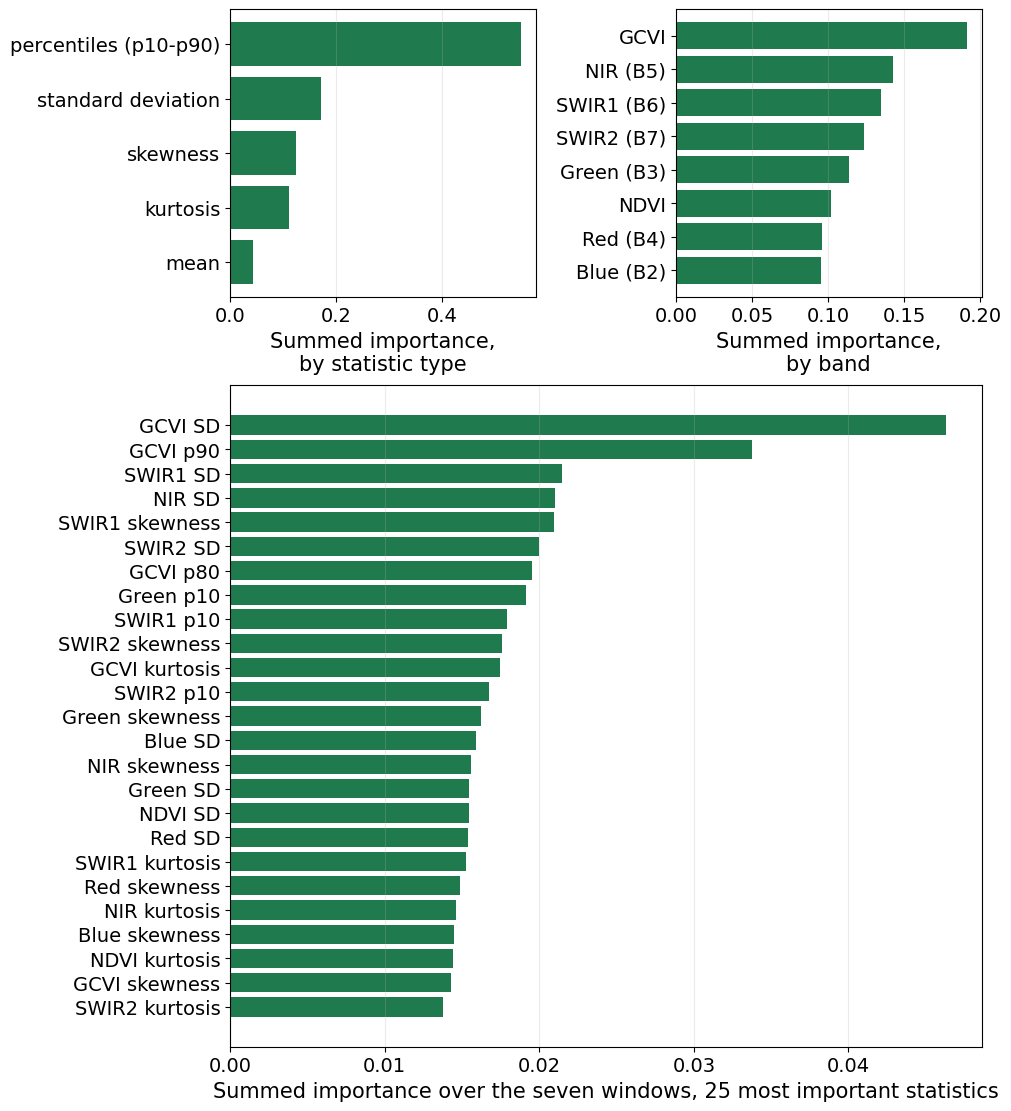

In [50]:
# E17 aggregates and figure (importances are shares of one, so they keep three or four decimals)
importance_by_statistic_type = e17_importances.groupby("statistic type")["importance"].sum().sort_values(ascending=False)
importance_by_band = e17_importances.groupby("band")["importance"].sum().sort_values(ascending=False)
importance_by_window = e17_importances.groupby("window")["importance"].sum()
importance_by_window.index = WINDOW_END_DATES
top_25_features = e17_importances.nlargest(25, "importance")[["feature", "importance"]]
# for the figure: each statistic of a band summed over the seven windows, so every label is unique
BAND_SHORT_NAMES = {"B2": "Blue", "B3": "Green", "B4": "Red", "B5": "NIR", "B6": "SWIR1", "B7": "SWIR2",
                    "NDVI": "NDVI", "GCVI": "GCVI"}
STATISTIC_SHORT_NAMES = {"mean": "mean", "stdDev": "SD", "skew": "skewness", "kurtosis": "kurtosis"}
importance_by_band_statistic = (e17_importances.groupby(["band", "statistic"])["importance"].sum()
                                .sort_values(ascending=False))
top_25_statistics = importance_by_band_statistic.head(25)
top_25_statistic_labels = [f"{BAND_SHORT_NAMES[band]} {STATISTIC_SHORT_NAMES.get(statistic, statistic)}"
                           for band, statistic in top_25_statistics.index]

print("by statistic type (percentiles are nine statistics per band, the other groups one each):")
display(importance_by_statistic_type.round(3).to_frame())
print("by band:")
display(importance_by_band.rename(index=BAND_NAMES).round(3).to_frame())
print("by window (end date):")
display(importance_by_window.round(3).to_frame())
display(top_25_features.round(4))
print("the 25 most important statistics, summed over the windows (the figure):")
display(pd.DataFrame({"statistic": top_25_statistic_labels, "importance": top_25_statistics.values}).round(4))
top_25_statistics.to_csv(os.path.join(experiment_folder("e17_rf_ranking_satellite"), "top_25_statistics_over_windows.csv"))
importance_by_statistic_type.to_csv(os.path.join(experiment_folder("e17_rf_ranking_satellite"), "by_statistic_type.csv"))
importance_by_band.to_csv(os.path.join(experiment_folder("e17_rf_ranking_satellite"), "by_band.csv"))

# two small rankings on top, the 25 single features below over the full width
figure = plt.figure(figsize=(10, 11), layout="constrained")
grid = figure.add_gridspec(2, 2, height_ratios=[1, 2.3])
axes = [figure.add_subplot(grid[0, 0]), figure.add_subplot(grid[0, 1]), figure.add_subplot(grid[1, :])]
axes[0].barh(importance_by_statistic_type.index, importance_by_statistic_type.values, color=SATELLITE_RANKING_COLOUR)
axes[0].invert_yaxis()
axes[0].set_xlabel("Summed importance,\nby statistic type")
axes[1].barh([BAND_NAMES[band] for band in importance_by_band.index], importance_by_band.values, color=SATELLITE_RANKING_COLOUR)
axes[1].invert_yaxis()
axes[1].set_xlabel("Summed importance,\nby band")
axes[2].barh(top_25_statistic_labels, top_25_statistics.values, color=SATELLITE_RANKING_COLOUR)
axes[2].invert_yaxis()
axes[2].set_xlabel("Summed importance over the seven windows, 25 most important statistics")
for axis in axes:
    axis.grid(axis="x", alpha=0.25)
save_figure(figure, "e17_rf_ranking_satellite", "satellite_ranking.png")

#### Correlation between the satellite statistics
The 104 statistics correlated with each other on the training seasons, with every window contributing a
row, so the correlations describe the statistics and not the season. The figure shows the 13 statistics
of a band against each other, averaged over the eight bands, every cell with its value. It shows which
candidates are near duplicates of each other, above all the percentiles of a band against its mean,
which is the reason the lean set keeps the mean and the standard deviation and drops the rest. The pair
counts below come from the full 104 x 104 matrix.

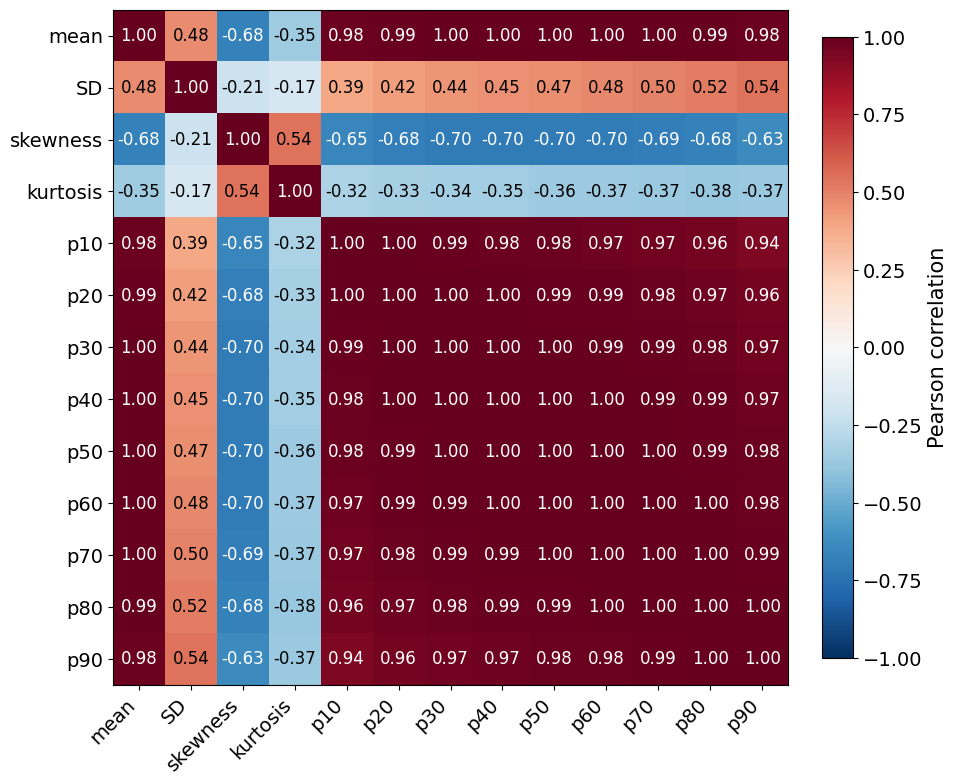

largest spread between the bands of one cell: 0.74
pairs with |r| >= 0.95: 501 of 5356


,statistic,other statistic,correlation
6196,B6_p40,B6_p50,0.999
736,B2_p40,B2_p50,0.999
841,B2_p50,B2_p60,0.999
631,B2_p30,B2_p40,0.999
6301,B6_p50,B6_p60,0.999
946,B2_p60,B2_p70,0.999
6091,B6_p30,B6_p40,0.999
3466,B4_p40,B4_p50,0.999
2206,B3_p50,B3_p60,0.999
6406,B6_p60,B6_p70,0.999


the mean of a band against its median and its standard deviation:


,band,mean against p50,mean against stdDev
0,B2,0.999,0.660
1,B3,0.999,0.629
2,B4,0.998,0.573
3,B5,0.998,0.286
4,B6,0.999,0.374
5,B7,0.998,0.473
6,NDVI,0.998,0.081
7,GCVI,0.998,0.726


In [51]:
# Correlation of the 104 statistics, training seasons only, windows stacked as rows
statistic_rows = pd.concat([county_year_features.loc[headline_split["is_train_row"],
                                                     [f"w{window:02d}_{name}" for name in ALL_STATISTIC_NAMES]]
                            .set_axis(ALL_STATISTIC_NAMES, axis=1) for window in range(N_WINDOWS)], ignore_index=True)
satellite_correlation = statistic_rows.corr()

# the 13 statistics of a band against each other, averaged over the eight bands
def draw_annotated_correlation(correlation, labels, folder_name, file_name, figure_size, font_size):
    """Correlation matrix with every value written into its cell."""
    figure, axis = plt.subplots(figsize=figure_size, layout="constrained")
    image = axis.imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)
    for row in range(len(labels)):
        for column in range(len(labels)):
            value = correlation[row, column]
            axis.text(column, row, f"{value:.2f}", ha="center", va="center", fontsize=font_size,
                      color="white" if abs(value) > 0.6 else "black")
    axis.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
    axis.set_yticks(range(len(labels)), labels)
    figure.colorbar(image, ax=axis, fraction=0.046, label="Pearson correlation")
    save_figure(figure, folder_name, file_name)


STATISTIC_ORDER = ["mean", "stdDev", "skew", "kurtosis"] + sorted(
    {name.split("_", 1)[1] for name in ALL_STATISTIC_NAMES} - {"mean", "stdDev", "skew", "kurtosis"},
    key=lambda suffix: int(suffix[1:]))
STATISTIC_DISPLAY_NAMES = {"mean": "mean", "stdDev": "SD", "skew": "skewness", "kurtosis": "kurtosis"}
per_band_correlation = np.array([satellite_correlation.loc[[f"{band}_{suffix}" for suffix in STATISTIC_ORDER],
                                                           [f"{band}_{suffix}" for suffix in STATISTIC_ORDER]].to_numpy()
                                 for band in BANDS])
statistic_correlation = per_band_correlation.mean(axis=0)
draw_annotated_correlation(statistic_correlation, [STATISTIC_DISPLAY_NAMES.get(suffix, suffix) for suffix in STATISTIC_ORDER],
                           "e17_rf_ranking_satellite", "satellite_correlation.png", figure_size=(9.5, 8.2), font_size=12)
pd.DataFrame(statistic_correlation, index=STATISTIC_ORDER, columns=STATISTIC_ORDER).round(3).to_csv(
    os.path.join(experiment_folder("e17_rf_ranking_satellite"), "statistic_correlation_mean_over_bands.csv"))
print(f"largest spread between the bands of one cell: {np.max(per_band_correlation.max(axis=0) - per_band_correlation.min(axis=0)):.2f}")

CORRELATION_THRESHOLD = 0.95
upper_triangle = np.triu(np.ones(satellite_correlation.shape, bool), k=1)
correlated_pairs = (satellite_correlation.where(upper_triangle).stack().rename("correlation").reset_index()
                    .rename(columns={"level_0": "statistic", "level_1": "other statistic"}))
correlated_pairs["absolute correlation"] = correlated_pairs.correlation.abs()
strong_pairs = correlated_pairs[correlated_pairs["absolute correlation"] >= CORRELATION_THRESHOLD].sort_values(
    "absolute correlation", ascending=False)
strong_pairs.round(3).to_csv(os.path.join(experiment_folder("e17_rf_ranking_satellite"), "correlated_statistic_pairs.csv"), index=False)
print(f"pairs with |r| >= {CORRELATION_THRESHOLD}: {len(strong_pairs)} of {int(upper_triangle.sum())}")
display(strong_pairs.head(15)[["statistic", "other statistic", "correlation"]].round(3))

mean_against_median = pd.DataFrame([{"band": band,
                                     "mean against p50": satellite_correlation.loc[f"{band}_mean", f"{band}_p50"],
                                     "mean against stdDev": satellite_correlation.loc[f"{band}_mean", f"{band}_stdDev"]}
                                    for band in BANDS])
print("the mean of a band against its median and its standard deviation:")
display(mean_against_median.round(3))

### 5.2 E18 — Random forest ranking of the soil properties
`Data_Asoil_data` (read only) holds the SoilGrids rasters downloaded per county: one file per
county and property. The properties downloaded for **every** county form the candidate set ranked
here; a few more properties exist for a handful of counties only (an earlier trial download) and are
not ranked. Each property is averaged over the county's raster, so these are **county-wide** means,
while the 18 properties the soil models use (marked in the figure) were later averaged over the
wheat cells only.

One row per county: its candidate soil means and its mean yield over the training seasons, matching
the reasoning that soil explains the long-run county level. Fixed hyperparameters, impurity
importances.

In [52]:
# E18: county means of every soil property downloaded for all counties, cached as parquet
E18_RANDOM_STATE = 0
E18_FOREST_SETTINGS = dict(n_estimators=500, max_features=0.33, min_samples_leaf=5)
SOIL_RASTER_FOLDER = os.path.join(ROOT, "Data_Asoil_data")
SOIL_RASTER_VARIABLE = "__xarray_dataarray_variable__"
soil_candidate_file = os.path.join(experiment_folder("e18_rf_ranking_soil"), "county_soil_candidates.parquet")


def county_raster_mean(file_path):
    """Mean of one county's soil raster, ignoring cells outside the county (NaN or fill values)."""
    with netCDF4.Dataset(file_path) as dataset:
        raster = dataset.variables[SOIL_RASTER_VARIABLE][:]
    values = np.ma.filled(raster.astype(np.float64), np.nan)
    if np.isnan(values).all():
        return np.nan
    return float(np.nanmean(values))


retained_properties = [column.replace("soil_", "").replace("_mean_1km", "") for column in soil_property_columns]
if not os.path.isdir(SOIL_RASTER_FOLDER):
    # PUBLISHED VERSION: the raw SoilGrids rasters are not part of the repository; the candidates are the
    # columns of the cached county means
    candidate_properties = [column for column in pd.read_parquet(soil_candidate_file).columns if column != "county_id"]
    assert set(retained_properties) <= set(candidate_properties), "a retained soil property is missing from the candidates"
    print(f"soil rasters not present, candidate properties from the cache: {len(candidate_properties)} | "
          f"retained by the soil models: {len(retained_properties)}")
else:
    soil_file_pattern = re.compile(r"^(\d+_\d+)_(.+)\.nc$")
    counties_by_property = {}
    for file_name in os.listdir(SOIL_RASTER_FOLDER):
        match = soil_file_pattern.match(file_name)
        if match is None or " copy" in file_name:
            continue
        counties_by_property.setdefault(match.group(2), set()).add(match.group(1))
    all_soil_counties = set().union(*counties_by_property.values())
    candidate_properties = sorted(name for name, counties in counties_by_property.items() if len(counties) == len(all_soil_counties))
    partial_properties = sorted(name for name, counties in counties_by_property.items() if len(counties) < len(all_soil_counties))
    assert set(retained_properties) <= set(candidate_properties), "a retained soil property is missing from the candidates"
    print(f"soil rasters: {len(all_soil_counties)} counties | candidate properties (all counties): {len(candidate_properties)} | "
          f"partial trial properties: {len(partial_properties)} (at most {max(len(counties_by_property[name]) for name in partial_properties)} counties) | "
          f"retained by the soil models: {len(retained_properties)}")

if os.path.exists(soil_candidate_file):
    county_soil_candidates = pd.read_parquet(soil_candidate_file)
    print("loaded cached county soil means")
else:
    start_time = time.time()
    soil_rows = []
    for position, soil_county_id in enumerate(sorted(all_soil_counties)):
        soil_row = {"county_id": soil_county_id}
        for property_name in candidate_properties:
            soil_row[property_name] = county_raster_mean(os.path.join(SOIL_RASTER_FOLDER, f"{soil_county_id}_{property_name}.nc"))
        soil_rows.append(soil_row)
        if (position + 1) % 100 == 0:
            print(f"  {position + 1}/{len(all_soil_counties)} counties ({time.time() - start_time:.0f}s)", flush=True)
    county_soil_candidates = pd.DataFrame(soil_rows)
    county_soil_candidates.to_parquet(soil_candidate_file, index=False)
county_soil_candidates["county_id"] = county_soil_candidates.county_id.astype(str)

soil rasters: 773 counties | candidate properties (all counties): 47 | partial trial properties: 29 (at most 12 counties) | retained by the soil models: 18
loaded cached county soil means


loaded cached importances
753 counties with training seasons and soil rasters, 47 candidate properties, forest {'n_estimators': 500, 'max_features': 0.33, 'min_samples_leaf': 5}, random_state=0


,soil property,importance,retained by the soil models,first of its group,duplicate of,correlation with it
0,ocd_0-5cm_mean,0.206,True,True,NaN,NaN
1,phh2o_30-60cm_mean,0.080,True,True,NaN,NaN
2,phh2o_30_100,0.067,False,False,pH 30-60 cm,1.00
3,sand_gradient_30_100_minus_0_30,0.063,True,True,NaN,NaN
4,phh2o_60-100cm_mean,0.045,False,False,pH 30-60 cm,0.99
5,phh2o_15-30cm_mean,0.041,False,False,pH 30-60 cm,0.98
6,soc_0-5cm_mean,0.038,True,True,NaN,NaN
7,clay_gradient_30_100_minus_0_30,0.033,True,True,NaN,NaN
8,bdod_0-5cm_mean,0.032,True,True,NaN,NaN
9,phh2o_0-5cm_mean,0.026,False,False,pH 30-60 cm,0.94


properties in bold in the figure are the ones the soil models use: the first of every group
ranks of the 18 retained properties among 47: [1, 2, 4, 7, 8, 9, 11, 13, 14, 15, 17, 18, 21, 22, 28, 35, 37, 38]
18 properties are the first of their group at |r| >= 0.85, 29 duplicate a better-ranked one


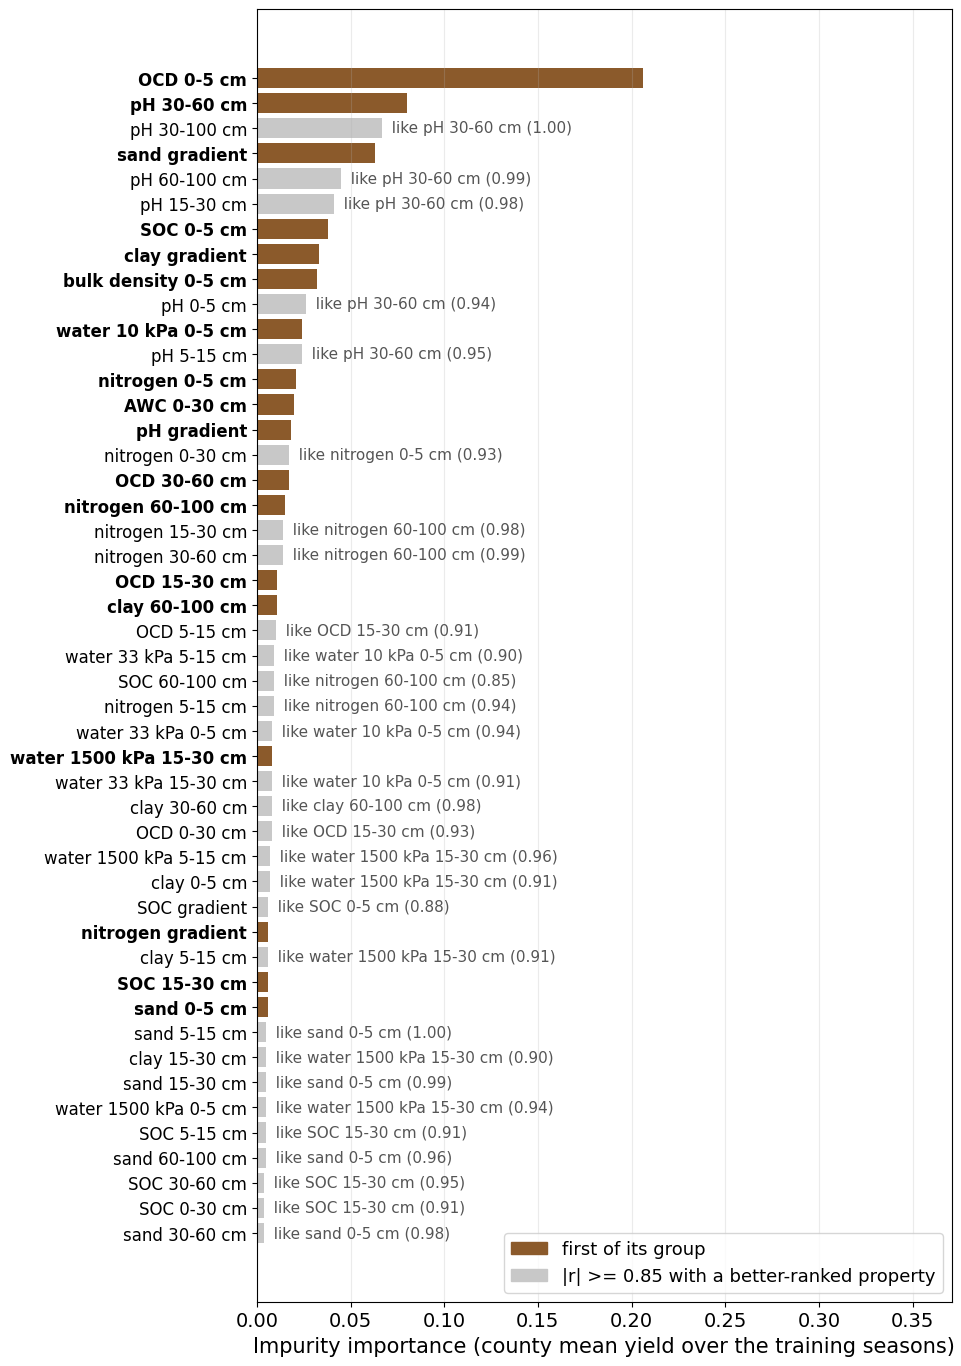

In [53]:
# E18 ranking and figure
e18_importance_file = os.path.join(experiment_folder("e18_rf_ranking_soil"), "feature_importances.csv")
training_rows = county_year_features[headline_split["is_train_row"]]
county_mean_yield = training_rows.groupby("county_id")["yield"].mean().rename("mean yield").reset_index()
county_level_table = county_mean_yield.merge(county_soil_candidates, on="county_id", how="inner")

if os.path.exists(e18_importance_file):
    e18_importances = pd.read_csv(e18_importance_file)
    print("loaded cached importances")
else:
    county_soil_values = np.array(county_level_table[candidate_properties], dtype=np.float32)
    county_yield_values = np.array(county_level_table["mean yield"], dtype=np.float64)
    forest = RandomForestRegressor(**E18_FOREST_SETTINGS, random_state=E18_RANDOM_STATE, n_jobs=-1)
    forest.fit(county_soil_values, county_yield_values)
    e18_importances = pd.DataFrame({"soil property": candidate_properties, "importance": forest.feature_importances_})
    e18_importances["retained by the soil models"] = e18_importances["soil property"].isin(retained_properties)
    e18_importances = e18_importances.sort_values("importance", ascending=False)
    e18_importances.to_csv(e18_importance_file, index=False)
print(f"{len(county_level_table)} counties with training seasons and soil rasters, {len(candidate_properties)} candidate "
      f"properties, forest {E18_FOREST_SETTINGS}, random_state={E18_RANDOM_STATE}")
e18_importances["retained by the soil models"] = e18_importances["soil property"].isin(retained_properties)
display(e18_importances.round(3))
print("properties in bold in the figure are the ones the soil models use: the first of every group")
retained_ranks = np.flatnonzero(e18_importances["retained by the soil models"].to_numpy()) + 1
print(f"ranks of the {len(retained_properties)} retained properties among {len(candidate_properties)}: {retained_ranks.tolist()}")

# readable names, also used by the correlation figure below
SOIL_PROPERTY_NAMES = {"ocd": "OCD", "soc": "SOC", "phh2o": "pH", "sand": "sand", "clay": "clay",
                       "nitrogen": "nitrogen", "bdod": "bulk density", "awc": "AWC", "wv0010": "water 10 kPa",
                       "wv0033": "water 33 kPa", "wv1500": "water 1500 kPa"}


def readable_soil_name(name):
    """phh2o_30-60cm_mean -> "pH 30-60 cm"; sand_gradient_30_100_minus_0_30 -> "sand gradient"."""
    soil_property, depth = name.split("_", 1)
    depth = depth.replace("_mean", "")
    if depth.startswith("gradient"):
        depth = "gradient"
    elif depth.endswith("cm"):
        depth = depth[:-2] + " cm"
    else:
        depth = depth.replace("_", "-") + " cm"
    return f"{SOIL_PROPERTY_NAMES[soil_property]} {depth}"


# which property is a near duplicate of a better-ranked one: walk down the ranking and keep a property
# only when it stays below the threshold against every property kept so far
SOIL_GROUP_THRESHOLD = 0.85
soil_correlation = county_level_table[candidate_properties].corr()
ranked_properties = e18_importances["soil property"].tolist()
first_of_group = []
duplicate_of = {}
for soil_property in ranked_properties:
    stronger = [kept for kept in first_of_group if abs(soil_correlation.loc[soil_property, kept]) >= SOIL_GROUP_THRESHOLD]
    if stronger:
        duplicate_of[soil_property] = max(stronger, key=lambda kept: abs(soil_correlation.loc[soil_property, kept]))
    else:
        first_of_group.append(soil_property)
e18_importances["first of its group"] = [name in set(first_of_group) for name in ranked_properties]
e18_importances["duplicate of"] = [readable_soil_name(duplicate_of[name]) if name in duplicate_of else ""
                                   for name in ranked_properties]
e18_importances["correlation with it"] = [round(abs(soil_correlation.loc[name, duplicate_of[name]]), 2)
                                          if name in duplicate_of else np.nan for name in ranked_properties]
e18_importances.round(3).to_csv(e18_importance_file, index=False)
print(f"{len(first_of_group)} properties are the first of their group at |r| >= {SOIL_GROUP_THRESHOLD}, "
      f"{len(duplicate_of)} duplicate a better-ranked one")
# the soil variants must use exactly these; build_soil_15.py writes their table from the same rule
assert set(retained_properties) == set(first_of_group), "the soil models do not use the first property of every group"

bar_colours = [SOIL_RANKING_COLOUR if first else "#c8c8c8"
               for first in e18_importances["first of its group"]]
figure, axis = plt.subplots(figsize=(9.5, 0.25 * len(e18_importances) + 1.8), layout="constrained")
axis.barh([readable_soil_name(name) for name in ranked_properties], e18_importances["importance"], color=bar_colours)
axis.invert_yaxis()
axis.set_xlabel("Impurity importance (county mean yield over the training seasons)")
axis.set_xlim(0, 1.8 * e18_importances["importance"].max())
axis.tick_params(axis="y", labelsize=12)
for position, name in enumerate(ranked_properties):
    if name in duplicate_of:
        axis.text(e18_importances["importance"].iloc[position], position,
                  f"  like {readable_soil_name(duplicate_of[name])} ({abs(soil_correlation.loc[name, duplicate_of[name]]):.2f})",
                  va="center", fontsize=11, color="#555555")
for label, name in zip(axis.get_yticklabels(), ranked_properties):
    if name in retained_properties:
        label.set_fontweight("bold")
axis.legend(handles=[Patch(color=SOIL_RANKING_COLOUR, label="first of its group"),
                     Patch(color="#c8c8c8", label=f"|r| >= {SOIL_GROUP_THRESHOLD} with a better-ranked property")],
            loc="lower right")
axis.grid(axis="x", alpha=0.25)
save_figure(figure, "e18_rf_ranking_soil", "soil_ranking.png")

#### Correlation between the soil properties
The 47 candidates correlated with each other over the counties. Soil properties of neighbouring depth
intervals describe almost the same thing, which is why a ranking of the candidates alone cannot decide
which of them to keep. The figure shows the 18 properties the soil features use, every cell with its
value; the pair counts below come from all 47.

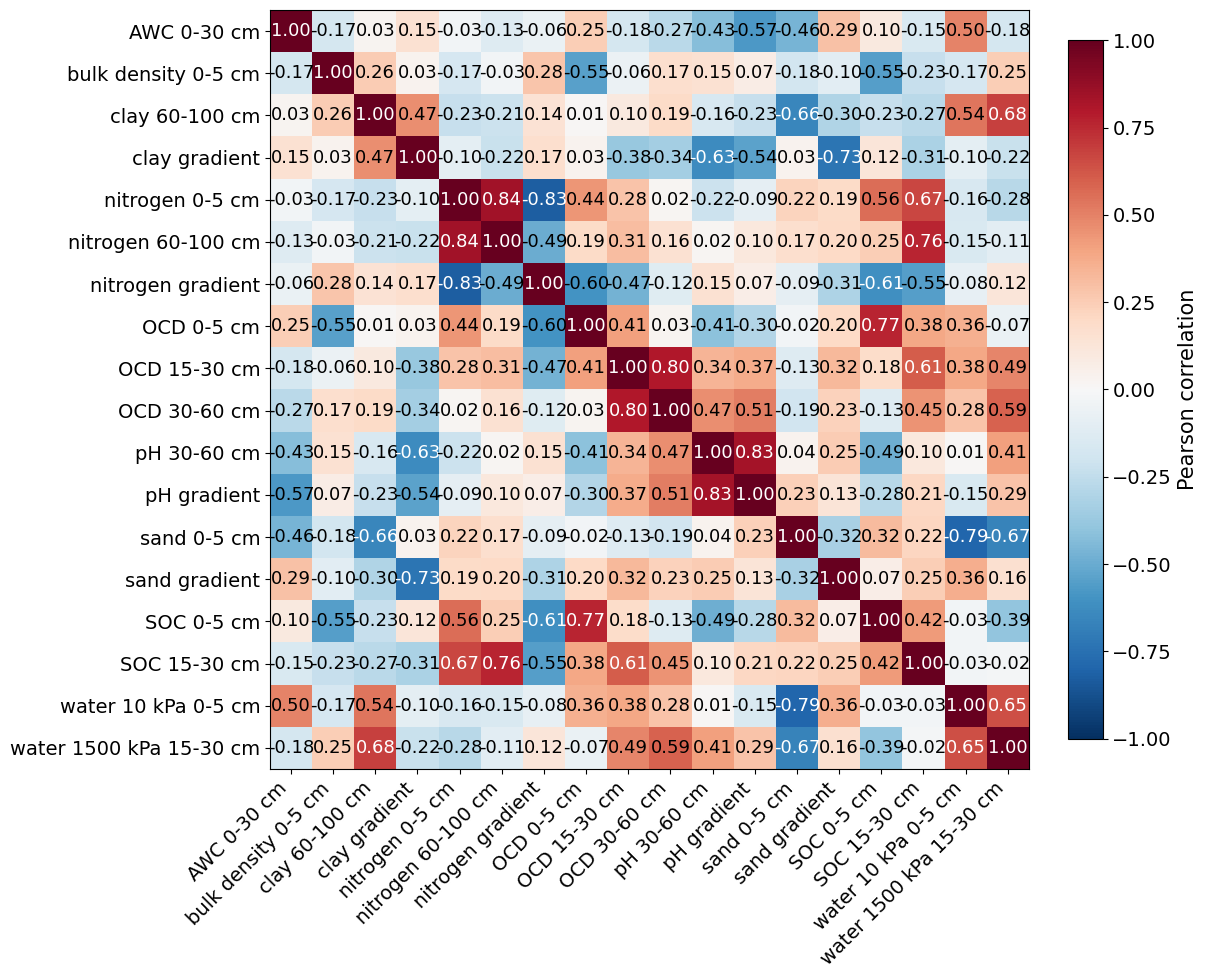

soil pairs with |r| >= 0.95: 40 of 1081 (properties in bold in the figure are the ones the soil models use)


,property,other property,correlation
1299,sand_0-5cm_mean,sand_5-15cm_mean,0.999
1106,phh2o_30_100,phh2o_60-100cm_mean,0.998
964,phh2o_0-5cm_mean,phh2o_5-15cm_mean,0.996
1346,sand_15-30cm_mean,sand_5-15cm_mean,0.996
1057,phh2o_30-60cm_mean,phh2o_30_100,0.995
1297,sand_0-5cm_mean,sand_15-30cm_mean,0.995
530,nitrogen_30-60cm_mean,nitrogen_60-100cm_mean,0.993
99,clay_0-5cm_mean,clay_5-15cm_mean,0.992
1345,sand_15-30cm_mean,sand_30-60cm_mean,0.991
1011,phh2o_15-30cm_mean,phh2o_5-15cm_mean,0.989


In [54]:
# Correlation of the 47 soil candidates over the counties (the matrix of the ranking cell)
def soil_order_key(name):
    soil_property, depth = name.split("_", 1)
    first_number = int(depth.replace("-", "_").split("_")[0]) if depth[0].isdigit() else 999
    return (soil_property, first_number, depth)


retained_in_order = sorted(retained_properties, key=soil_order_key)
retained_correlation = county_level_table[retained_in_order].corr().to_numpy()
draw_annotated_correlation(retained_correlation, [readable_soil_name(name) for name in retained_in_order],
                           "e18_rf_ranking_soil", "soil_correlation.png", figure_size=(12, 10.5), font_size=13)

upper_triangle = np.triu(np.ones(soil_correlation.shape, bool), k=1)
soil_pairs = (soil_correlation.where(upper_triangle).stack().rename("correlation").reset_index()
              .rename(columns={"level_0": "property", "level_1": "other property"}))
soil_pairs["absolute correlation"] = soil_pairs.correlation.abs()
strong_soil_pairs = soil_pairs[soil_pairs["absolute correlation"] >= CORRELATION_THRESHOLD].sort_values(
    "absolute correlation", ascending=False)
strong_soil_pairs.round(3).to_csv(os.path.join(experiment_folder("e18_rf_ranking_soil"), "correlated_soil_pairs.csv"), index=False)
print(f"soil pairs with |r| >= {CORRELATION_THRESHOLD}: {len(strong_soil_pairs)} of {int(upper_triangle.sum())} "
      f"(properties in bold in the figure are the ones the soil models use)")
display(strong_soil_pairs.head(15)[["property", "other property", "correlation"]].round(3))

### Reading, section 5
Impurity importances, so correlated candidates share their importance. That is what the correlation
matrices are for.

- **Satellite statistics (E17).** By summed importance the percentiles hold 55 %, the standard deviation
  17 %, skewness 12 %, kurtosis 11 % and the mean 4 %. Per statistic the picture reverses: the percentiles
  are nine of the thirteen statistics of a band, so each one carries less than its share, while the
  standard deviation carries about twice its share. GCVI is the strongest band (19 %), followed by NIR
  (B5) and SWIR1 (B6) with 14 % each.
- **Correlation between the statistics.** 501 of the 5,356 pairs reach |r| ≥ 0.95. Neighbouring percentiles
  of a band are near-identical (up to 0.999) and the mean of a band correlates at 0.999 with its median.
  The low importance of the mean is therefore redundancy, not absence of information, and keeping the mean
  and the standard deviation per band loses little of what the percentiles carry.
- **Soil properties (E18).** Organic carbon density in the top 5 cm dominates (21 %), followed by pH at
  30–60 cm and 30–100 cm and the sand gradient. 29 of the 47 candidates correlate at |r| >= 0.85 with a
  better-ranked one, above all the four other pH layers, which leaves the 18 properties the soil variants
  use, one per group.
- **Correlation between the soil properties.** 40 of the 1,081 pairs reach |r| ≥ 0.95, and they are the
  neighbouring depth intervals of the same property, such as sand at 0–5 cm against 5–15 cm (0.999) or the
  pH layers among each other. A ranking alone cannot decide which depth to keep, which is why the retained
  set contains gradients rather than every layer.

## Appendix
Experiments that the thesis does not use. They run exactly as before, against the same E7 reference and
with the same noise rule, and their figures carry the prefix `A-`.

### A.1 The plain transformer (from `04`)
The plain transformer on all 104 statistics of the 20-day windows: one encoder layer of width 64,
attention pooling, the history branch and the head, without the lean token set, the cross-attention
block and the coverage. It quantifies what those design choices are worth together, against the
headline configuration (E7) and the history-only baseline. 30 models.

,model,282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%),against E7
0,baseline,0.77,0.62,0.70,18.0,0.76,0.61,0.68,16.9,higher RMSE (+0.259)
1,"plain transformer, 104 statistics",0.52,0.40,0.86,12.2,0.56,0.44,0.83,12.5,higher RMSE (+0.010)
2,"Transformer, headline configuration (E7)",0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4,reference
3,"Transformer, headline of 01",0.51,0.39,0.87,11.9,0.56,0.44,0.83,12.5,within noise (-0.002)


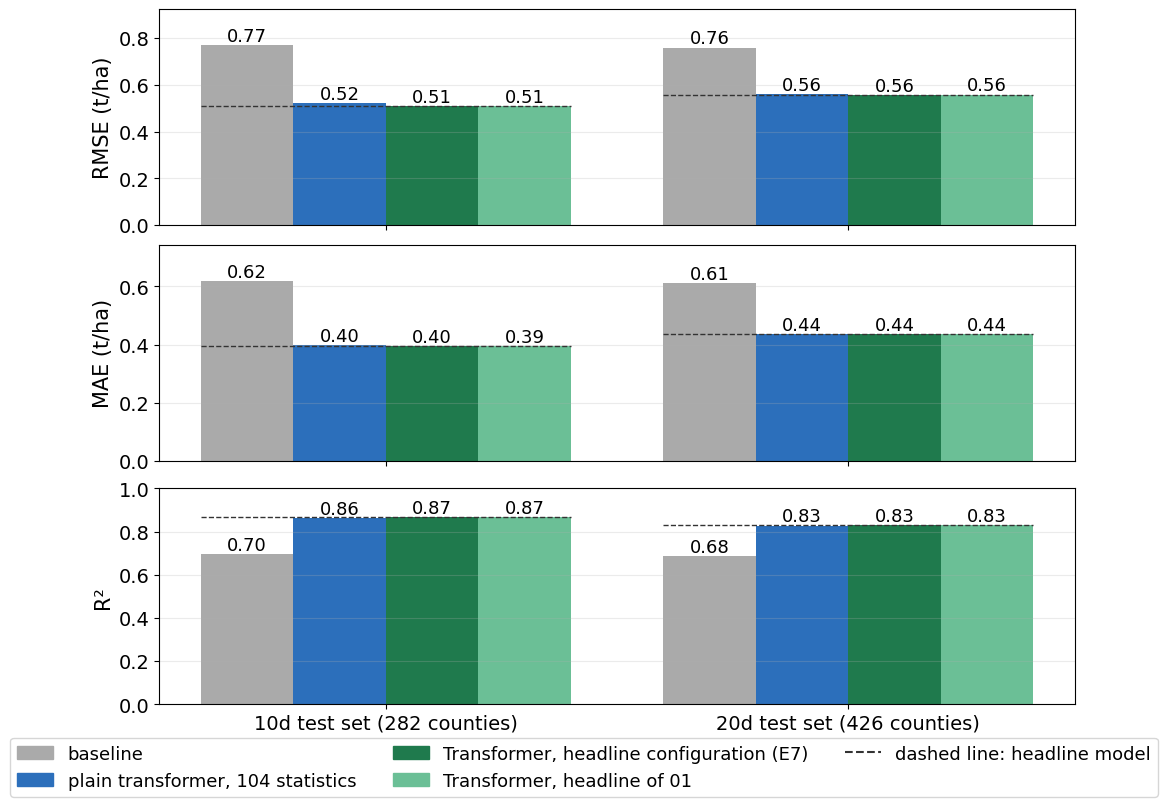

In [55]:
# The plain transformer of 04 against the headline configuration and the history-only baseline
N_MODELS_PLAIN_BASELINE = N_MODELS_PER_ENSEMBLE

full_tokens_20d = standardize_tokens(build_statistic_tokens(county_year_features, ALL_STATISTIC_NAMES),
                                     headline_split["is_train_row"])


def train_plain_model(tokens, split, seed):
    """One plain window transformer (notebooks 03 and 04) with the headline protocol."""
    return train_neural_model(
        build_model=lambda: PlainWindowTransformer(tokens.shape[2], tokens.shape[1]),
        input_arrays=[tokens, split["yield_history"][:, None]],
        split=split, seed=seed)


# the folder name is the one of the earlier version of this experiment, so its models are reused
_, plain_baseline_bank = load_or_train_bank(
    "ten_day_track_20d_all_county_years", N_MODELS_PLAIN_BASELINE,
    lambda seed: train_plain_model(full_tokens_20d, headline_split, seed))
plain_baseline_prediction = plain_baseline_bank.mean(axis=0)
PLAIN_REFERENCE = "Transformer, headline configuration (E7)"
plain_models = {
    BASELINE_NAME: (yield_history_test, MODEL_COLOURS["history only"]),
    "plain transformer, 104 statistics": (plain_baseline_prediction, MODEL_COLOURS["plain transformer"]),
    PLAIN_REFERENCE: (e07_test_ensemble, MODEL_COLOURS["headline transformer"]),
    "Transformer, headline of 01": (headline_ensemble, MODEL_COLOURS["headline of 01"]),
}
plain_rows = []
for name, (prediction, _) in plain_models.items():
    if name == PLAIN_REFERENCE:
        verdict = "reference"
    else:
        verdict = noise_verdict(headline_rmse(prediction), headline_rmse(e07_test_ensemble))
    plain_rows.append({"model": name, **test_table_columns(prediction), "against E7": verdict})
plain_table = pd.DataFrame(plain_rows)
plain_table.to_csv(os.path.join(experiment_folder("section2_plain_baseline"), "results.csv"), index=False)
display(plain_table)

record_in_summary("A.1", "plain transformer, 104 statistics", plain_baseline_prediction, models=N_MODELS_PLAIN_BASELINE)
record_single_models("A.1", "plain transformer, 104 statistics", test_bank=plain_baseline_bank,
                     colour=MODEL_COLOURS["plain transformer"])

plot_bars_by_test_set({name: values[0] for name, values in plain_models.items()},
                      {name: values[1] for name, values in plain_models.items()},
                      "section2_plain_baseline", "plain_transformer.png", reference_name=PLAIN_REFERENCE,
                      reference_legend_label="headline model")

### A.2 Shared against separate key/value registers (repeated from `02` at the headline width)
The headline passes one learned tensor as both key and value of the cross-attention block. This
variant gives keys and values their own parameter tensors. Both span the same function class, so any
difference reflects optimisation, not capacity. 30 models, against E7.

In [56]:
# Separate key/value registers at the headline width
N_MODELS_KEY_VALUE_CHECK = N_MODELS_PER_ENSEMBLE

_, separate_key_value_bank = load_or_train_bank(
    f"register_separate_key_value_{HEADLINE_WIDTH_TAG}", N_MODELS_KEY_VALUE_CHECK,
    lambda seed: train_neural_model(
        build_model=lambda: SeparateKeyValueRegisterPredictor(lean_tokens_headline.shape[2]),
        input_arrays=[lean_tokens_headline, history_headline, coverage_headline, soil_values_standardized],
        split=headline_split, seed=seed))
separate_key_value_prediction = separate_key_value_bank.mean(axis=0)

,parameterisation,282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%)
0,shared key/value (headline),0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4
1,separate key/value,0.51,0.39,0.87,11.9,0.55,0.43,0.83,12.4


separate against shared: within noise (-0.003)


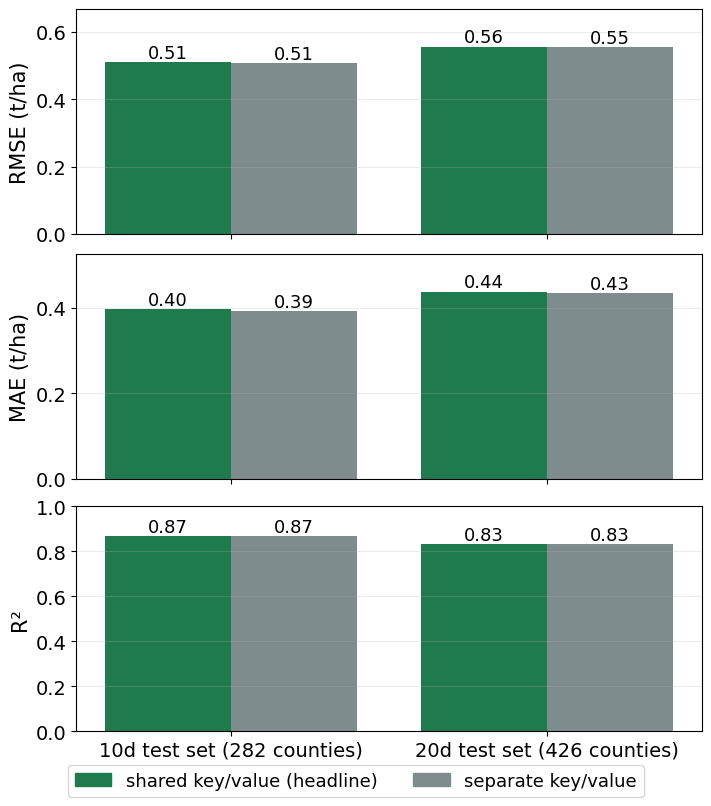

In [57]:
# Shared (headline configuration, E7) against separate key/value
key_value_arms = {"shared key/value (headline)": e07_test_ensemble,
                  "separate key/value": separate_key_value_prediction}
key_value_table = pd.DataFrame([{"parameterisation": name, **test_table_columns(prediction)}
                                for name, prediction in key_value_arms.items()])
key_value_table.to_csv(os.path.join(experiment_folder("section2_key_value"), "results.csv"), index=False)
display(key_value_table)
print(f"separate against shared: {noise_verdict(headline_rmse(separate_key_value_prediction), headline_rmse(e07_test_ensemble))}")
record_in_summary("A.2", "separate key/value registers", separate_key_value_prediction, models=N_MODELS_KEY_VALUE_CHECK)
record_single_models("A.2", "separate key/value registers", test_bank=separate_key_value_bank)

plot_bars_by_test_set(key_value_arms,
                      {"shared key/value (headline)": MODEL_COLOURS["headline transformer"],
                       "separate key/value": MODEL_COLOURS["variant"]},
                      "section2_key_value", "key_value.png")

### A.3 Cell structure (E15) and the averaged cell standard deviation (E16)
Both need statistics the 20-day table does not keep, so the windows are rebuilt from the per-cell
exports in `Data_Fused_{year}` (read only), with the rules of the root `preprocessing.ipynb`:
20-day windows from 7 April, the last full window ending 24 August, every statistic a
pixel-weighted mean over the cell observations of the window (weight = the `B3_count` column, as
there), an isolated empty window filled from its neighbours, an edge gap or two adjacent gaps
dropping the county-year.

For each window and band, over all cell observations *i* with pixel count *n*, cell mean *m* and
cell standard deviation *s* (population values: single-pixel cells carry exactly 0):

| quantity | formula | used by |
|---|---|---|
| county mean | Σ *n·m* / N | the stored mean, sanity check |
| county std | √(Σ *n·(s² + m²)* / N − mean²) | the stored `stdDev` since the preprocessing fix, sanity check |
| mean cell std | Σ *n·s* / N | **E16**: what the earlier preprocessing stored as `stdDev` |
| between-cell std | √(Σ *n·m²* / N − mean²) | **E15**: spread of the cell means across the county |

Percentiles cannot be recovered this way, because raw pixels were never exported.

In [58]:
# Rebuild per-window cell statistics from the per-cell exports (about 70 GB of CSV, cached as parquet)
FUSED_YEARS = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2025]
SEASON_START = pd.Timestamp(2000, 4, 7)       # dates carry no year; the root preprocessing uses a dummy year too
WINDOW_LENGTH_DAYS = 20
WEIGHT_COLUMN = "B3_count"                     # the root preprocessing weights every column by the second count column
CELL_STATISTIC_KINDS = ["mean", "mean_cell_std", "between_cell_std", "county_std"]
CELL_STATISTICS_FILE = os.path.join(experiment_folder("e15_e16_cell_statistics"), "county_window_cell_statistics.parquet")


def apply_gap_rule(county_windows):
    """Fill an isolated empty window with the mean of its neighbours. Return None when a gap sits at
    the edge of the season or next to another gap, which drops the county-year."""
    value_columns = [c for c in county_windows.columns if c not in ("window", "observations")]
    is_empty_window = (county_windows["observations"] == 0).to_numpy()
    for window in range(N_WINDOWS):
        if not is_empty_window[window]:
            continue
        if window == 0 or window == N_WINDOWS - 1:
            return None
        if is_empty_window[window - 1] or is_empty_window[window + 1]:
            return None
        neighbour_average = (county_windows.loc[window - 1, value_columns].to_numpy(np.float64)
                             + county_windows.loc[window + 1, value_columns].to_numpy(np.float64)) / 2.0
        county_windows.loc[window, value_columns] = neighbour_average
    return county_windows


def summarize_fused_county_file(file_path):
    """Per-window pixel-weighted cell statistics of one county-year (7 rows), or None if dropped."""
    columns_needed = ["date", WEIGHT_COLUMN] + [f"{band}_mean" for band in BANDS] + [f"{band}_stdDev" for band in BANDS]
    cell_observations = pd.read_csv(file_path, usecols=columns_needed, dtype={"date": str}, engine="pyarrow")

    day_and_month = cell_observations["date"].str.split(".", expand=True)
    observation_dates = pd.to_datetime(pd.DataFrame({"year": 2000,
                                                     "month": day_and_month[1].astype(int),
                                                     "day": day_and_month[0].astype(int)}))
    days_since_season_start = (observation_dates - SEASON_START).dt.days.to_numpy()
    window_of_observation = np.where(days_since_season_start >= 0, days_since_season_start // WINDOW_LENGTH_DAYS, -1)
    pixel_count = cell_observations[WEIGHT_COLUMN].to_numpy(np.float64)

    window_rows = []
    for window in range(N_WINDOWS):
        is_in_window = window_of_observation == window
        window_row = {"window": window, "observations": int(is_in_window.sum())}
        for band in BANDS:
            cell_mean = cell_observations[f"{band}_mean"].to_numpy(np.float64)
            cell_std = cell_observations[f"{band}_stdDev"].to_numpy(np.float64)
            is_valid = is_in_window & ~np.isnan(cell_mean) & ~np.isnan(cell_std) & (pixel_count > 0)
            if is_valid.any():
                weight = pixel_count[is_valid]
                total_pixels = weight.sum()
                county_mean = np.sum(weight * cell_mean[is_valid]) / total_pixels
                mean_cell_std = np.sum(weight * cell_std[is_valid]) / total_pixels
                within_cell_variance = np.sum(weight * cell_std[is_valid] ** 2) / total_pixels
                between_cell_variance = max(np.sum(weight * cell_mean[is_valid] ** 2) / total_pixels - county_mean ** 2, 0.0)
                window_row[f"{band}_mean"] = county_mean
                window_row[f"{band}_mean_cell_std"] = mean_cell_std
                window_row[f"{band}_between_cell_std"] = np.sqrt(between_cell_variance)
                window_row[f"{band}_county_std"] = np.sqrt(within_cell_variance + between_cell_variance)
            else:
                for kind in CELL_STATISTIC_KINDS:
                    window_row[f"{band}_{kind}"] = np.nan
        window_rows.append(window_row)
    return apply_gap_rule(pd.DataFrame(window_rows))


def build_cell_statistics_table():
    """One row per county-year and window, for every county-year the gap rule keeps."""
    county_tables = []
    for fused_year in FUSED_YEARS:
        start_time = time.time()
        file_paths = sorted(glob.glob(os.path.join(ROOT, f"Data_Fused_{fused_year}", "Harvester_*.csv")))
        with ThreadPoolExecutor(max_workers=8) as executor:
            county_summaries = list(executor.map(summarize_fused_county_file, file_paths))
        kept_county_years = 0
        for file_path, county_windows in zip(file_paths, county_summaries):
            if county_windows is None:
                continue
            name_parts = os.path.basename(file_path)[:-len(".csv")].split("_")
            county_windows.insert(0, "county_id", f"{name_parts[2]}_{name_parts[3]}")
            county_windows.insert(1, "year", fused_year)
            county_tables.append(county_windows)
            kept_county_years += 1
        print(f"  {fused_year}: {len(file_paths)} files, {kept_county_years} kept by the gap rule"
              f" ({time.time() - start_time:.0f}s)", flush=True)
    return pd.concat(county_tables, ignore_index=True)


if os.path.exists(CELL_STATISTICS_FILE):
    cell_statistics = pd.read_parquet(CELL_STATISTICS_FILE)
    print("loaded cached cell statistics")
else:
    print("rebuilding window statistics from Data_Fused (read only) ...", flush=True)
    cell_statistics = build_cell_statistics_table()
    cell_statistics.to_parquet(CELL_STATISTICS_FILE, index=False)
cell_statistics["county_id"] = cell_statistics.county_id.astype(str)
print(f"cell statistics: {cell_statistics.groupby(['county_id', 'year']).ngroups} county-years")

loaded cached cell statistics
cell statistics: 4120 county-years


In [59]:
# Sanity checks against the 20-day table, then the E15 and E16 token sets
def aligned_cell_statistic(kind):
    """(county-years, windows, bands) array of one rebuilt statistic, in county_year_features row order."""
    row_keys = county_year_features[["county_id", "year"]]
    columns = [f"{band}_{kind}" for band in BANDS]
    statistic_per_window = []
    for window in range(N_WINDOWS):
        window_rows = cell_statistics[cell_statistics.window == window]
        aligned_rows = row_keys.merge(window_rows[["county_id", "year"] + columns], on=["county_id", "year"], how="left")
        statistic_per_window.append(aligned_rows[columns].to_numpy(np.float64))
    return np.stack(statistic_per_window, axis=1)


rebuilt_county_years = set(zip(cell_statistics.county_id, cell_statistics.year))
missing_county_years = [key for key in zip(county_id, year) if key not in rebuilt_county_years]
assert len(missing_county_years) == 0, f"{len(missing_county_years)} county-years of the 20-day table were not rebuilt"
print(f"every county-year of the 20-day table was rebuilt "
      f"({len(rebuilt_county_years) - n_county_years} more exist without a yield label)")

rebuilt_mean = aligned_cell_statistic("mean")
rebuilt_county_std = aligned_cell_statistic("county_std")
existing_mean = build_statistic_tokens(county_year_features, [f"{band}_mean" for band in BANDS])
existing_std = build_statistic_tokens(county_year_features, [f"{band}_stdDev" for band in BANDS])
means_match = np.allclose(rebuilt_mean, existing_mean, rtol=1e-4, atol=1e-6, equal_nan=False)
stds_match = np.allclose(rebuilt_county_std, existing_std, rtol=1e-4, atol=1e-6, equal_nan=False)
print(f"rebuilt means equal the stored means: {means_match} "
      f"(largest absolute difference {np.max(np.abs(rebuilt_mean - existing_mean)):.2e})")
print(f"rebuilt county std equals the stored stdDev: {stds_match} "
      f"(largest absolute difference {np.max(np.abs(rebuilt_county_std - existing_std)):.2e})")
assert means_match and stds_match, "the rebuild does not reproduce the 20-day table"

rebuilt_mean_cell_std = aligned_cell_statistic("mean_cell_std").astype(np.float32)
rebuilt_between_cell_std = aligned_cell_statistic("between_cell_std").astype(np.float32)

# E16 tokens: the lean builder on a copy of the table whose stdDev columns hold the averaged cell std
features_with_averaged_cell_std = county_year_features.copy()
for window in range(N_WINDOWS):
    for band_position, band in enumerate(BANDS):
        features_with_averaged_cell_std[f"w{window:02d}_{band}_stdDev"] = rebuilt_mean_cell_std[:, window, band_position]
lean_tokens_averaged_cell_std = standardize_tokens(build_lean_tokens(features_with_averaged_cell_std), headline_split["is_train_row"])

# E15 tokens: the lean tokens plus the between-cell spread of the 8 bands
tokens_with_cell_spread = standardize_tokens(np.concatenate([lean_tokens_raw, rebuilt_between_cell_std], axis=2),
                                             headline_split["is_train_row"])

# how much wider the exact county standard deviation is than the averaged cell standard deviation
# (windows with an averaged value of 0 give inf or NaN and are ignored by the median)
with np.errstate(divide="ignore", invalid="ignore"):
    county_std_ratio = existing_std / rebuilt_mean_cell_std
    between_cell_std_ratio = rebuilt_between_cell_std / rebuilt_mean_cell_std
std_ratio = pd.DataFrame({
    "band": BANDS,
    "median county std / averaged cell std": np.nanmedian(county_std_ratio, axis=(0, 1)),
    "median between-cell std / averaged cell std": np.nanmedian(between_cell_std_ratio, axis=(0, 1)),
})
display(std_ratio.round(2))
print(f"E15 tokens {tokens_with_cell_spread.shape[2]} values per window | E16 tokens {lean_tokens_averaged_cell_std.shape[2]}")

every county-year of the 20-day table was rebuilt (0 more exist without a yield label)
rebuilt means equal the stored means: True (largest absolute difference 4.75e-07)
rebuilt county std equals the stored stdDev: True (largest absolute difference 1.42e-06)


,band,median county std / averaged cell std,median between-cell std / averaged cell std
0,B2,1.73,1.31
1,B3,1.72,1.31
2,B4,1.70,1.29
3,B5,1.72,1.32
4,B6,1.74,1.35
5,B7,1.73,1.32
6,NDVI,1.64,1.21
7,GCVI,1.66,1.21


E15 tokens 35 values per window | E16 tokens 27


#### E16 — The averaged cell standard deviation of the earlier preprocessing
Identical to the headline except that the eight `stdDev` values per window are the pixel-weighted mean
of the cell standard deviations, as the preprocessing computed them before the fix, instead of the
exact county standard deviation. Means, indices and deltas are unchanged. 30 models.

In [60]:
# E16
N_MODELS_E16 = N_MODELS_PER_ENSEMBLE

e16_validation_bank, e16_test_bank = load_or_train_bank(
    f"e16_averaged_cell_std_{HEADLINE_WIDTH_TAG}", N_MODELS_E16,
    lambda seed: train_headline_model(lean_tokens_averaged_cell_std, coverage_headline, headline_split, seed))

#### E15 — Cell structure
Does variation *between* cells carry information the county mean discards? The headline tokens
plus, per window and band, the spread of the cell means across the county (35 values per window),
fed to the headline transformer. 30 models, compared with E7 on identical county-years.

In [61]:
# E15
N_MODELS_E15 = N_MODELS_PER_ENSEMBLE

e15_validation_bank, e15_test_bank = load_or_train_bank(
    f"e15_cell_spread_{HEADLINE_WIDTH_TAG}", N_MODELS_E15,
    lambda seed: train_headline_model(tokens_with_cell_spread, coverage_headline, headline_split, seed))

,variant,values per window,validation 2023 RMSE (t/ha),282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%),against the headline
0,headline configuration (E7),27,0.66,0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4,reference
1,E15 plus between-cell spread,35,0.66,0.51,0.39,0.87,11.9,0.55,0.43,0.83,12.3,within noise (+0.000)
2,E16 averaged cell standard deviation,27,0.66,0.52,0.40,0.86,12.2,0.56,0.44,0.83,12.5,higher RMSE (+0.010)


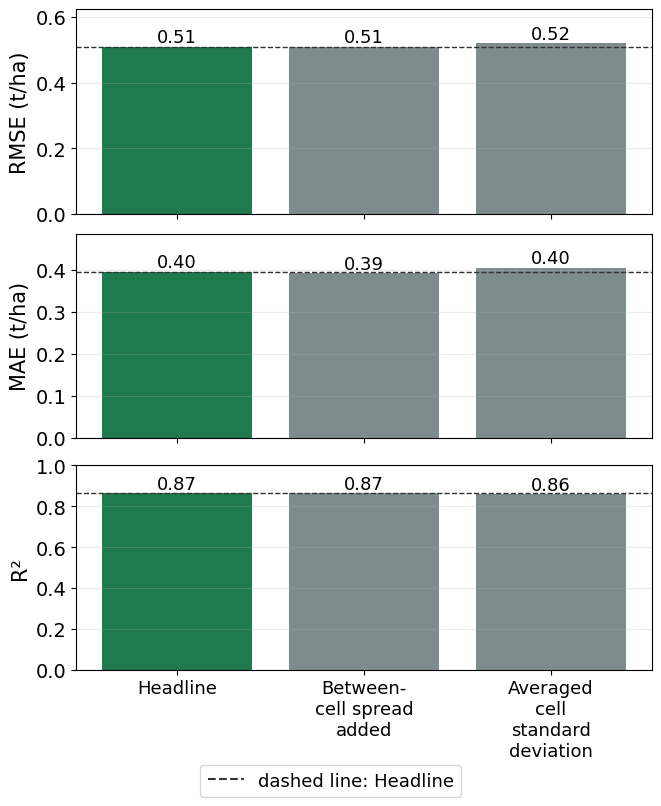

In [62]:
# A.3 results: the cell structure (E15) and the averaged cell standard deviation (E16) against E7
appendix_cell_variants = {
    "headline configuration (E7)": ("Headline", e07_validation_ensemble, e07_test_ensemble, e07_test_bank[:N_MODELS_PER_ENSEMBLE],
                                    lean_tokens_headline.shape[2]),
    "E15 plus between-cell spread": ("Between-cell spread added", e15_validation_bank.mean(axis=0), e15_test_bank.mean(axis=0),
                                     e15_test_bank, tokens_with_cell_spread.shape[2]),
    "E16 averaged cell standard deviation": ("Averaged cell standard deviation", e16_validation_bank.mean(axis=0),
                                             e16_test_bank.mean(axis=0), e16_test_bank, lean_tokens_averaged_cell_std.shape[2]),
}
appendix_cell_rows = []
for variant_name, (_, validation_prediction, test_prediction, test_bank, values_per_window) in appendix_cell_variants.items():
    if variant_name.startswith("headline"):
        verdict = "reference"
    else:
        verdict = noise_verdict(headline_rmse(test_prediction), headline_rmse(e07_test_ensemble))
        record_in_summary("A.3", variant_name, test_prediction, models=N_MODELS_PER_ENSEMBLE)
        record_single_models("A.3", variant_name, test_bank=test_bank)
    appendix_cell_rows.append({"variant": variant_name, "values per window": values_per_window,
                               "validation 2023 RMSE (t/ha)": validation_rmse_t_per_ha(validation_prediction),
                               **test_table_columns(test_prediction), "against the headline": verdict})
appendix_cell_table = pd.DataFrame(appendix_cell_rows)
appendix_cell_table.to_csv(os.path.join(experiment_folder("appendix_cell_statistics"), "results.csv"), index=False)
display(appendix_cell_table)

appendix_cell_colours = {figure_name: MODEL_COLOURS["variant"] for figure_name, *_ in appendix_cell_variants.values()}
appendix_cell_colours["Headline"] = MODEL_COLOURS["headline transformer"]
plot_prediction_bars({figure_name: test_prediction for figure_name, _, test_prediction, _, _ in appendix_cell_variants.values()},
                     appendix_cell_colours, "appendix_cell_statistics", "cell_statistics.png", cohorts=("headline",),
                     reference_name="Headline")

### A.4 E20 — Without the six derived indices only
The six indices computed from the window means leave the token; NDVI and GCVI stay as bands with their
statistics and deltas, 21 values per window. 30 models. The variant without any index information
(E20b) is section 4.4.

In [63]:
# E20
tokens_without_indices = standardize_tokens(lean_tokens_raw[:, :, BAND_STATISTIC_POSITIONS + DELTA_POSITIONS],
                                            headline_split["is_train_row"])
e20_validation_bank, e20_test_bank = load_or_train_bank(
    f"e20_no_spectral_indices_{HEADLINE_WIDTH_TAG}", N_MODELS_E20,
    lambda seed: train_headline_model(tokens_without_indices, coverage_headline, headline_split, seed))
print(f"E20 tokens: {tokens_without_indices.shape[2]} values per window (derived indices dropped)")

E20 tokens: 21 values per window (derived indices dropped)


,variant,validation 2023 RMSE (t/ha),282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%),against the headline
0,headline configuration (E7),0.66,0.51,0.40,0.87,11.9,0.56,0.44,0.83,12.4,reference
1,E20 without derived spectral indices,0.65,0.51,0.39,0.87,11.9,0.56,0.43,0.83,12.4,within noise (+0.000)
2,E20b without any index information,0.66,0.51,0.39,0.87,11.9,0.55,0.43,0.84,12.2,within noise (-0.003)


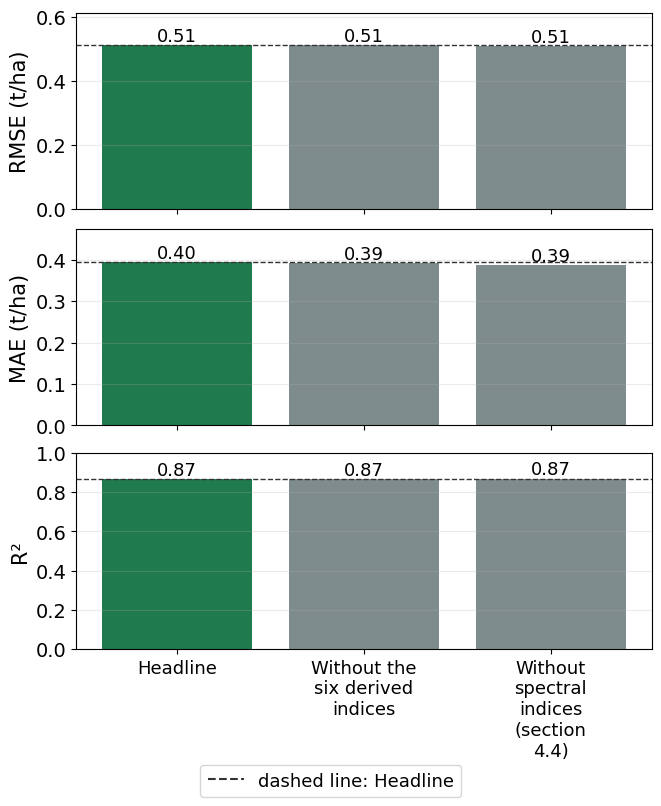

In [64]:
# A.4 results: E20 next to E20b and the headline
appendix_index_variants = {
    "headline configuration (E7)": ("Headline", e07_validation_ensemble, e07_test_ensemble),
    "E20 without derived spectral indices": ("Without the six derived indices", e20_validation_bank.mean(axis=0), e20_test_bank.mean(axis=0)),
    "E20b without any index information": ("Without spectral indices (section 4.4)", e20b_validation_bank.mean(axis=0), e20b_test_bank.mean(axis=0)),
}
appendix_index_rows = []
for variant_name, (_, validation_prediction, test_prediction) in appendix_index_variants.items():
    if variant_name.startswith("headline"):
        verdict = "reference"
    else:
        verdict = noise_verdict(headline_rmse(test_prediction), headline_rmse(e07_test_ensemble))
    appendix_index_rows.append({"variant": variant_name, "validation 2023 RMSE (t/ha)": validation_rmse_t_per_ha(validation_prediction),
                                **test_table_columns(test_prediction), "against the headline": verdict})
record_in_summary("A.4", "E20 without derived spectral indices", e20_test_bank.mean(axis=0), models=N_MODELS_E20)
record_single_models("A.4", "E20 without derived spectral indices", test_bank=e20_test_bank)
appendix_index_table = pd.DataFrame(appendix_index_rows)
appendix_index_table.to_csv(os.path.join(experiment_folder("appendix_derived_indices"), "results.csv"), index=False)
display(appendix_index_table)

appendix_index_colours = {figure_name: MODEL_COLOURS["variant"] for figure_name, _, _ in appendix_index_variants.values()}
appendix_index_colours["Headline"] = MODEL_COLOURS["headline transformer"]
plot_prediction_bars({figure_name: test_prediction for figure_name, _, test_prediction in appendix_index_variants.values()},
                     appendix_index_colours, "appendix_derived_indices", "derived_indices.png", cohorts=("headline",),
                     reference_name="Headline")

### A.5 E25 — The remaining validation improvements combined
The width (E4) and the exact county standard deviation are already part of the headline. The other
changes that lowered the 2023 validation RMSE against their reference in the design phase are
combined on top of it:

| change | from |
|---|---|
| no delta features | E13 |
| the 88 dropped statistics added back | E14 |
| blended with the MLP, *w* chosen on 2023 | E11 |

Tokens per window: the 16 band statistics, the 6 spectral indices and the 88 dropped statistics,
110 values. Everything else as the headline, 30 models, against E7.

**These changes were selected on the 2023 validation season, so the validation RMSE of the combination
is optimistic; 2025 is the only unbiased comparison.** The blend adds a second use of 2023: its
weight is fitted on validation predictions that were already used to pick each model's early-stopping
checkpoint, so the chosen weight is optimistic as well. No 2025 information enters either choice.

In [65]:
# E25: the combined token changes on the headline architecture
N_MODELS_E25 = N_MODELS_PER_ENSEMBLE

combined_tokens_raw = np.concatenate([
    lean_tokens_raw[:, :, BAND_STATISTIC_POSITIONS + SPECTRAL_INDEX_POSITIONS],
    dropped_statistic_tokens_raw,
], axis=2)
combined_tokens = standardize_tokens(combined_tokens_raw, headline_split["is_train_row"])
print(f"E25 tokens: {combined_tokens.shape[2]} values per window, width {D}")

e25_validation_bank, e25_test_bank = load_or_train_bank(
    f"e25_combined_improvements_{HEADLINE_WIDTH_TAG}", N_MODELS_E25,
    lambda seed: train_headline_model(combined_tokens, coverage_headline, headline_split, seed))

E25 tokens: 110 values per window, width 256


,model,validation 2023 RMSE (t/ha),282 counties RMSE (t/ha),282 counties MAE (t/ha),282 counties R2,282 counties nRMSE (%),426 counties RMSE (t/ha),426 counties MAE (t/ha),426 counties R2,426 counties nRMSE (%),against the headline
0,Headline,0.66,0.51,0.4,0.87,11.9,0.56,0.44,0.83,12.4,reference
1,Token changes combined,0.66,0.52,0.4,0.86,12.1,0.56,0.44,0.83,12.5,within noise (+0.005)
2,"Token changes combined + MLP, w from 2023",0.66,0.52,0.4,0.86,12.1,0.56,0.44,0.83,12.5,within noise (+0.005)


blend weight chosen on 2023: w = 1.00
The changes were selected on 2023, so the validation column favours the combination; read 2025.


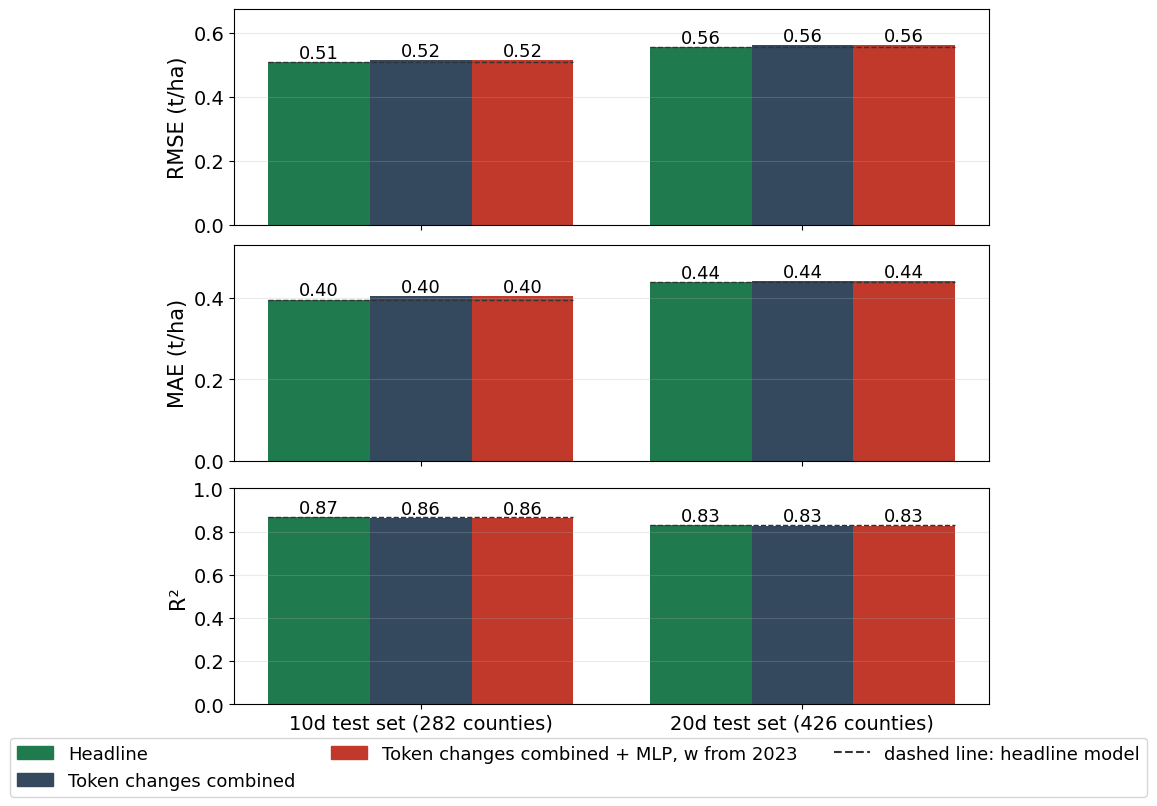

In [66]:
# E25 results against the headline configuration, and the MLP blend
e25_validation_ensemble = e25_validation_bank.mean(axis=0)
e25_test_ensemble = e25_test_bank.mean(axis=0)
e25_blend_validation, e25_blend_test, e25_blend_weight = blend_predictions(e25_validation_ensemble, e25_test_ensemble,
                                                                           e09_validation_ensemble, e09_test_ensemble,
                                                                           yield_actual_validation)

e25_arms = {
    "Headline": (e07_validation_ensemble, e07_test_ensemble, MODEL_COLOURS["headline transformer"]),
    "Token changes combined": (e25_validation_ensemble, e25_test_ensemble, MODEL_COLOURS["large single model"]),
    "Token changes combined + MLP, w from 2023": (e25_blend_validation, e25_blend_test, MODEL_COLOURS["blend"]),
}
e25_rows = []
for arm_name, (validation_prediction, test_prediction, _) in e25_arms.items():
    if arm_name == "Headline":
        verdict = "reference"
    else:
        verdict = noise_verdict(headline_rmse(test_prediction), headline_rmse(e07_test_ensemble))
    e25_rows.append({"model": arm_name, "validation 2023 RMSE (t/ha)": validation_rmse_t_per_ha(validation_prediction),
                     **test_table_columns(test_prediction), "against the headline": verdict})
e25_table = pd.DataFrame(e25_rows)
e25_table.to_csv(os.path.join(experiment_folder(f"e25_combined_improvements_{HEADLINE_WIDTH_TAG}"), "results.csv"), index=False)
display(e25_table)
print(f"blend weight chosen on 2023: w = {e25_blend_weight:.2f}")
print("The changes were selected on 2023, so the validation column favours the combination; read 2025.")

record_in_summary("A.5", "E25 token changes combined", e25_test_ensemble, models=N_MODELS_E25,
                  note="no deltas, plus 88 statistics")
record_single_models("A.5", "E25 token changes combined", test_bank=e25_test_bank)
record_in_summary("A.5", "E25 token changes combined + MLP blend", e25_blend_test,
                  note=f"w = {e25_blend_weight:.2f}, chosen on 2023")

plot_bars_by_test_set({name: values[1] for name, values in e25_arms.items()},
                      {name: values[2] for name, values in e25_arms.items()},
                      f"e25_combined_improvements_{HEADLINE_WIDTH_TAG}", "combined_improvements.png",
                      reference_name="Headline", reference_legend_label="headline model")

### A.6 Transfer to unseen counties and states *(on hold)*
Two transfer questions are on hold for the thesis and are not run here:

- **Unseen counties:** a random 15 percent of the 2025 counties removed from every training and
  validation season, the retrained model scored on exactly those counties.
- **Unseen states:** Idaho, Oregon, Montana and Texas, which appear in no training season, read as
  skill over the history-only baseline.

The earlier runs (`Claude/experiments/unseen_counties.py`, `zero_shot_states.py`,
`zero_shot_calendar.py`) used the averaged cell standard deviation and a different model, so their
numbers are not reported. Before either result is used, it has to be rerun on the current inputs and
the headline configuration.

### Reading, appendix
- **Plain transformer (A.1).** The plain transformer on all 104 statistics reaches 0.52, +0.010 against the
  headline configuration, right at the threshold, so at most slightly worse. The lean tokens, the register block, the coverage and the larger width together
  do not measurably improve the 2025 prediction; the baseline is 0.26 worse.
- **Key/value (A.2).** Separate parameters for keys and values give 0.51, within noise.
- **Cell structure and standard deviation (A.3).** With the between-cell spread 0.51, within noise. The
  averaged cell standard deviation gives 0.52 against 0.51, a difference of +0.010, right at the threshold.
  The exact standard deviation is justified by being the correct statistic, not by a measurable gain.
- **Derived indices only (A.4, E20).** Dropping the six derived indices gives 0.51, within noise.
- **Combined changes (A.5, E25).** 0.52, within noise, and the MLP blend takes the weight 1.00. Changes
  picked on the validation season do not add up on the test season.

## Summary
Every experiment with a prediction of its own: the 2025 holdout on the 10-day complete counties and on
all counties, and, where it exists, leave one year out as the mean over the held-out seasons of the
per-season values on the same two subsets. RMSE and MAE in t/ha. Ensemble size (E3) and the feature
rankings (E17, E18) have no prediction of their own; their results are in
their sections.

In [67]:
# The summary table, also written to cache/e99_summary
summary_table = pd.DataFrame(list(experiment_summary.values()))
summary_table = summary_table.iloc[sorted(range(len(summary_table)),
                                           key=lambda row: section_sort_key(summary_table["section"].iloc[row]))]
summary_columns = ["section", "experiment", "evaluation", "models"]
for subset_name in SUMMARY_SUBSETS:
    summary_columns += [f"{subset_name} RMSE (t/ha)", f"{subset_name} MAE (t/ha)", f"{subset_name} R2"]
summary_columns.append("note")
summary_table = summary_table[summary_columns].reset_index(drop=True)
summary_table.to_csv(os.path.join(experiment_folder("e99_summary"), "summary_all_experiments.csv"), index=False)
with pd.option_context("display.max_rows", 200, "display.max_colwidth", 70):
    display(summary_table.round(2))

,section,experiment,evaluation,models,10-day complete RMSE (t/ha),10-day complete MAE (t/ha),10-day complete R2,all counties RMSE (t/ha),all counties MAE (t/ha),all counties R2,note
0,1.1,headline register transformer (01),2025 holdout,30,0.51,0.39,0.87,0.56,0.44,0.83,"the reported headline, unseeded"
1,1.1,history only (5-year average),2025 holdout,0,0.77,0.62,0.70,0.76,0.61,0.68,
2,1.1,headline transformer (E1),"leave one year out, mean over 9 seasons",30 per fold,0.56,0.44,0.77,0.58,0.45,0.74,
3,2.1,"arm 10d windows, 10d dataset",2025 holdout,30,0.54,0.42,0.85,NaN,NaN,NaN,
4,2.1,"arm 20d windows, 10d dataset",2025 holdout,30,0.52,0.40,0.86,0.56,0.44,0.83,
5,2.3,"E4 Variant 1: width 128, 1 layer",2025 holdout,30,0.51,0.39,0.87,0.56,0.44,0.83,
6,2.3,"E4 Variant 2: width 512, 1 layer",2025 holdout,30,0.51,0.40,0.86,0.56,0.44,0.83,
7,2.3,"E4 Variant 3: width 256, 2 layers",2025 holdout,30,0.52,0.40,0.86,0.56,0.44,0.83,
8,2.3,"E4 Variant 4: width 256, 3 layers",2025 holdout,30,0.52,0.40,0.86,0.56,0.44,0.83,
9,2.3,"E21 61x parameters, single model 2",2025 holdout,1,0.52,0.41,0.86,0.60,0.46,0.81,chosen by the author from five


### Single models: the variance from training randomness
Every model of an ensemble scored **on its own**, one point per model, for every experiment trained as
an ensemble of 30 (E21: its 5 single models). The models of one experiment differ only in their random
seed (initial weights, dropout, token noise and batch order), so the spread of the points is the
variance that comes from the randomness of training. The box spans the middle half of the models, the
line inside it is the median, the whiskers reach the most extreme model within 1.5 box lengths, and
the red diamond is the ensemble of the same models.

Three panels: the 2025 holdout on the 10-day complete counties and on all counties, and leave one year
out as each model's mean over the held-out seasons of its RMSE on the 10-day complete counties (model
*i* of every fold, which share their seed). Leave one year out exists for the headline configuration
(E1) and the MLP (E23) only; for these two rows the 2025 panels show E7 and E9. Random forests and
blends are not ensembles of independently trained models and do not appear. Unlike the bar charts, the
value axes do not start at zero, since the spread would otherwise be invisible.

The headline configuration has a second row, since E7 has 60 models: every point there is a **30-model
ensemble**, one of the 200 random subsets of the 60 drawn in section 2.2, and its diamond is the ensemble of
all 60. It shows how much of the single-model spread is left once 30 models are averaged, on the 10-day
complete counties and on all counties (leave one year out has only 30 models per fold).

One figure holds every experiment; one figure per section (1 and 2, 3, 4, appendix) repeats the rows of
that section below the two headline configuration rows, each on its own scale.

RMSE in t/ha; the standard deviation keeps three decimals because it lies below 0.01 for the ensembles


,section,experiment,one point is,2025 10-day complete n,2025 10-day complete min,2025 10-day complete median,2025 10-day complete max,2025 10-day complete std,2025 10-day complete ensemble of the same models,2025 all counties n,2025 all counties min,2025 all counties median,2025 all counties max,2025 all counties std,2025 all counties ensemble of the same models,LOYO 10-day complete n,LOYO 10-day complete min,LOYO 10-day complete median,LOYO 10-day complete max,LOYO 10-day complete std,LOYO 10-day complete ensemble of the same models
0,1.1,headline register transformer (01),single models,30,0.52,0.55,0.60,0.020,0.51,30.0,0.57,0.59,0.66,0.021,0.56,NaN,NaN,NaN,NaN,NaN,NaN
1,1.1,"headline configuration (2025: E7, LOYO: E1)",single models,30,0.51,0.55,0.57,0.016,0.51,30.0,0.57,0.59,0.62,0.014,0.56,30.0,0.57,0.60,0.61,0.009,0.56
2,1.1,"headline configuration, 30-model ensembles (su...",30-model ensembles,200,0.51,0.51,0.52,0.002,0.51,200.0,0.55,0.56,0.56,0.001,0.56,NaN,NaN,NaN,NaN,NaN,NaN
3,2.1,"arm 10d windows, 10d dataset",single models,30,0.55,0.57,0.61,0.018,0.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.1,"arm 20d windows, 10d dataset",single models,30,0.53,0.56,0.62,0.022,0.52,30.0,0.57,0.60,0.66,0.021,0.56,NaN,NaN,NaN,NaN,NaN,NaN
5,2.3,"E4 Variant 1: width 128, 1 layer",single models,30,0.52,0.55,0.60,0.022,0.51,30.0,0.57,0.59,0.64,0.019,0.56,NaN,NaN,NaN,NaN,NaN,NaN
6,2.3,"E4 Variant 2: width 512, 1 layer",single models,30,0.52,0.55,0.60,0.019,0.51,30.0,0.56,0.59,0.62,0.016,0.56,NaN,NaN,NaN,NaN,NaN,NaN
7,2.3,"E4 Variant 3: width 256, 2 layers",single models,30,0.53,0.55,0.59,0.017,0.52,30.0,0.58,0.59,0.64,0.014,0.56,NaN,NaN,NaN,NaN,NaN,NaN
8,2.3,"E4 Variant 4: width 256, 3 layers",single models,30,0.52,0.55,0.59,0.017,0.52,30.0,0.56,0.59,0.63,0.016,0.56,NaN,NaN,NaN,NaN,NaN,NaN
9,2.3,"E21 single model, 61x parameters (5 models)",single models,5,0.51,0.54,0.56,0.017,0.51,5.0,0.57,0.57,0.62,0.020,0.56,NaN,NaN,NaN,NaN,NaN,NaN


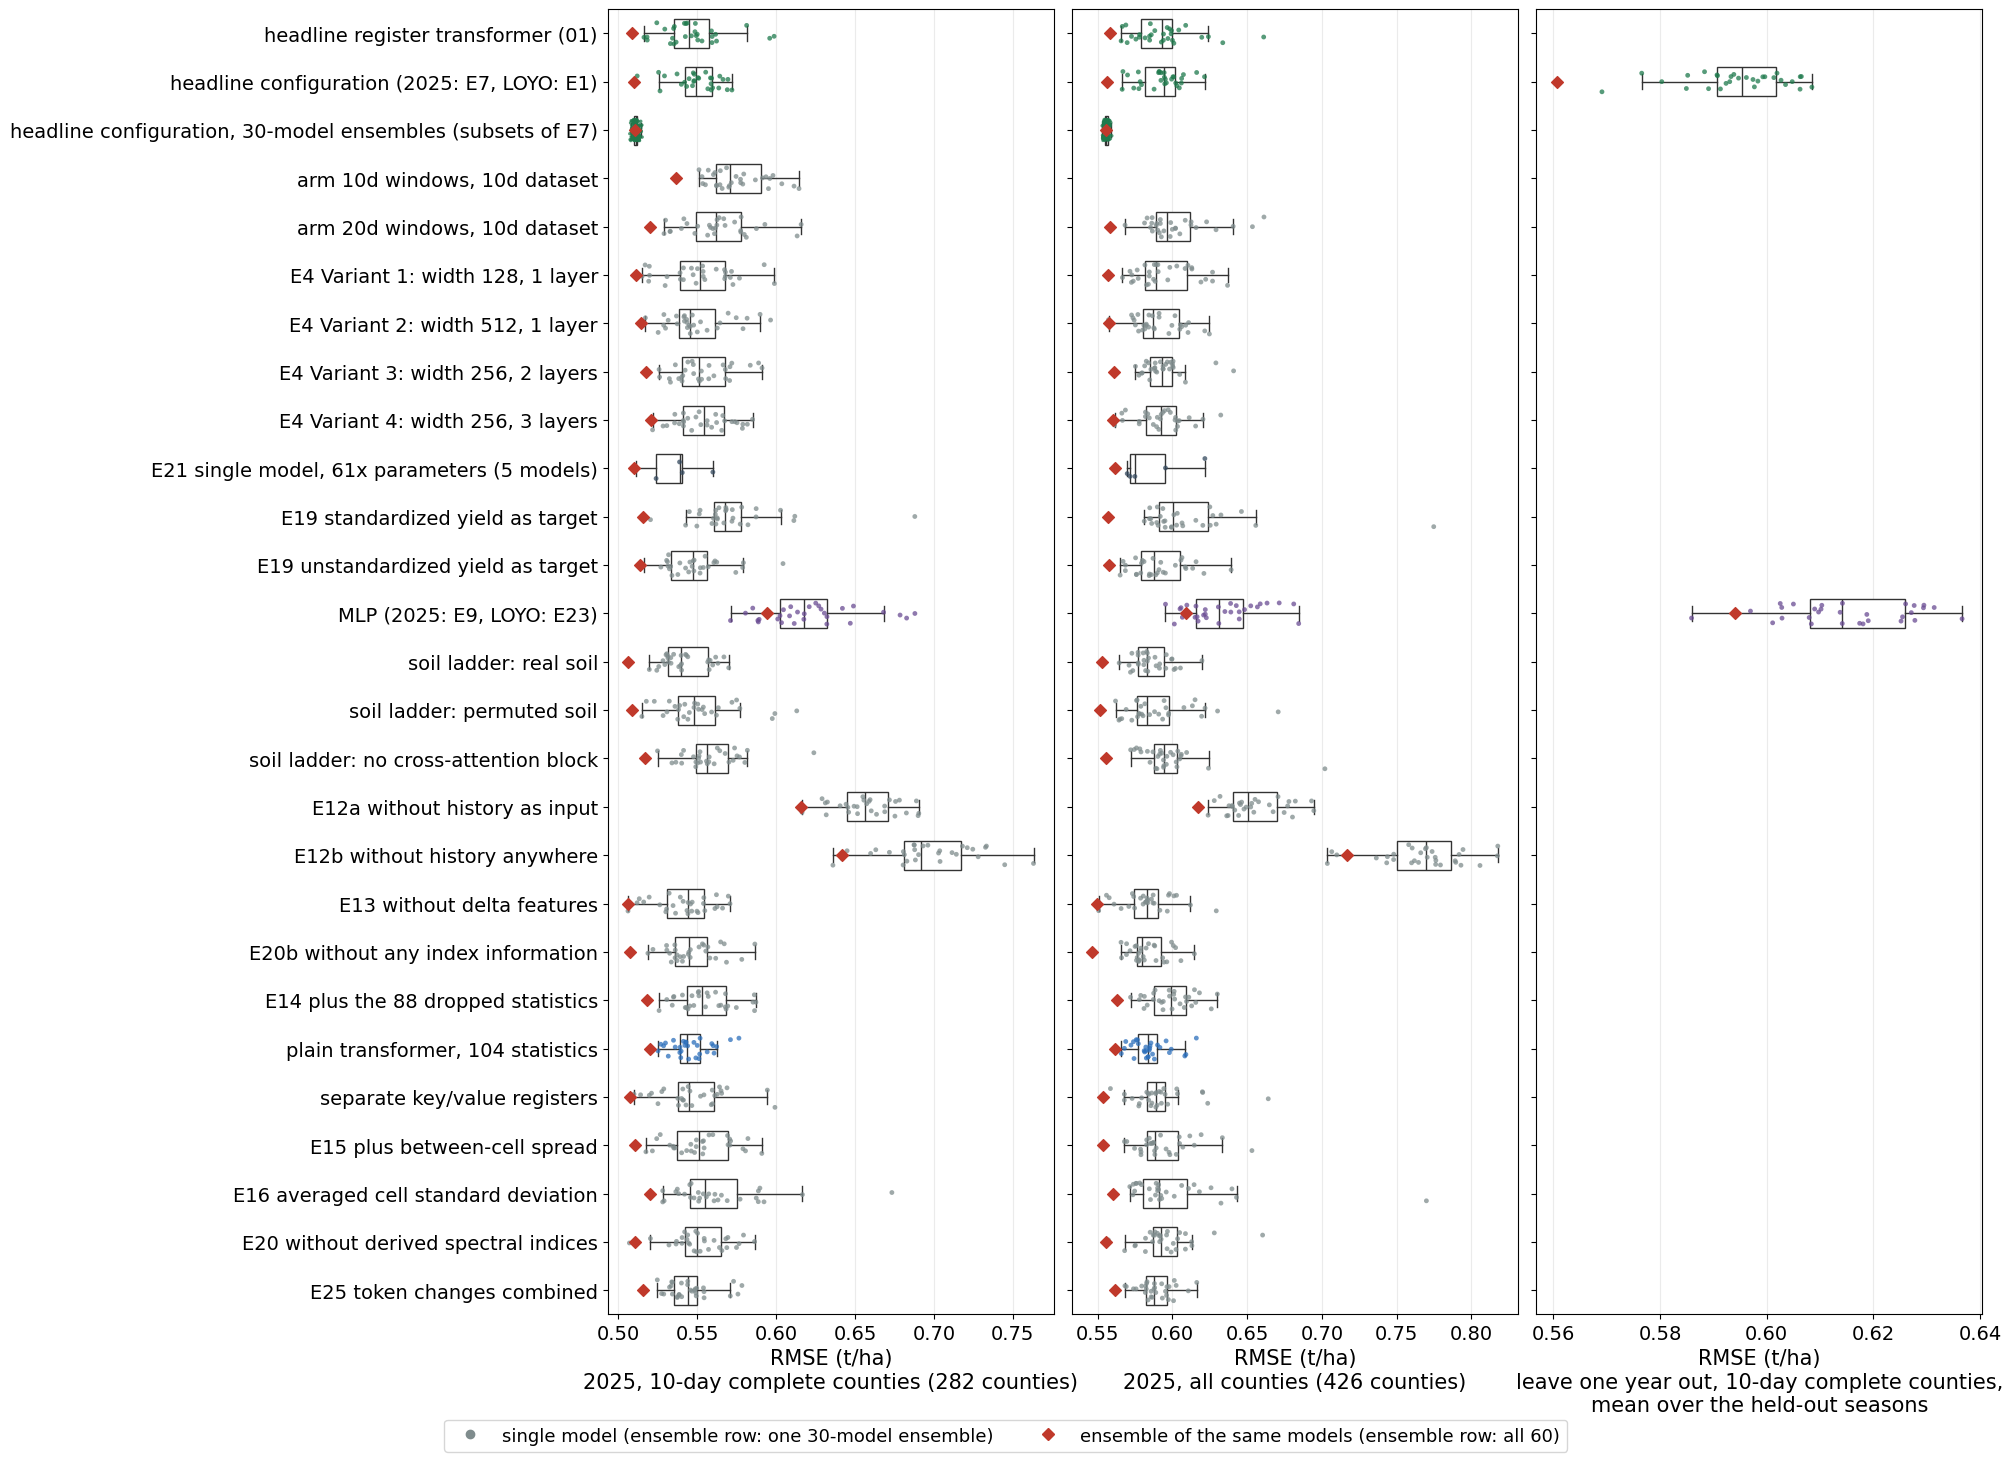

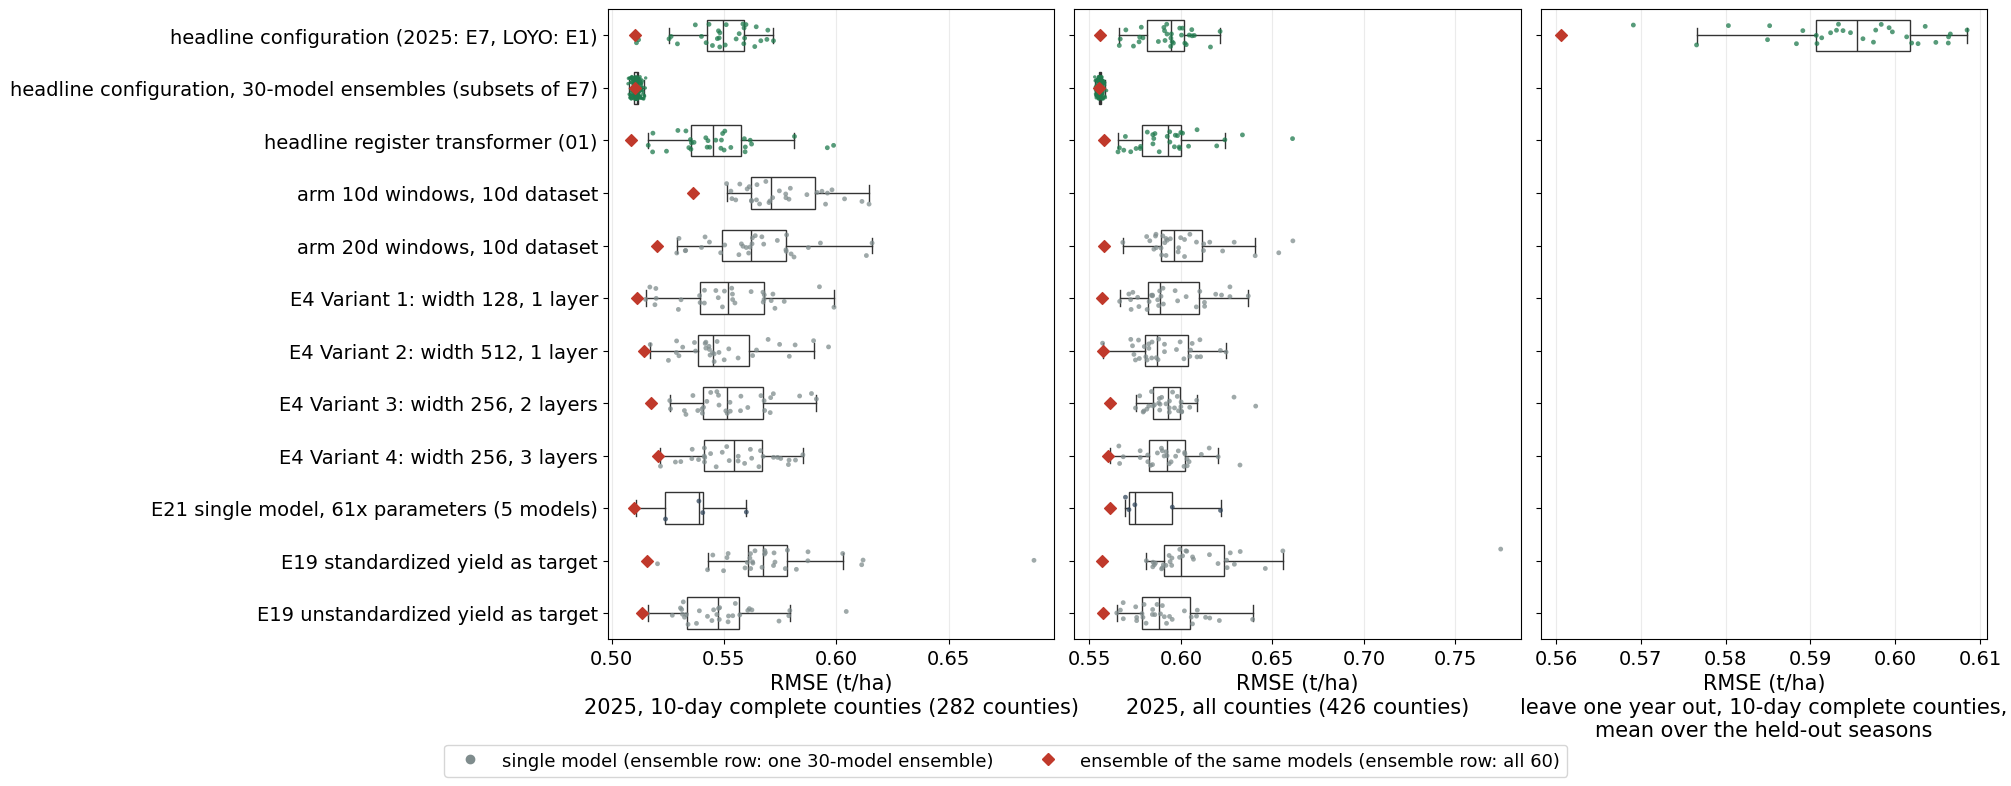

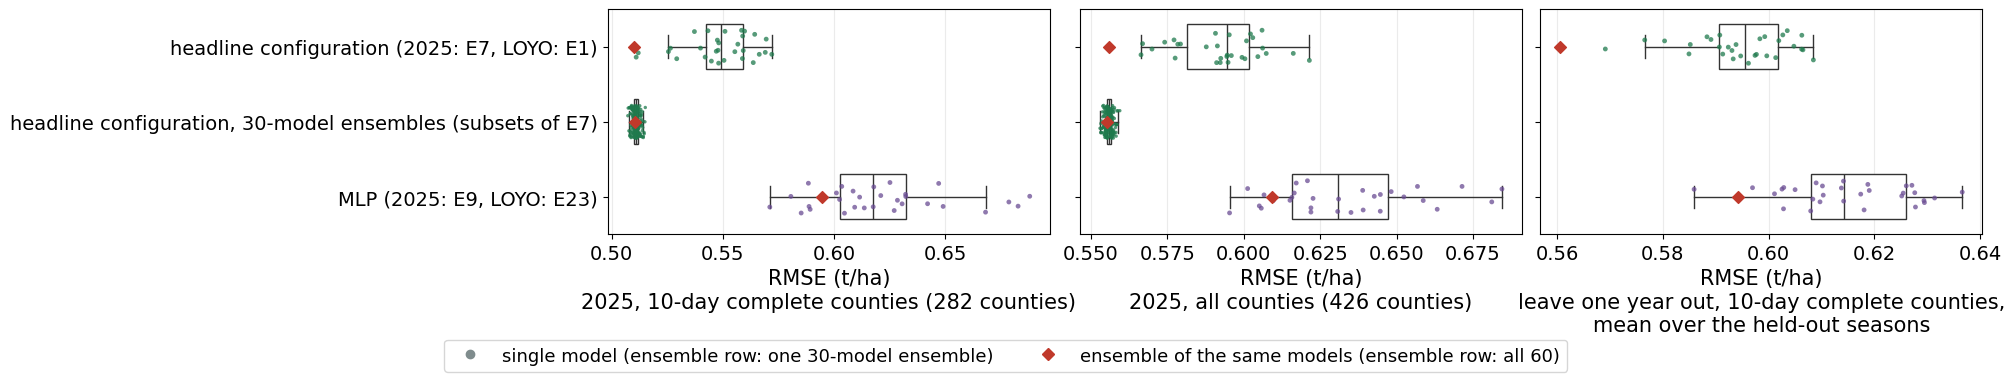

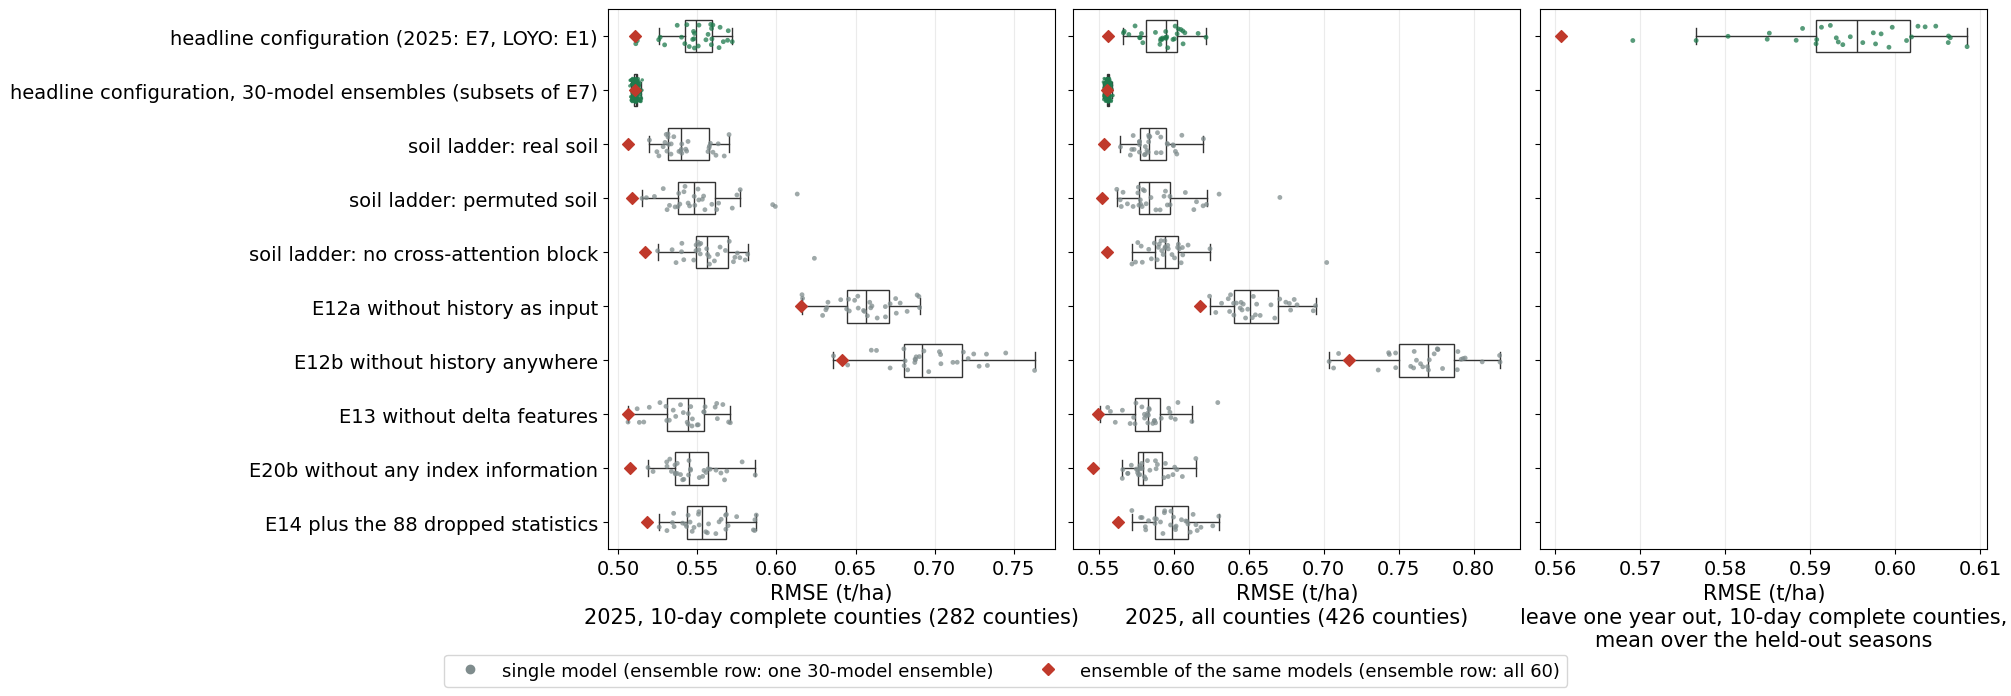

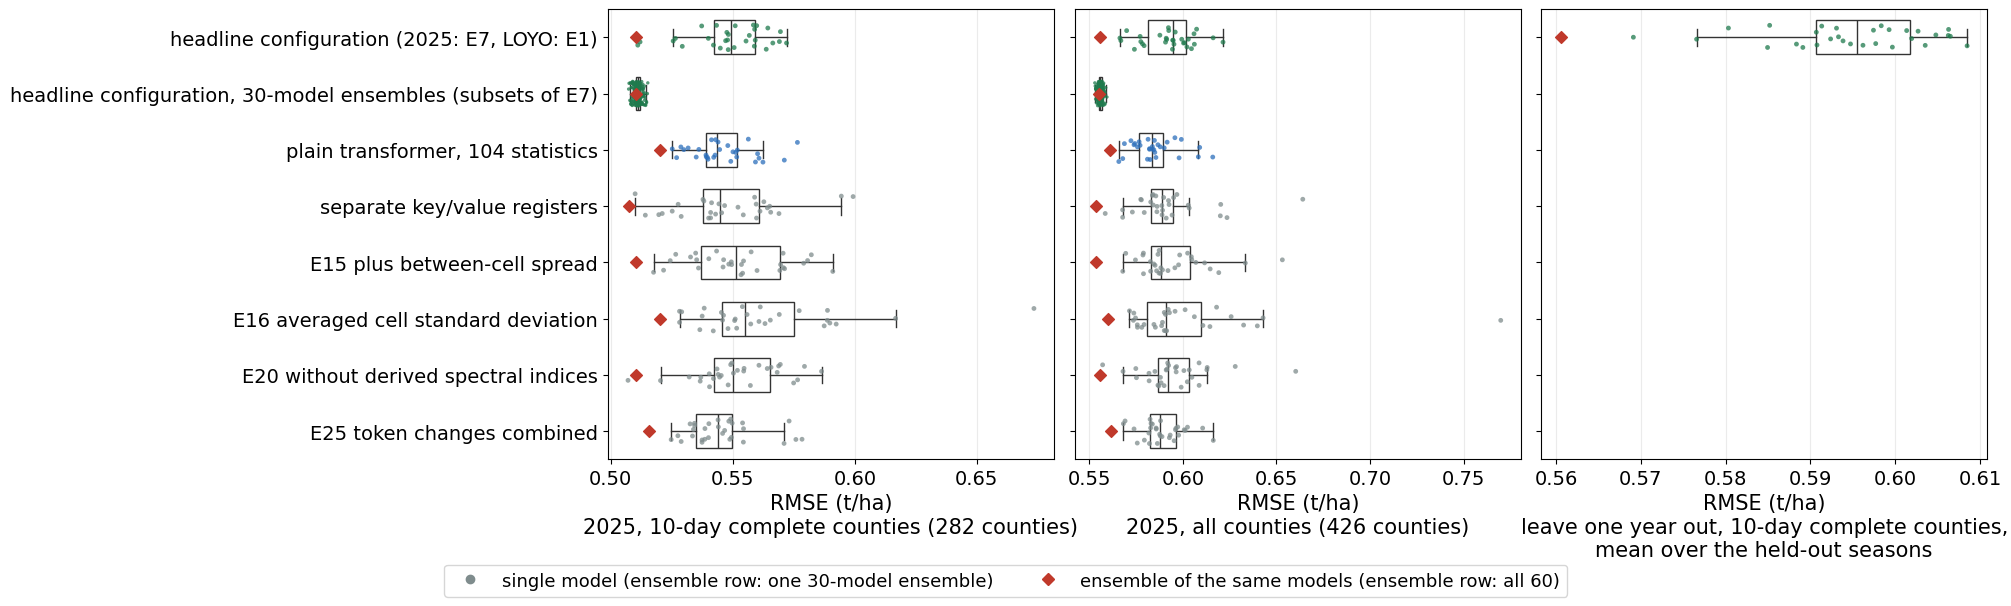

In [68]:
# Box plots of the single models of every ensemble (and of 30-model ensembles of the headline configuration)
def single_model_rmses_2025(test_bank, row_mask):
    """RMSE (t/ha) of every model of a 2025 bank on the rows in row_mask, and of their ensemble;
    (None, None) when the bank has no prediction for these rows."""
    if np.isnan(test_bank[:, row_mask]).any():
        return None, None
    actual = yield_actual_test[row_mask]
    single_rmses = [rmse(prediction[row_mask], actual) / DT_HA_PER_T_HA for prediction in test_bank]
    return single_rmses, rmse(test_bank.mean(axis=0)[row_mask], actual) / DT_HA_PER_T_HA


def single_model_rmses_loyo(test_bank_by_year):
    """Mean over the held-out seasons of each model's 10-day complete RMSE (t/ha), and of the ensemble."""
    n_models = min(len(bank) for bank in test_bank_by_year.values())
    single_rmses = [loyo_mean_rmse({held_out_year: bank[model] for held_out_year, bank in test_bank_by_year.items()}) / DT_HA_PER_T_HA
                    for model in range(n_models)]
    ensemble_rmse = loyo_mean_rmse({held_out_year: bank.mean(axis=0) for held_out_year, bank in test_bank_by_year.items()}) / DT_HA_PER_T_HA
    return single_rmses, ensemble_rmse


BOX_PANELS = [("2025 10-day complete", f"RMSE (t/ha)\n2025, 10-day complete counties ({HEADLINE_LABEL})"),
              ("2025 all counties", f"RMSE (t/ha)\n2025, all counties ({FULL_LABEL})"),
              ("LOYO 10-day complete", "RMSE (t/ha)\nleave one year out, 10-day complete counties,\nmean over the held-out seasons")]
HEADLINE_SEEDED_ROW = "headline configuration (2025: E7, LOYO: E1)"
HEADLINE_ENSEMBLE_ROW = f"headline configuration, {N_MODELS_PER_ENSEMBLE}-model ensembles (subsets of E7)"

# one box row per experiment: its section, colour, what one point is, and {panel: (point RMSEs, ensemble RMSE)}
box_rows = {}
for experiment, entry in sorted(single_model_registry.items(), key=lambda item: section_sort_key(item[1]["section"])):
    values_by_panel = {panel: (None, None) for panel, _ in BOX_PANELS}
    if entry["test"] is not None:
        values_by_panel["2025 10-day complete"] = single_model_rmses_2025(entry["test"], is_headline_cohort)
        values_by_panel["2025 all counties"] = single_model_rmses_2025(entry["test"], np.ones(len(yield_actual_test), bool))
    if entry["loyo"] is not None:
        values_by_panel["LOYO 10-day complete"] = single_model_rmses_loyo(entry["loyo"])
    box_rows[experiment] = dict(section=entry["section"], colour=entry["colour"], points="single models", values=values_by_panel)
    if experiment == HEADLINE_SEEDED_ROW:
        # the random 30-model subsets of the 60 E7 models drawn in section 2.2, next to the single models;
        # their "ensemble of the same models" is the ensemble of all 60
        headline_subset_metrics = subset_metrics_by_size[N_MODELS_PER_ENSEMBLE]
        box_rows[HEADLINE_ENSEMBLE_ROW] = dict(
            section=entry["section"], colour=entry["colour"], points=f"{N_MODELS_PER_ENSEMBLE}-model ensembles",
            values={"2025 10-day complete": ([metrics["headline"]["RMSE"] for metrics in headline_subset_metrics],
                                             full_ensemble_metrics["headline"]["RMSE"]),
                    "2025 all counties": ([metrics["full"]["RMSE"] for metrics in headline_subset_metrics],
                                          full_ensemble_metrics["full"]["RMSE"]),
                    "LOYO 10-day complete": (None, None)})

variance_table_rows = []
for experiment, row in box_rows.items():
    table_row = {"section": row["section"], "experiment": experiment, "one point is": row["points"]}
    for panel, _ in BOX_PANELS:
        point_rmses, ensemble_rmse = row["values"][panel]
        if point_rmses is None:
            continue
        table_row[f"{panel} n"] = len(point_rmses)
        table_row[f"{panel} min"] = round(float(np.min(point_rmses)), 2)
        table_row[f"{panel} median"] = round(float(np.median(point_rmses)), 2)
        table_row[f"{panel} max"] = round(float(np.max(point_rmses)), 2)
        table_row[f"{panel} std"] = round(float(np.std(point_rmses)), 3)
        table_row[f"{panel} ensemble of the same models"] = round(float(ensemble_rmse), 2)
    variance_table_rows.append(table_row)
single_model_variance_table = pd.DataFrame(variance_table_rows)
single_model_variance_table.to_csv(os.path.join(experiment_folder("e99_summary"), "single_model_variance.csv"), index=False)
print("RMSE in t/ha; the standard deviation keeps three decimals because it lies below 0.01 for the ensembles")
with pd.option_context("display.max_rows", 200, "display.max_columns", 40):
    display(single_model_variance_table)


def plot_single_model_boxes(experiment_names, file_name):
    """One row per experiment, one panel per test set that at least one of the rows has; one point per
    model (or per ensemble in the ensemble row), the box over the points, the ensemble of the same models
    as a red diamond."""
    panels = [(panel, label) for panel, label in BOX_PANELS
              if any(box_rows[name]["values"][panel][0] is not None for name in experiment_names)]
    row_positions = np.arange(len(experiment_names))
    jitter_generator = np.random.default_rng(0)
    figure, axes = plt.subplots(1, len(panels), figsize=(5.5 * len(panels) + 3.5, 0.45 * len(experiment_names) + 2.4),
                                sharey=True, layout="constrained", squeeze=False)
    for axis, (panel, axis_label) in zip(axes[0], panels):
        for position, name in zip(row_positions, experiment_names):
            point_rmses, ensemble_rmse = box_rows[name]["values"][panel]
            if point_rmses is None:
                continue
            axis.boxplot(point_rmses, positions=[position], orientation="horizontal", widths=0.6, showfliers=False,
                         patch_artist=True, boxprops={"facecolor": "white", "edgecolor": "#333333"},
                         medianprops={"color": "#333333"}, whiskerprops={"color": "#333333"}, capprops={"color": "#333333"})
            axis.scatter(point_rmses, position + jitter_generator.uniform(-0.22, 0.22, len(point_rmses)),
                         s=12 if len(point_rmses) <= 60 else 6, color=box_rows[name]["colour"], alpha=0.75,
                         edgecolor="none", zorder=3)
            axis.scatter([ensemble_rmse], [position], marker="D", s=36, color="#c0392b", zorder=4)
        axis.set_xlabel(axis_label)
        axis.grid(axis="x", alpha=0.25)
    axes[0][0].set_yticks(row_positions)
    axes[0][0].set_yticklabels(experiment_names)
    axes[0][0].invert_yaxis()
    legend_handles = [plt.Line2D([], [], marker="o", linestyle="none", color="#7f8c8d",
                                 label=f"single model (ensemble row: one {N_MODELS_PER_ENSEMBLE}-model ensemble)"),
                      plt.Line2D([], [], marker="D", linestyle="none", color="#c0392b",
                                 label=f"ensemble of the same models (ensemble row: all {len(e07_test_bank)})")]
    figure.legend(handles=legend_handles, ncol=2, loc="outside lower center")
    save_figure(figure, "e99_summary", file_name)


# every experiment in one figure, then one figure per section below the two headline configuration rows
HEADLINE_ROWS = [HEADLINE_SEEDED_ROW, HEADLINE_ENSEMBLE_ROW]
plot_single_model_boxes(list(box_rows), "single_model_variance_all.png")
for sections, file_name in [(("1", "2"), "single_model_variance_sections_1_2.png"),
                            (("3",), "single_model_variance_section_3.png"),
                            (("4",), "single_model_variance_section_4.png"),
                            (("A",), "single_model_variance_appendix.png")]:
    section_experiments = [experiment for experiment, row in box_rows.items()
                           if row["section"].split(".")[0] in sections and experiment not in HEADLINE_ROWS]
    plot_single_model_boxes(HEADLINE_ROWS + section_experiments, file_name)

In [69]:
# The index of the figures folder
figure_index_table = pd.DataFrame(figure_index).drop_duplicates("figure").sort_values("figure")
figure_index_table.to_csv(os.path.join(FIGURES, "index.csv"), index=False)
print(f"{len(figure_index_table)} figures in {FIGURES}")
with pd.option_context("display.max_rows", 100):
    display(figure_index_table)

45 figures in <repository>\Claude\final_results_claude\figures


,figure,notebook section,experiment folder
0,1-1_headline_against_baseline,1-1,headline_after_season
1,1-1_loyo_after_season,1-1,e01_loyo_after_season_width256
4,1-1_map_absolute_error_2025,1-1,maps_after_season
5,1-1_map_absolute_error_loyo,1-1,maps_after_season
2,1-1_map_bias_2025,1-1,maps_after_season
3,1-1_map_bias_loyo,1-1,maps_after_season
6,1-1_map_r2_state_2025,1-1,maps_after_season
7,1-1_map_r2_state_loyo,1-1,maps_after_season
8,1-1_parity_2025_10d_test_set,1-1,parity_after_season
9,1-1_parity_2025_20d_test_set,1-1,parity_after_season
